## **Section-0 **


In [1]:
# =========================
# SECTION 0 / CELL 1
# Drive mount + imports + stable project root + reusable helpers
# =========================

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
import json
import math
import time
import random
import hashlib
import textwrap
import warnings
from pathlib import Path
from datetime import datetime, timezone
from pprint import pprint

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# -------------------------
# Stable project root in Google Drive
# -------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Test_results").resolve()

# Stable folder structure for the whole project
DIRS = {
    "project_root": PROJECT_ROOT,
    "configs": PROJECT_ROOT / "configs",
    "artifacts": PROJECT_ROOT / "artifacts",
    "datasets": PROJECT_ROOT / "datasets",
    "scripts": PROJECT_ROOT / "scripts",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
    "logs": PROJECT_ROOT / "logs",
    "cache": PROJECT_ROOT / "cache",
    "reports": PROJECT_ROOT / "reports",
    "exports": PROJECT_ROOT / "exports",
    "state": PROJECT_ROOT / "state"
}

def ensure_dir(path: Path):
    """Create directory only if missing."""
    path.mkdir(parents=True, exist_ok=True)
    return path

# Create only missing directories; reuse existing ones otherwise
for _, folder_path in DIRS.items():
    ensure_dir(folder_path)

# -------------------------
# Core helper utilities
# -------------------------
def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()

def short_hash(obj, length=12):
    raw = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()[:length]

def file_exists(path):
    return Path(path).exists()

def save_json_if_missing(path, data, indent=2):
    """
    Save JSON only if file does not exist.
    If it exists, do not overwrite.
    """
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=indent)
        created = True
    else:
        created = False
    return created

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return default

def load_or_create_json(path, default_data, indent=2):
    """
    Load JSON if present; otherwise create it using default_data and return it.
    """
    path = Path(path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        status = "loaded_existing"
    else:
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(default_data, f, indent=indent)
        data = default_data
        status = "created_new"
    return data, status

def save_text_if_missing(path, text_data):
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(text_data, encoding="utf-8")
        created = True
    else:
        created = False
    return created

def print_box(title, obj=None):
    print("=" * 90)
    print(title)
    print("=" * 90)
    if obj is not None:
        if isinstance(obj, (dict, list)):
            pprint(obj)
        else:
            print(obj)

# -------------------------
# Stable file paths used by Section 0
# -------------------------
SECTION0_FILES = {
    "project_manifest": DIRS["state"] / "project_manifest.json",
    "threat_model": DIRS["configs"] / "threat_model.json",
    "research_hypotheses": DIRS["configs"] / "research_hypotheses.json",
    "master_config": DIRS["configs"] / "master_config_v2.json"
}

# -------------------------
# Project manifest: create once, then reuse
# -------------------------
default_manifest = {
    "project_name": "PQC_QKD_Lindblad_Evaluation_Framework",
    "project_root": str(PROJECT_ROOT),
    "created_utc": utc_now_iso(),
    "framework_version": "v2_section0_initialized",
    "notes": "Stable Google Drive project root for idempotent notebook reruns.",
    "directories": {k: str(v) for k, v in DIRS.items()}
}

manifest, manifest_status = load_or_create_json(
    SECTION0_FILES["project_manifest"],
    default_manifest
)

print_box("Project Root", str(PROJECT_ROOT))
print_box("Directory Reuse Status", {k: str(v) for k, v in DIRS.items()})
print_box("Manifest Status", manifest_status)
print_box("Manifest Path", str(SECTION0_FILES["project_manifest"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project Root
/content/drive/MyDrive/Test_results
Directory Reuse Status
{'artifacts': '/content/drive/MyDrive/Test_results/artifacts',
 'cache': '/content/drive/MyDrive/Test_results/cache',
 'configs': '/content/drive/MyDrive/Test_results/configs',
 'datasets': '/content/drive/MyDrive/Test_results/datasets',
 'exports': '/content/drive/MyDrive/Test_results/exports',
 'figures': '/content/drive/MyDrive/Test_results/figures',
 'logs': '/content/drive/MyDrive/Test_results/logs',
 'project_root': '/content/drive/MyDrive/Test_results',
 'reports': '/content/drive/MyDrive/Test_results/reports',
 'scripts': '/content/drive/MyDrive/Test_results/scripts',
 'state': '/content/drive/MyDrive/Test_results/state',
 'tables': '/content/drive/MyDrive/Test_results/tables'}
Manifest Status
loaded_existing
Manifest Path
/content/drive/MyDrive/Test_results/state/project_manifest

In [2]:
# =========================
# SECTION 0 / CELL 2
# Threat model and assumptions
# =========================

DEFAULT_THREAT_MODEL = {
    "document_name": "threat_model",
    "version": "1.0",
    "last_defined_utc": utc_now_iso(),
    "system_scope": {
        "target_system": "Four end-to-end secure communication pipelines using PQC, BB84-emulated QKD, and Lindblad-inspired stochastic key hardening",
        "deployment_style": "Software prototype / research framework",
        "qkd_status": "BB84 is emulated in software, not physical optical QKD deployment",
        "lindblad_status": "Lindblad-inspired stochastic key hardening, not literal physical open-quantum hardware evolution"
    },
    "assets_to_protect": [
        "session keys",
        "intermediate key material",
        "confidentiality of application plaintext",
        "integrity of ciphertext and associated data",
        "authenticity of transcript / session messages",
        "availability of secure session establishment"
    ],
    "attacker_capabilities": {
        "network_eavesdropping": True,
        "packet_injection": True,
        "packet_modification": True,
        "packet_replay": True,
        "chosen_ciphertext_attempts": True,
        "partial_key_leakage_scenarios": True,
        "side_channel_inference_modeled_indirectly": True,
        "full_endpoint_compromise": False,
        "cryptographic_primitive_break_assumed": False
    },
    "attacker_observations": [
        "ciphertexts",
        "AAD / metadata sent in protocol",
        "timing outputs available from experiments",
        "selected transcript messages where applicable",
        "leakage variables synthesized in controlled experiments"
    ],
    "in_scope_attacks": [
        "ciphertext tampering",
        "AAD tampering",
        "replay attacks",
        "transcript forgery attempts",
        "chosen-ciphertext manipulation",
        "partial leakage analysis",
        "noise-driven QKD abort behavior",
        "mutual-information based leakage estimation"
    ],
    "out_of_scope": [
        "full host compromise",
        "real physical quantum channel attacks on deployed hardware",
        "microarchitectural side-channel measurement on real devices",
        "nation-state cryptanalysis against standardized primitives",
        "traffic analysis across large production networks"
    ],
    "security_goals": [
        "confidentiality",
        "integrity",
        "authentication",
        "replay resistance",
        "robustness under adverse conditions",
        "improved unpredictability of hardened keys"
    ],
    "evaluation_objective": {
        "primary_goal": "Compare security-performance tradeoffs across four pipelines plus baselines",
        "secondary_goal": "Train an AI selector to recommend an appropriate pipeline under varying conditions and policy requirements"
    }
}

threat_model_data, threat_model_status = load_or_create_json(
    SECTION0_FILES["threat_model"],
    DEFAULT_THREAT_MODEL
)

print_box("Threat Model File Status", threat_model_status)
print_box("Threat Model Path", str(SECTION0_FILES["threat_model"]))
print_box("Threat Model Summary", threat_model_data)

print("\nEdit the JSON file later only if you want to refine assumptions. Reruns will reuse the existing file by default.")

Threat Model File Status
loaded_existing
Threat Model Path
/content/drive/MyDrive/Test_results/configs/threat_model.json
Threat Model Summary
{'assets_to_protect': ['session keys',
                       'intermediate key material',
                       'confidentiality of application plaintext',
                       'integrity of ciphertext and associated data',
                       'authenticity of transcript / session messages',
                       'availability of secure session establishment'],
 'attacker_capabilities': {'chosen_ciphertext_attempts': True,
                           'cryptographic_primitive_break_assumed': False,
                           'full_endpoint_compromise': False,
                           'network_eavesdropping': True,
                           'packet_injection': True,
                           'packet_modification': True,
                           'packet_replay': True,
                           'partial_key_leakage_scenarios': True,
   

In [3]:
# =========================
# SECTION 0 / CELL 3
# Research hypotheses and evaluation questions
# =========================

DEFAULT_HYPOTHESES = {
    "document_name": "research_hypotheses",
    "version": "1.0",
    "last_defined_utc": utc_now_iso(),
    "main_research_question": (
        "How do four end-to-end PQC / hybrid-QKD pipelines differ in security and performance, "
        "and can an AI model learn to choose the best pipeline under varying conditions?"
    ),
    "hypotheses": [
        {
            "id": "H1",
            "statement": (
                "The Lindblad-inspired stochastic key hardening layer increases key unpredictability "
                "and improves at least some quantitative security metrics, at the cost of additional overhead."
            )
        },
        {
            "id": "H2",
            "statement": (
                "Hybrid pipelines using BB84-emulated QKD provide stronger security behavior than PQC-only "
                "pipelines under the defined evaluation metrics, but incur higher latency and lower throughput."
            )
        },
        {
            "id": "H3",
            "statement": (
                "No single pipeline is optimal under all system conditions; the best choice depends on the "
                "security-latency tradeoff and operating environment."
            )
        },
        {
            "id": "H4",
            "statement": (
                "A supervised learning model trained on condition-aware experimental data can recommend the "
                "most suitable pipeline with useful predictive accuracy."
            )
        }
    ],
    "evaluation_questions": [
        "How much latency overhead is introduced by QKD and by Lindblad hardening?",
        "Do entropy, min-entropy, randomness, avalanche, and leakage metrics improve with hardening?",
        "How do attack success probabilities differ across the pipelines?",
        "How sensitive are the pipelines to noise, raw-key length, packet loss, and CPU stress?",
        "Which pipeline lies on the security-latency Pareto frontier under different conditions?",
        "Can a Random Forest or XGBoost-style model correctly predict the oracle-best pipeline?"
    ],
    "expected_outputs": [
        "clean benchmark dataset",
        "quantitative security dataset",
        "aggregated security score per pipeline",
        "sweep plots and Pareto plots",
        "AI selector model and evaluation report"
    ]
}

hypothesis_data, hypothesis_status = load_or_create_json(
    SECTION0_FILES["research_hypotheses"],
    DEFAULT_HYPOTHESES
)

print_box("Hypotheses File Status", hypothesis_status)
print_box("Hypotheses Path", str(SECTION0_FILES["research_hypotheses"]))
print_box("Research Hypotheses", hypothesis_data)

Hypotheses File Status
loaded_existing
Hypotheses Path
/content/drive/MyDrive/Test_results/configs/research_hypotheses.json
Research Hypotheses
{'document_name': 'research_hypotheses',
 'evaluation_questions': ['How much latency overhead is introduced by QKD and '
                          'by Lindblad hardening?',
                          'Do entropy, min-entropy, randomness, avalanche, and '
                          'leakage metrics improve with hardening?',
                          'How do attack success probabilities differ across '
                          'the pipelines?',
                          'How sensitive are the pipelines to noise, raw-key '
                          'length, packet loss, and CPU stress?',
                          'Which pipeline lies on the security-latency Pareto '
                          'frontier under different conditions?',
                          'Can a Random Forest or XGBoost-style model '
                          'correctly predict th

In [4]:
# =========================
# SECTION 0 / CELL 4
# PATCHED Master CONFIG for dual-layer adaptive framework
# =========================

DEFAULT_MASTER_CONFIG_V2 = {
    "project_name": "pqc_hybrid_secure_pipeline",
    "version": "2.0",
    "created_utc": utc_now_iso(),
    "execution_policy": {
        "numpy_seed": 42,
        "python_seed": 42,
        "random_seed_base": 424242
    },
    "benchmark_policy": {
        "measured_trials_per_config": 3
    },
    "qkd_defaults": {
        "N_RAW": 4096,
        "P_NOISE": 0.02,
        "QBER_MAX": 0.08,
        "SAMPLE_FRAC": 0.10,
        "RECON_MAX_ROUNDS": 12
    },
    "lindblad_defaults": {
        "enabled_mode": "stochastic",
        "steps": 4,
        "tau": 0.01,
        "gamma": 0.15
    },
    "replay_defaults": {
        "max_entries": 50000
    },
    "sweep_grid": {
        "message_length_bytes": [128, 1024, 4096],
        "network_delay_ms": [0, 10, 30, 60],
        "packet_loss_pct": [0.0, 0.5, 1.0, 2.0],
        "cpu_stress_level": [0, 1, 2],
        "P_NOISE": [0.0, 0.01, 0.02, 0.04],
        "N_RAW": [1024, 2048, 4096, 8192],
        "QBER_MAX": [0.04, 0.06, 0.08, 0.10],
        "lindblad_steps": [0, 2, 4, 8],
        "lindblad_tau": [0.005, 0.01, 0.02]
    }
}

MASTER_CONFIG_PATH = SECTION0_FILES["master_config"]

# load existing config or create from default if somehow missing
MASTER_CONFIG, master_config_status = load_or_create_json(
    MASTER_CONFIG_PATH,
    DEFAULT_MASTER_CONFIG_V2
)

# patch in the new dual-layer adaptive framework keys
MASTER_CONFIG["adaptive_layers"] = {
    "fixed_selector_enabled": True,
    "fixed_selector_main_pipeline_ids": [
        "P1_PQC_MLDSA",
        "P2_PQC_MLDSA_LINDBLAD",
        "P3_HYBRID_QKD",
        "P4_HYBRID_QKD_LINDBLAD"
    ],
    "modular_rl_enabled": True,
    "module_grammar_path": str(DIRS["configs"] / "module_grammar_v10.json"),
    "reward_config_path": str(DIRS["configs"] / "reward_config_v10.json"),
    "composition_registry_json_path": str(DIRS["configs"] / "composition_registry_v10.json"),
    "composition_registry_csv_path": str(DIRS["tables"] / "composition_registry_v10.csv"),
    "pipeline_alias_map_csv_path": str(DIRS["tables"] / "pipeline_alias_map_v10.csv"),
    "modular_reward_cache_csv_path": str(DIRS["datasets"] / "modular_reward_cache_v10.csv"),
    "fixed_selector_dataset_csv_path": str(DIRS["datasets"] / "fixed_selector_dataset_v10.csv"),
    "fixed_selector_splits_csv_path": str(DIRS["datasets"] / "fixed_selector_splits_v10.csv"),
    "rl_eval_csv_path": str(DIRS["tables"] / "rl_composer_eval_v10.csv"),
    "rl_demo_csv_path": str(DIRS["tables"] / "rl_composer_demo_v10.csv")
}

MASTER_CONFIG["rl_defaults"] = {
    "section_order": [
        "bootstrap",
        "key_schedule",
        "enhancement",
        "hardening",
        "authentication",
        "transport",
        "operational_defense"
    ],
    "episodes_per_profile": 1200,
    "alpha": 0.20,
    "gamma": 0.95,
    "epsilon_start": 0.30,
    "epsilon_end": 0.05,
    "invalid_reward": -1.0,
    "missing_reward": -0.5
}

# persist patched config
with open(MASTER_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(MASTER_CONFIG, f, indent=2)

SEED_BASE = MASTER_CONFIG["execution_policy"]["random_seed_base"]
np.random.seed(MASTER_CONFIG["execution_policy"]["numpy_seed"])
random.seed(MASTER_CONFIG["execution_policy"]["python_seed"])

print_box("Master Config File Status", master_config_status)
print_box("Master Config Path", str(MASTER_CONFIG_PATH))
print_box("Adaptive Layer Config", MASTER_CONFIG["adaptive_layers"])
print_box("RL Defaults", MASTER_CONFIG["rl_defaults"])

Master Config File Status
loaded_existing
Master Config Path
/content/drive/MyDrive/Test_results/configs/master_config_v2.json
Adaptive Layer Config
{'composition_registry_csv_path': '/content/drive/MyDrive/Test_results/tables/composition_registry_v10.csv',
 'composition_registry_json_path': '/content/drive/MyDrive/Test_results/configs/composition_registry_v10.json',
 'fixed_selector_dataset_csv_path': '/content/drive/MyDrive/Test_results/datasets/fixed_selector_dataset_v10.csv',
 'fixed_selector_enabled': True,
 'fixed_selector_main_pipeline_ids': ['P1_PQC_MLDSA',
                                      'P2_PQC_MLDSA_LINDBLAD',
                                      'P3_HYBRID_QKD',
                                      'P4_HYBRID_QKD_LINDBLAD'],
 'fixed_selector_splits_csv_path': '/content/drive/MyDrive/Test_results/datasets/fixed_selector_splits_v10.csv',
 'modular_reward_cache_csv_path': '/content/drive/MyDrive/Test_results/datasets/modular_reward_cache_v10.csv',
 'modular_rl_enabled'

## **Section-1 Pipeline definitions and shared primitives**

In [5]:
!pip -q install pqcrypto cryptography psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 61.3 MB/s eta 0:00:00


In [6]:
# =========================
# SECTION 1 / CELL 5
# Pipeline registry + baselines + ablation flags
# =========================

from copy import deepcopy

PIPELINE_REGISTRY_PATH = DIRS["configs"] / "pipeline_registry_v2.json"

DEFAULT_PIPELINE_REGISTRY = {
    "registry_name": "pipeline_registry_v2",
    "version": "2.0",
    "created_or_defaulted_utc": utc_now_iso(),
    "main_pipelines": deepcopy(MASTER_CONFIG["main_pipelines"]),
    "external_baselines": deepcopy(MASTER_CONFIG["external_baselines"]),
    "ablation_flags": {
        "use_pqc": [False, True],
        "use_qkd": [False, True],
        "use_lindblad": [False, True],
        "use_mldsa_auth": [False, True],
        "use_replay_protection": [False, True]
    },
    "ablation_templates": [
        {
            "ablation_id": "A0_MINIMAL_PQC",
            "description": "ML-KEM -> HKDF -> AEAD only",
            "flags": {
                "use_pqc": True,
                "use_qkd": False,
                "use_lindblad": False,
                "use_mldsa_auth": False,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A1_PQC_AUTH",
            "description": "ML-KEM -> HKDF -> ML-DSA -> AEAD",
            "flags": {
                "use_pqc": True,
                "use_qkd": False,
                "use_lindblad": False,
                "use_mldsa_auth": True,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A2_PQC_LINDBLAD",
            "description": "ML-KEM -> HKDF -> Lindblad -> AEAD",
            "flags": {
                "use_pqc": True,
                "use_qkd": False,
                "use_lindblad": True,
                "use_mldsa_auth": False,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A3_HYBRID_QKD",
            "description": "ML-KEM -> HKDF -> BB84 -> AEAD",
            "flags": {
                "use_pqc": True,
                "use_qkd": True,
                "use_lindblad": False,
                "use_mldsa_auth": False,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A4_HYBRID_QKD_AUTH",
            "description": "ML-KEM -> HKDF -> BB84 -> transcript auth -> AEAD",
            "flags": {
                "use_pqc": True,
                "use_qkd": True,
                "use_lindblad": False,
                "use_mldsa_auth": True,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A5_HYBRID_QKD_LINDBLAD",
            "description": "ML-KEM -> HKDF -> BB84 -> Lindblad -> AEAD",
            "flags": {
                "use_pqc": True,
                "use_qkd": True,
                "use_lindblad": True,
                "use_mldsa_auth": False,
                "use_replay_protection": False
            }
        },
        {
            "ablation_id": "A6_FULL_HARDENED",
            "description": "ML-KEM -> HKDF -> BB84 -> Lindblad -> transcript auth -> AEAD + replay protection",
            "flags": {
                "use_pqc": True,
                "use_qkd": True,
                "use_lindblad": True,
                "use_mldsa_auth": True,
                "use_replay_protection": True
            }
        }
    ]
}

PIPELINE_REGISTRY, pipeline_registry_status = load_or_create_json(
    PIPELINE_REGISTRY_PATH,
    DEFAULT_PIPELINE_REGISTRY
)

MAIN_PIPELINES = PIPELINE_REGISTRY["main_pipelines"]
EXTERNAL_BASELINES = PIPELINE_REGISTRY["external_baselines"]
ABLATION_TEMPLATES = PIPELINE_REGISTRY["ablation_templates"]

def get_pipeline_by_id(pipeline_id: str):
    for item in MAIN_PIPELINES + EXTERNAL_BASELINES + ABLATION_TEMPLATES:
        if item.get("pipeline_id") == pipeline_id or item.get("ablation_id") == pipeline_id:
            return deepcopy(item)
    raise KeyError(f"Unknown pipeline id: {pipeline_id}")

def list_enabled_pipelines(include_baselines=True):
    out = []
    out.extend(deepcopy(MAIN_PIPELINES))
    if include_baselines:
        out.extend([b for b in deepcopy(EXTERNAL_BASELINES) if b.get("enabled", True)])
    return out

def canonical_pipeline_flags(item: dict):
    flags = deepcopy(item.get("flags", {}))
    return {
        "use_pqc": bool(flags.get("use_pqc", False)),
        "use_qkd": bool(flags.get("use_qkd", False)),
        "use_lindblad": bool(flags.get("use_lindblad", False)),
        "use_mldsa_auth": bool(flags.get("use_mldsa_auth", False)),
        "use_replay_protection": bool(flags.get("use_replay_protection", False))
    }

print_box("Pipeline Registry File Status", pipeline_registry_status)
print_box("Pipeline Registry Path", str(PIPELINE_REGISTRY_PATH))
print_box("Main Pipelines", MAIN_PIPELINES)
print_box("External Baselines", EXTERNAL_BASELINES)
print_box("Ablation Templates", ABLATION_TEMPLATES)

Pipeline Registry File Status
loaded_existing
Pipeline Registry Path
/content/drive/MyDrive/Test_results/configs/pipeline_registry_v2.json
Main Pipelines
[{'description': 'ML-KEM -> HKDF -> ML-DSA transcript auth -> AEAD',
  'flags': {'use_lindblad': False,
            'use_mldsa_auth': True,
            'use_pqc': True,
            'use_qkd': False},
  'pipeline_id': 'P1_PQC_MLDSA'},
 {'description': 'ML-KEM -> HKDF -> Lindblad hardening -> ML-DSA transcript '
                 'auth -> AEAD',
  'flags': {'use_lindblad': True,
            'use_mldsa_auth': True,
            'use_pqc': True,
            'use_qkd': False},
  'pipeline_id': 'P2_PQC_MLDSA_LINDBLAD'},
 {'description': 'ML-KEM -> HKDF -> BB84-emulated QKD -> AEAD',
  'flags': {'use_lindblad': False,
            'use_mldsa_auth': False,
            'use_pqc': True,
            'use_qkd': True},
  'pipeline_id': 'P3_HYBRID_QKD'},
 {'description': 'ML-KEM -> HKDF -> BB84-emulated QKD -> Lindblad hardening -> '
                 

In [7]:
# =========================
# SECTION 1 / CELL 6
# Shared utilities
# =========================

import base64
import struct
import secrets
from typing import Any, Dict, List, Tuple, Optional
from dataclasses import dataclass

# -------------------------
# Hash / expansion helpers
# -------------------------
def sha256(data: bytes) -> bytes:
    return hashlib.sha256(data).digest()

def sha512(data: bytes) -> bytes:
    return hashlib.sha512(data).digest()

def hash_expand(seed_material: bytes, out_len: int, label: bytes = b"expand") -> bytes:
    """
    Deterministically expand seed_material to out_len bytes using SHA-256 in counter mode.
    """
    chunks = []
    counter = 0
    while sum(len(c) for c in chunks) < out_len:
        counter_bytes = counter.to_bytes(4, "big")
        chunks.append(sha256(label + b"|" + counter_bytes + b"|" + seed_material))
        counter += 1
    return b"".join(chunks)[:out_len]

def stable_seed_int(*parts, modulo=(2**32 - 1)) -> int:
    raw = "||".join(map(str, parts)).encode("utf-8")
    return int.from_bytes(sha256(raw)[:8], "big") % modulo

def make_rng(*parts):
    return np.random.default_rng(stable_seed_int(*parts))

# -------------------------
# Timing helper
# -------------------------
@dataclass
class TimedResult:
    value: Any
    elapsed_ns: int

def timed_call(fn, *args, **kwargs) -> TimedResult:
    t0 = time.perf_counter_ns()
    value = fn(*args, **kwargs)
    t1 = time.perf_counter_ns()
    return TimedResult(value=value, elapsed_ns=(t1 - t0))

# -------------------------
# Encoding helpers
# -------------------------
def b64e(x: bytes) -> str:
    return base64.b64encode(x).decode("ascii")

def b64d(x: str) -> bytes:
    return base64.b64decode(x.encode("ascii"))

def canonical_json_dumps(obj: Any) -> str:
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=str)

def canonical_json_bytes(obj: Any) -> bytes:
    return canonical_json_dumps(obj).encode("utf-8")

# -------------------------
# Bit / byte helpers
# -------------------------
def bytes_to_bits(data: bytes) -> np.ndarray:
    if len(data) == 0:
        return np.array([], dtype=np.uint8)
    return np.unpackbits(np.frombuffer(data, dtype=np.uint8))

def bits_to_bytes(bits: np.ndarray) -> bytes:
    bits = np.array(bits, dtype=np.uint8).flatten()
    if bits.size == 0:
        return b""
    pad_len = (-len(bits)) % 8
    if pad_len:
        bits = np.concatenate([bits, np.zeros(pad_len, dtype=np.uint8)])
    packed = np.packbits(bits)
    return packed.tobytes()

def flip_one_bit(data: bytes, bit_index: int) -> bytes:
    if len(data) == 0:
        raise ValueError("Cannot flip bit in empty byte string.")
    total_bits = len(data) * 8
    bit_index = bit_index % total_bits
    byte_index = bit_index // 8
    bit_in_byte = 7 - (bit_index % 8)
    arr = bytearray(data)
    arr[byte_index] ^= (1 << bit_in_byte)
    return bytes(arr)

def hamming_distance_bits(a: bytes, b: bytes) -> int:
    if len(a) != len(b):
        raise ValueError("Inputs must have same length.")
    xa = np.frombuffer(a, dtype=np.uint8)
    xb = np.frombuffer(b, dtype=np.uint8)
    xorv = np.bitwise_xor(xa, xb)
    return int(np.unpackbits(xorv).sum())

def hamming_fraction(a: bytes, b: bytes) -> float:
    return hamming_distance_bits(a, b) / (len(a) * 8)

# -------------------------
# Numeric helpers
# -------------------------
def safe_ratio(num, den, default=0.0):
    return default if den == 0 else (num / den)

def normalize_to_unit(value, lower, upper, clip=True):
    if upper <= lower:
        return 0.0
    x = (value - lower) / (upper - lower)
    if clip:
        x = max(0.0, min(1.0, x))
    return float(x)

def geometric_mean_eps(values, eps=1e-12):
    arr = np.array(values, dtype=float)
    arr = np.clip(arr, eps, None)
    return float(np.exp(np.mean(np.log(arr))))

# -------------------------
# Lightweight environment snapshot
# -------------------------
def get_cpu_load_snapshot():
    snap = {
        "time_utc": utc_now_iso(),
        "cpu_count": os.cpu_count()
    }
    try:
        snap["loadavg_1_5_15"] = tuple(os.getloadavg())
    except Exception:
        snap["loadavg_1_5_15"] = None
    try:
        import psutil
        snap["cpu_percent"] = psutil.cpu_percent(interval=0.1)
        vm = psutil.virtual_memory()
        snap["memory_percent"] = vm.percent
        snap["memory_available_bytes"] = int(vm.available)
    except Exception:
        snap["cpu_percent"] = None
        snap["memory_percent"] = None
        snap["memory_available_bytes"] = None
    return snap

print_box("Utilities Ready", {
    "stable_seed_example": stable_seed_int("demo", 1, "P1"),
    "hash_expand_example_hex": hash_expand(b"demo", 16).hex(),
    "cpu_snapshot": get_cpu_load_snapshot()
})

Utilities Ready
{'cpu_snapshot': {'cpu_count': 2,
                  'cpu_percent': 40.0,
                  'loadavg_1_5_15': (0.97216796875,
                                     0.79443359375,
                                     0.38427734375),
                  'memory_available_bytes': 11877445632,
                  'memory_percent': 12.7,
                  'time_utc': '2026-03-14T08:35:25.796758+00:00'},
 'hash_expand_example_hex': '9477fc4255fbcc137ff55526282577d6',
 'stable_seed_example': 4077623670}


In [8]:
# =========================
# SECTION 1 / CELL 7
# PQC wrappers + classical wrappers
# =========================

from importlib import import_module

# -------------------------
# Candidate imports
# -------------------------
def try_import_candidates(candidates: List[str]):
    errors = {}
    for name in candidates:
        try:
            mod = import_module(name)
            return mod, name, errors
        except Exception as e:
            errors[name] = str(e)
    return None, None, errors

def resolve_attr(module, names: List[str]):
    if module is None:
        return None, None
    for name in names:
        if hasattr(module, name):
            return getattr(module, name), name
    return None, None

# PQC candidates
KEM_CANDIDATES = [
    "pqcrypto.kem.ml_kem_512",
    "pqcrypto.kem.kyber512"
]

SIG_CANDIDATES = [
    "pqcrypto.sign.ml_dsa_44",
    "pqcrypto.sign.dilithium2"
]

MLKEM_MODULE, MLKEM_MODULE_NAME, MLKEM_IMPORT_ERRORS = try_import_candidates(KEM_CANDIDATES)
MLDSA_MODULE, MLDSA_MODULE_NAME, MLDSA_IMPORT_ERRORS = try_import_candidates(SIG_CANDIDATES)

_kem_keypair_fn, _kem_keypair_name = resolve_attr(MLKEM_MODULE, ["generate_keypair", "keypair"])
_kem_encap_fn, _kem_encap_name = resolve_attr(MLKEM_MODULE, ["encrypt", "encapsulate", "encap"])
_kem_decap_fn, _kem_decap_name = resolve_attr(MLKEM_MODULE, ["decrypt", "decapsulate", "decap"])

_sig_keypair_fn, _sig_keypair_name = resolve_attr(MLDSA_MODULE, ["generate_keypair", "keypair"])
_sig_sign_fn, _sig_sign_name = resolve_attr(MLDSA_MODULE, ["sign", "signature"])
_sig_verify_fn, _sig_verify_name = resolve_attr(MLDSA_MODULE, ["verify"])

# Classical crypto imports
CRYPTOGRAPHY_OK = True
CRYPTOGRAPHY_IMPORT_ERROR = None
try:
    from cryptography.hazmat.primitives.asymmetric import x25519, ed25519
    from cryptography.hazmat.primitives.serialization import Encoding, PublicFormat, PrivateFormat, NoEncryption
except Exception as e:
    CRYPTOGRAPHY_OK = False
    CRYPTOGRAPHY_IMPORT_ERROR = str(e)

CAPABILITIES = {
    "pqc_kem_available": bool(MLKEM_MODULE and _kem_keypair_fn and _kem_encap_fn and _kem_decap_fn),
    "pqc_sig_available": bool(MLDSA_MODULE and _sig_keypair_fn and _sig_sign_fn and _sig_verify_fn),
    "classical_crypto_available": CRYPTOGRAPHY_OK,
    "kem_module_name": MLKEM_MODULE_NAME,
    "sig_module_name": MLDSA_MODULE_NAME,
    "kem_import_errors": MLKEM_IMPORT_ERRORS,
    "sig_import_errors": MLDSA_IMPORT_ERRORS,
    "cryptography_import_error": CRYPTOGRAPHY_IMPORT_ERROR
}

# -------------------------
# PQC adapters
# -------------------------
class MLKEMAdapter:
    def __init__(self):
        if not CAPABILITIES["pqc_kem_available"]:
            raise RuntimeError(
                "ML-KEM module not available. Install/load a compatible pqcrypto package before running PQC experiments."
            )
        self.module_name = MLKEM_MODULE_NAME

    def generate_keypair(self) -> Tuple[bytes, bytes]:
        pk, sk = _kem_keypair_fn()
        return bytes(pk), bytes(sk)

    def encapsulate(self, public_key: bytes) -> Tuple[bytes, bytes]:
        ct, ss = _kem_encap_fn(public_key)
        return bytes(ct), bytes(ss)

    def decapsulate(self, secret_key: bytes, ciphertext: bytes) -> bytes:
        ss = _kem_decap_fn(secret_key, ciphertext)
        return bytes(ss)

class MLDSAAdapter:
    def __init__(self):
        if not CAPABILITIES["pqc_sig_available"]:
            raise RuntimeError(
                "ML-DSA module not available. Install/load a compatible pqcrypto package before running PQC-auth experiments."
            )
        self.module_name = MLDSA_MODULE_NAME

    def generate_keypair(self) -> Tuple[bytes, bytes]:
        pk, sk = _sig_keypair_fn()
        return bytes(pk), bytes(sk)

    def sign(self, secret_key: bytes, message: bytes) -> bytes:
        sig = _sig_sign_fn(secret_key, message)
        return bytes(sig)

    def verify(self, public_key: bytes, message: bytes, signature: bytes) -> bool:
        try:
            result = _sig_verify_fn(public_key, message, signature)
            if isinstance(result, bool):
                return result
            return True
        except Exception:
            return False

# -------------------------
# Classical adapters
# -------------------------
class X25519KEMLikeAdapter:
    """
    KEM-like wrapper over X25519:
    - generate_keypair() -> recipient static keypair
    - encapsulate(public_key) -> ephemeral_public_bytes, shared_secret
    - decapsulate(secret_key, ciphertext_ephemeral_pub) -> shared_secret
    """

    def __init__(self):
        if not CRYPTOGRAPHY_OK:
            raise RuntimeError("cryptography package not available for X25519.")

    def generate_keypair(self) -> Tuple[bytes, bytes]:
        sk = x25519.X25519PrivateKey.generate()
        pk = sk.public_key()
        sk_bytes = sk.private_bytes(Encoding.Raw, PrivateFormat.Raw, NoEncryption())
        pk_bytes = pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        return pk_bytes, sk_bytes

    def encapsulate(self, public_key: bytes, context: bytes = b"classical_baseline") -> Tuple[bytes, bytes]:
        recipient_pk = x25519.X25519PublicKey.from_public_bytes(public_key)
        eph_sk = x25519.X25519PrivateKey.generate()
        eph_pk = eph_sk.public_key()
        shared = eph_sk.exchange(recipient_pk)
        eph_pk_bytes = eph_pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        # compact KDF for baseline KEM-like usage
        shared_secret = hash_expand(shared + context + eph_pk_bytes + public_key, 32, label=b"x25519-kemlike")
        return eph_pk_bytes, shared_secret

    def decapsulate(self, secret_key: bytes, ciphertext: bytes, context: bytes = b"classical_baseline") -> bytes:
        recipient_sk = x25519.X25519PrivateKey.from_private_bytes(secret_key)
        eph_pk = x25519.X25519PublicKey.from_public_bytes(ciphertext)
        shared = recipient_sk.exchange(eph_pk)
        recipient_pk_bytes = recipient_sk.public_key().public_bytes(Encoding.Raw, PublicFormat.Raw)
        shared_secret = hash_expand(shared + context + ciphertext + recipient_pk_bytes, 32, label=b"x25519-kemlike")
        return shared_secret

class Ed25519AuthAdapter:
    def __init__(self):
        if not CRYPTOGRAPHY_OK:
            raise RuntimeError("cryptography package not available for Ed25519.")

    def generate_keypair(self) -> Tuple[bytes, bytes]:
        sk = ed25519.Ed25519PrivateKey.generate()
        pk = sk.public_key()
        sk_bytes = sk.private_bytes(Encoding.Raw, PrivateFormat.Raw, NoEncryption())
        pk_bytes = pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        return pk_bytes, sk_bytes

    def sign(self, secret_key: bytes, message: bytes) -> bytes:
        sk = ed25519.Ed25519PrivateKey.from_private_bytes(secret_key)
        return sk.sign(message)

    def verify(self, public_key: bytes, message: bytes, signature: bytes) -> bool:
        try:
            pk = ed25519.Ed25519PublicKey.from_public_bytes(public_key)
            pk.verify(signature, message)
            return True
        except Exception:
            return False

def get_crypto_adapters() -> Dict[str, Any]:
    adapters = {}
    if CAPABILITIES["pqc_kem_available"]:
        adapters["mlkem"] = MLKEMAdapter()
    if CAPABILITIES["pqc_sig_available"]:
        adapters["mldsa"] = MLDSAAdapter()
    if CAPABILITIES["classical_crypto_available"]:
        adapters["x25519"] = X25519KEMLikeAdapter()
        adapters["ed25519"] = Ed25519AuthAdapter()
    return adapters

ADAPTERS = get_crypto_adapters()

print_box("Crypto Capabilities", CAPABILITIES)
print_box("Available Adapters", list(ADAPTERS.keys()))

Crypto Capabilities
{'classical_crypto_available': True,
 'cryptography_import_error': None,
 'kem_import_errors': {},
 'kem_module_name': 'pqcrypto.kem.ml_kem_512',
 'pqc_kem_available': True,
 'pqc_sig_available': True,
 'sig_import_errors': {},
 'sig_module_name': 'pqcrypto.sign.ml_dsa_44'}
Available Adapters
['mlkem', 'mldsa', 'x25519', 'ed25519']


In [9]:
# =========================
# SECTION 1 / CELL 8
# HKDF + AEAD + framing helpers
# =========================

import socket

# cryptography imports for HKDF + AEAD
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305

HASH_NAME_TO_OBJ = {
    "SHA-256": hashes.SHA256,
    "SHA256": hashes.SHA256,
    "SHA-512": hashes.SHA512,
    "SHA512": hashes.SHA512
}

def hkdf_derive(
    ikm: bytes,
    length: int = 32,
    salt: bytes = b"",
    info: bytes = b"",
    hash_name: str = "SHA-256"
) -> bytes:
    if hash_name not in HASH_NAME_TO_OBJ:
        raise ValueError(f"Unsupported HKDF hash: {hash_name}")
    hkdf = HKDF(
        algorithm=HASH_NAME_TO_OBJ[hash_name](),
        length=length,
        salt=salt if len(salt) > 0 else None,
        info=info
    )
    return hkdf.derive(ikm)

def hkdf_combine(
    parts: List[bytes],
    length: int = 32,
    salt: bytes = b"",
    info: bytes = b"",
    hash_name: str = "SHA-256"
) -> bytes:
    material = b"||".join(parts)
    return hkdf_derive(material, length=length, salt=salt, info=info, hash_name=hash_name)

def derive_session_subkeys(master_key: bytes, context: bytes = b"session-v1") -> Dict[str, bytes]:
    return {
        "transport": hkdf_derive(master_key, 32, info=context + b"|transport"),
        "aead": hkdf_derive(master_key, 32, info=context + b"|aead"),
        "auth": hkdf_derive(master_key, 32, info=context + b"|auth"),
        "replay": hkdf_derive(master_key, 32, info=context + b"|replay")
    }

def aead_encrypt(
    key: bytes,
    plaintext: bytes,
    aad: bytes = b"",
    nonce: Optional[bytes] = None
) -> Tuple[bytes, bytes]:
    if len(key) != 32:
        raise ValueError("ChaCha20-Poly1305 requires 32-byte key.")
    if nonce is None:
        nonce = os.urandom(12)
    if len(nonce) != 12:
        raise ValueError("ChaCha20-Poly1305 requires 12-byte nonce.")
    cipher = ChaCha20Poly1305(key)
    ciphertext = cipher.encrypt(nonce, plaintext, aad)
    return nonce, ciphertext

def aead_decrypt(
    key: bytes,
    nonce: bytes,
    ciphertext: bytes,
    aad: bytes = b""
) -> bytes:
    if len(key) != 32:
        raise ValueError("ChaCha20-Poly1305 requires 32-byte key.")
    cipher = ChaCha20Poly1305(key)
    return cipher.decrypt(nonce, ciphertext, aad)

# -------------------------
# Binary frame helpers
# -------------------------
def recv_exact(sock_obj, n: int) -> bytes:
    buf = bytearray()
    while len(buf) < n:
        chunk = sock_obj.recv(n - len(buf))
        if not chunk:
            raise EOFError(f"Expected {n} bytes, got {len(buf)} before connection closed.")
        buf.extend(chunk)
    return bytes(buf)

def send_frame(sock_obj, payload: bytes):
    header = struct.pack("!I", len(payload))
    sock_obj.sendall(header + payload)

def recv_frame(sock_obj) -> bytes:
    header = recv_exact(sock_obj, 4)
    (length,) = struct.unpack("!I", header)
    return recv_exact(sock_obj, length)

# -------------------------
# JSON frame helpers
# -------------------------
def encode_json_frame(obj: dict) -> bytes:
    return canonical_json_bytes(obj)

def decode_json_frame(data: bytes) -> dict:
    return json.loads(data.decode("utf-8"))

def send_json_frame(sock_obj, obj: dict):
    send_frame(sock_obj, encode_json_frame(obj))

def recv_json_frame(sock_obj) -> dict:
    return decode_json_frame(recv_frame(sock_obj))

# -------------------------
# Useful transcript helpers
# -------------------------
def build_aad(session_id: str, mode_id: str, msg_counter: int, extra: Optional[dict] = None) -> bytes:
    aad_obj = {
        "session_id": session_id,
        "mode_id": mode_id,
        "msg_counter": int(msg_counter)
    }
    if extra:
        aad_obj["extra"] = extra
    return canonical_json_bytes(aad_obj)

def transcript_digest(*parts: bytes) -> bytes:
    h = hashlib.sha256()
    for p in parts:
        h.update(len(p).to_bytes(4, "big"))
        h.update(p)
    return h.digest()

# -------------------------
# Self-test
# -------------------------
_self_master = hkdf_combine([b"alpha", b"beta"], length=32, info=b"selftest")
_self_keys = derive_session_subkeys(_self_master, context=b"unit")
_self_nonce, _self_ct = aead_encrypt(_self_keys["aead"], b"hello-world", aad=b"aad")
_self_pt = aead_decrypt(_self_keys["aead"], _self_nonce, _self_ct, aad=b"aad")
assert _self_pt == b"hello-world"

print_box("HKDF + AEAD Self-Test", {
    "master_key_hex": _self_master.hex(),
    "subkeys_present": list(_self_keys.keys()),
    "ciphertext_len": len(_self_ct),
    "self_test_passed": True
})

HKDF + AEAD Self-Test
{'ciphertext_len': 27,
 'master_key_hex': '54dd6d1f773c552756a53045799f6b1b857473eabb289ed7327f6d1c1e0b4738',
 'self_test_passed': True,
 'subkeys_present': ['transport', 'aead', 'auth', 'replay']}


In [10]:
# =========================
# SECTION 1 / CELL 9
# Lindblad-inspired stochastic key hardening v2
# =========================

LIND_DEFAULTS = MASTER_CONFIG["lindblad_defaults"]

def derive_lindblad_trial_seed(
    base_seed: int,
    pipeline_id: str,
    trial_idx: int,
    sweep_id: str = "default",
    extra_tag: str = "lindblad"
) -> int:
    return stable_seed_int(base_seed, pipeline_id, trial_idx, sweep_id, extra_tag)

def _state_from_key_bytes(key_bytes: bytes) -> np.ndarray:
    arr = np.frombuffer(key_bytes, dtype=np.uint8).astype(np.float64) / 255.0
    return arr

def _key_bytes_from_state(state: np.ndarray) -> bytes:
    state = np.clip(state, 0.0, 1.0)
    arr = np.round(state * 255.0).astype(np.uint8)
    return arr.tobytes()

def lindblad_harden_key(
    key_bytes: bytes,
    *,
    pipeline_id: str = "unknown",
    trial_idx: int = 0,
    sweep_id: str = "default",
    mode: str = None,
    steps: int = None,
    tau: float = None,
    gamma: float = None,
    base_seed: int = None,
    return_metadata: bool = True
):
    """
    Research primitive:
    Controlled stochastic key hardening inspired by open-system dynamics.

    Important:
    - deterministic mode: same input and same context -> same output
    - stochastic mode: output depends on a derived per-trial seed,
      but remains fully reproducible for the same trial context
    """
    if mode is None:
        mode = LIND_DEFAULTS["enabled_mode"]
    if steps is None:
        steps = int(LIND_DEFAULTS["steps"])
    if tau is None:
        tau = float(LIND_DEFAULTS["tau"])
    if gamma is None:
        gamma = float(LIND_DEFAULTS["gamma"])
    if base_seed is None:
        base_seed = int(MASTER_CONFIG["execution_policy"]["random_seed_base"])

    if len(key_bytes) == 0:
        raise ValueError("key_bytes must be non-empty.")
    if steps < 0:
        raise ValueError("steps must be >= 0.")
    if tau <= 0:
        raise ValueError("tau must be > 0.")
    if gamma < 0:
        raise ValueError("gamma must be >= 0.")
    if mode not in {"deterministic", "stochastic"}:
        raise ValueError("mode must be 'deterministic' or 'stochastic'.")

    state = _state_from_key_bytes(key_bytes)
    initial_digest = sha256(key_bytes).hex()

    if mode == "deterministic":
        derived_seed = stable_seed_int("deterministic", pipeline_id, trial_idx, sweep_id, steps, tau, gamma)
    else:
        derived_seed = derive_lindblad_trial_seed(base_seed, pipeline_id, trial_idx, sweep_id)

    rng = np.random.default_rng(derived_seed)
    mix_ratio = 1.0 - math.exp(-gamma * tau) if gamma > 0 else 0.0
    noise_scale = math.sqrt(max(gamma * tau, 1e-12)) * 0.15

    step_digests = []
    for step in range(steps):
        current_key_bytes = _key_bytes_from_state(state)
        step_seed_material = (
            current_key_bytes
            + pipeline_id.encode("utf-8")
            + str(trial_idx).encode("utf-8")
            + str(step).encode("utf-8")
            + str(derived_seed).encode("utf-8")
        )
        target_mask = np.frombuffer(
            hash_expand(step_seed_material, len(current_key_bytes), label=b"lindblad-mask"),
            dtype=np.uint8
        ).astype(np.float64) / 255.0

        if mode == "stochastic":
            stochastic_kick = rng.normal(loc=0.0, scale=noise_scale, size=state.shape)
        else:
            # deterministic pseudo-kick derived from hashed bytes
            det_bytes = hash_expand(step_seed_material, len(current_key_bytes), label=b"lindblad-det-kick")
            det_arr = np.frombuffer(det_bytes, dtype=np.uint8).astype(np.float64)
            stochastic_kick = ((det_arr / 255.0) - 0.5) * noise_scale

        # Inspired update:
        # state <- (1-mix)*state + mix*target + stochastic term
        state = ((1.0 - mix_ratio) * state) + (mix_ratio * target_mask) + stochastic_kick
        state = np.clip(state, 0.0, 1.0)

        step_digest = sha256(_key_bytes_from_state(state)).hex()
        step_digests.append(step_digest)

    intermediate_bytes = _key_bytes_from_state(state)

    # Final compression / re-keying to preserve fixed output size and smooth artifacts
    hardened_bytes = hkdf_derive(
        ikm=intermediate_bytes,
        length=len(key_bytes),
        salt=sha256(key_bytes),
        info=f"lindblad|{pipeline_id}|{trial_idx}|{sweep_id}|{mode}|{steps}|{tau}|{gamma}".encode("utf-8")
    )

    metadata = {
        "mode": mode,
        "steps": steps,
        "tau": tau,
        "gamma": gamma,
        "pipeline_id": pipeline_id,
        "trial_idx": trial_idx,
        "sweep_id": sweep_id,
        "derived_seed": int(derived_seed),
        "initial_key_digest_sha256": initial_digest,
        "final_key_digest_sha256": sha256(hardened_bytes).hex(),
        "step_digests_sha256": step_digests,
        "input_length_bytes": len(key_bytes),
        "mix_ratio": mix_ratio,
        "noise_scale": noise_scale
    }

    if return_metadata:
        return hardened_bytes, metadata
    return hardened_bytes

# -------------------------
# Self-tests
# -------------------------
_demo_key = hkdf_derive(b"demo-key", length=32, info=b"section1-cell9")
_det1, _meta_det1 = lindblad_harden_key(
    _demo_key, pipeline_id="P2_PQC_MLDSA_LINDBLAD", trial_idx=0, sweep_id="demo",
    mode="deterministic", steps=4, tau=0.01, gamma=0.15
)
_det2, _meta_det2 = lindblad_harden_key(
    _demo_key, pipeline_id="P2_PQC_MLDSA_LINDBLAD", trial_idx=0, sweep_id="demo",
    mode="deterministic", steps=4, tau=0.01, gamma=0.15
)
_sto1, _meta_sto1 = lindblad_harden_key(
    _demo_key, pipeline_id="P2_PQC_MLDSA_LINDBLAD", trial_idx=7, sweep_id="demo",
    mode="stochastic", steps=4, tau=0.01, gamma=0.15
)
_sto2, _meta_sto2 = lindblad_harden_key(
    _demo_key, pipeline_id="P2_PQC_MLDSA_LINDBLAD", trial_idx=7, sweep_id="demo",
    mode="stochastic", steps=4, tau=0.01, gamma=0.15
)
_sto3, _meta_sto3 = lindblad_harden_key(
    _demo_key, pipeline_id="P2_PQC_MLDSA_LINDBLAD", trial_idx=8, sweep_id="demo",
    mode="stochastic", steps=4, tau=0.01, gamma=0.15
)

assert _det1 == _det2, "Deterministic Lindblad mode should be reproducible."
assert _sto1 == _sto2, "Stochastic mode should be reproducible for identical trial context."
assert _sto1 != _sto3, "Different trial contexts should produce different stochastic outputs."

print_box("Lindblad Hardening Self-Test", {
    "deterministic_reproducible": True,
    "stochastic_same_context_reproducible": True,
    "stochastic_changes_across_trials": True,
    "demo_metadata": _meta_sto1
})

Lindblad Hardening Self-Test
{'demo_metadata': {'derived_seed': 1249575453,
                   'final_key_digest_sha256': '8ed7c971e4aed24e09517c58f4fdc6fed627fa26d7a1981e8be327caddcfa92e',
                   'gamma': 0.15,
                   'initial_key_digest_sha256': 'fee1c3a9d93bde4a46a9dccd8300929fee3c939dd4ce6a7e85b11dae0ffac4e9',
                   'input_length_bytes': 32,
                   'mix_ratio': 0.0014988755622891148,
                   'mode': 'stochastic',
                   'noise_scale': 0.005809475019311125,
                   'pipeline_id': 'P2_PQC_MLDSA_LINDBLAD',
                   'step_digests_sha256': ['01050f0882e15b065abdbea9ca0ebd5c89d6550c6038cd23af48c83693e9f32c',
                                           '557401fb2f592750d8bc6d3dd5732cea675e23d637618b91ac04e1785bb304fe',
                                           '7ea1af778aabbd7f5d4ddabb8e1c8d093f8d8a6bd44b0ece9960d61421e76f93',
                                           '54d2284a244a2b547319f0ef89b

In [11]:
# =========================
# SECTION 1 / CELL 10
# BB84 emulation + reconciliation + privacy amplification
# CORRECTED VERSION
# =========================

QKD_DEFAULTS = MASTER_CONFIG["qkd_defaults"]

def random_bit_array(n: int, rng=None) -> np.ndarray:
    rng = np.random.default_rng() if rng is None else rng
    return rng.integers(0, 2, size=n, dtype=np.uint8)

def apply_binary_noise(bits: np.ndarray, p_noise: float, rng=None) -> np.ndarray:
    rng = np.random.default_rng() if rng is None else rng
    flips = rng.random(bits.shape[0]) < p_noise
    return np.bitwise_xor(bits, flips.astype(np.uint8))

def bb84_emulate_raw_exchange(
    n_raw: int,
    p_noise: float = None,
    rng=None
) -> Dict[str, Any]:
    if p_noise is None:
        p_noise = float(QKD_DEFAULTS["P_NOISE"])
    rng = np.random.default_rng() if rng is None else rng

    alice_bits = random_bit_array(n_raw, rng)
    alice_bases = random_bit_array(n_raw, rng)
    bob_bases = random_bit_array(n_raw, rng)

    bob_bits_pre_noise = np.where(
        alice_bases == bob_bases,
        alice_bits,
        random_bit_array(n_raw, rng)
    ).astype(np.uint8)

    bob_bits = apply_binary_noise(bob_bits_pre_noise, p_noise, rng)

    sift_mask = (alice_bases == bob_bases)
    sift_indices = np.where(sift_mask)[0]
    alice_sifted = alice_bits[sift_indices].astype(np.uint8)
    bob_sifted = bob_bits[sift_indices].astype(np.uint8)

    return {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "bob_bases": bob_bases,
        "bob_bits": bob_bits,
        "sift_indices": sift_indices,
        "alice_sifted": alice_sifted,
        "bob_sifted": bob_sifted,
        "n_raw": int(n_raw),
        "sifted_len": int(len(sift_indices))
    }

def qber_estimate_from_sample(
    alice_sifted: np.ndarray,
    bob_sifted: np.ndarray,
    sample_frac: float = None,
    rng=None
) -> Dict[str, Any]:
    if sample_frac is None:
        sample_frac = float(QKD_DEFAULTS["SAMPLE_FRAC"])
    rng = np.random.default_rng() if rng is None else rng

    n = len(alice_sifted)
    if n == 0:
        return {
            "qber": 1.0,
            "sample_size": 0,
            "sample_indices": np.array([], dtype=int),
            "keep_indices": np.array([], dtype=int),
            "alice_keep": np.array([], dtype=np.uint8),
            "bob_keep": np.array([], dtype=np.uint8)
        }

    sample_size = max(1, int(round(sample_frac * n)))
    sample_size = min(sample_size, n)
    sample_indices = np.sort(rng.choice(n, size=sample_size, replace=False))
    sample_mask = np.zeros(n, dtype=bool)
    sample_mask[sample_indices] = True
    keep_indices = np.where(~sample_mask)[0]

    qber = float(np.mean(alice_sifted[sample_indices] != bob_sifted[sample_indices])) if sample_size > 0 else 0.0

    return {
        "qber": qber,
        "sample_size": int(sample_size),
        "sample_indices": sample_indices,
        "keep_indices": keep_indices,
        "alice_keep": alice_sifted[keep_indices].astype(np.uint8),
        "bob_keep": bob_sifted[keep_indices].astype(np.uint8)
    }

def parity(bits: np.ndarray) -> int:
    return int(np.sum(bits) % 2)

def locate_single_error_by_bisection(alice_bits: np.ndarray, bob_bits: np.ndarray, start: int, end: int) -> Optional[int]:
    if end - start <= 0:
        return None

    while (end - start) > 1:
        mid = (start + end) // 2
        if parity(alice_bits[start:mid]) != parity(bob_bits[start:mid]):
            end = mid
        else:
            start = mid

    if alice_bits[start] != bob_bits[start]:
        return start
    return None

def cascade_like_reconciliation(
    alice_bits: np.ndarray,
    bob_bits: np.ndarray,
    block_schedule: Tuple[int, ...] = (16, 32, 64, 128),
    max_rounds: int = None,
    rng=None
) -> Dict[str, Any]:
    if max_rounds is None:
        max_rounds = int(QKD_DEFAULTS["RECON_MAX_ROUNDS"])
    rng = np.random.default_rng() if rng is None else rng

    a = np.array(alice_bits, dtype=np.uint8).copy()
    b = np.array(bob_bits, dtype=np.uint8).copy()

    n = len(a)
    if n != len(b):
        raise ValueError("Alice and Bob bit arrays must have equal length.")

    total_corrections = 0
    round_logs = []

    for round_idx in range(min(max_rounds, len(block_schedule))):
        block_size = int(block_schedule[round_idx])
        if block_size <= 0:
            continue

        perm = rng.permutation(n)
        a_perm = a[perm]
        b_perm = b[perm]

        corrected_in_round = 0
        parity_checks_in_round = 0

        for start in range(0, n, block_size):
            end = min(n, start + block_size)
            parity_checks_in_round += 1
            if parity(a_perm[start:end]) != parity(b_perm[start:end]):
                idx = locate_single_error_by_bisection(a_perm, b_perm, start, end)
                if idx is not None:
                    b_perm[idx] ^= 1
                    corrected_in_round += 1
                    total_corrections += 1

        inv_perm = np.empty_like(perm)
        inv_perm[perm] = np.arange(n)
        b = b_perm[inv_perm]

        round_logs.append({
            "round_idx": int(round_idx),
            "block_size": int(block_size),
            "parity_checks": int(parity_checks_in_round),
            "corrections": int(corrected_in_round),
            "residual_error_rate": float(np.mean(a != b)) if n > 0 else 0.0
        })

        if corrected_in_round == 0:
            break

    return {
        "alice_reconciled": a,
        "bob_reconciled": b,
        "final_match": bool(np.array_equal(a, b)),
        "residual_error_rate": float(np.mean(a != b)) if n > 0 else 0.0,
        "total_corrections": int(total_corrections),
        "round_logs": round_logs
    }

def privacy_amplify_bits(
    bits: np.ndarray,
    out_len_bytes: int = 32,
    salt: bytes = b"",
    info: bytes = b"privacy-amplification"
) -> bytes:
    raw_bytes = bits_to_bytes(np.array(bits, dtype=np.uint8))
    return hkdf_derive(
        ikm=raw_bytes,
        length=out_len_bytes,
        salt=salt if len(salt) > 0 else sha256(raw_bytes),
        info=info
    )

def build_public_pa_salt(n_raw, p_noise, qber_max, sample_frac, sifted_len, sample_indices) -> bytes:
    """
    Public, shared salt derived only from transcript-visible/session parameters.
    Both sides must derive the exact same salt.
    """
    pa_context = {
        "n_raw": int(n_raw),
        "p_noise": float(p_noise),
        "qber_max": float(qber_max),
        "sample_frac": float(sample_frac),
        "sifted_len": int(sifted_len),
        "sample_indices": sample_indices.tolist() if isinstance(sample_indices, np.ndarray) else list(sample_indices)
    }
    return sha256(canonical_json_bytes(pa_context))

def bb84_run_full_session(
    n_raw: int = None,
    p_noise: float = None,
    qber_max: float = None,
    sample_frac: float = None,
    pa_out_len_bytes: int = 32,
    rng=None
) -> Dict[str, Any]:
    if n_raw is None:
        n_raw = int(QKD_DEFAULTS["N_RAW"])
    if p_noise is None:
        p_noise = float(QKD_DEFAULTS["P_NOISE"])
    if qber_max is None:
        qber_max = float(QKD_DEFAULTS["QBER_MAX"])
    if sample_frac is None:
        sample_frac = float(QKD_DEFAULTS["SAMPLE_FRAC"])

    rng = np.random.default_rng() if rng is None else rng

    raw = bb84_emulate_raw_exchange(n_raw=n_raw, p_noise=p_noise, rng=rng)
    qber_info = qber_estimate_from_sample(
        raw["alice_sifted"], raw["bob_sifted"], sample_frac=sample_frac, rng=rng
    )

    abort = qber_info["qber"] > qber_max
    abort_reason = "QBER_ABOVE_THRESHOLD" if abort else None

    recon_info = None
    alice_final_key = None
    bob_final_key = None
    pa_salt = None

    if not abort:
        recon_info = cascade_like_reconciliation(
            qber_info["alice_keep"],
            qber_info["bob_keep"],
            block_schedule=(16, 32, 64, 128),
            max_rounds=int(QKD_DEFAULTS["RECON_MAX_ROUNDS"]),
            rng=rng
        )

        # FIX: both sides must use the same public salt + same info
        pa_salt = build_public_pa_salt(
            n_raw=n_raw,
            p_noise=p_noise,
            qber_max=qber_max,
            sample_frac=sample_frac,
            sifted_len=raw["sifted_len"],
            sample_indices=qber_info["sample_indices"]
        )

        pa_info = b"bb84-final-key"

        alice_final_key = privacy_amplify_bits(
            recon_info["alice_reconciled"],
            out_len_bytes=pa_out_len_bytes,
            salt=pa_salt,
            info=pa_info
        )
        bob_final_key = privacy_amplify_bits(
            recon_info["bob_reconciled"],
            out_len_bytes=pa_out_len_bytes,
            salt=pa_salt,
            info=pa_info
        )

    result = {
        "abort": bool(abort),
        "abort_reason": abort_reason,
        "n_raw": int(n_raw),
        "p_noise": float(p_noise),
        "qber_max": float(qber_max),
        "sample_frac": float(sample_frac),
        "sifted_len": int(raw["sifted_len"]),
        "qber": float(qber_info["qber"]),
        "sample_size": int(qber_info["sample_size"]),
        "post_sample_len": int(len(qber_info["alice_keep"])),
        "reconciliation": recon_info,
        "alice_final_key": alice_final_key,
        "bob_final_key": bob_final_key,
        "final_key_match": bool((alice_final_key == bob_final_key) if (alice_final_key and bob_final_key) else False),
        "pa_salt_hex": pa_salt.hex() if pa_salt is not None else None,
        "raw_exchange": raw
    }
    return result

# -------------------------
# Self-tests
# -------------------------
_rng_test = np.random.default_rng(12345)

_qkd_ok = bb84_run_full_session(
    n_raw=2048, p_noise=0.0, qber_max=0.08, sample_frac=0.10, rng=_rng_test
)

assert _qkd_ok["abort"] is False, "Zero-noise BB84 emulation should not abort."
assert _qkd_ok["final_key_match"] is True, "Zero-noise run should yield matching final keys."

_rng_test2 = np.random.default_rng(999)
_qkd_bad = bb84_run_full_session(
    n_raw=1024, p_noise=0.30, qber_max=0.08, sample_frac=0.10, rng=_rng_test2
)

print_box("BB84 / Reconciliation / PA Self-Test", {
    "low_noise_abort": _qkd_ok["abort"],
    "low_noise_qber": _qkd_ok["qber"],
    "low_noise_final_key_match": _qkd_ok["final_key_match"],
    "high_noise_abort_expected_maybe_true": _qkd_bad["abort"],
    "high_noise_qber": _qkd_bad["qber"]
})

BB84 / Reconciliation / PA Self-Test
{'high_noise_abort_expected_maybe_true': True,
 'high_noise_qber': 0.4,
 'low_noise_abort': False,
 'low_noise_final_key_match': True,
 'low_noise_qber': 0.0}


## **Section-2 Protocol endpoint programs**

In [12]:
# =========================
# SECTION 2 / CELL 11
# Write shared protocol library to Drive (idempotent)
# =========================

import textwrap
import sys
import subprocess

FORCE_REWRITE_SECTION2_SCRIPTS = False

PROTOCOL_COMMON_PATH = DIRS["scripts"] / "protocol_common_v2.py"

PROTOCOL_COMMON_CODE = textwrap.dedent(r'''
import os
import json
import time
import math
import hmac
import base64
import socket
import struct
import hashlib
from pathlib import Path
from importlib import import_module

import numpy as np

from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
from cryptography.hazmat.primitives.asymmetric import x25519, ed25519
from cryptography.hazmat.primitives.serialization import Encoding, PublicFormat, PrivateFormat, NoEncryption

# -------------------------
# Basic helpers
# -------------------------
def utc_now_iso():
    from datetime import datetime, timezone
    return datetime.now(timezone.utc).isoformat()

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return default

def save_json(path, data, indent=2):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=indent)

def sha256(data: bytes) -> bytes:
    return hashlib.sha256(data).digest()

def hash_expand(seed_material: bytes, out_len: int, label: bytes = b"expand") -> bytes:
    chunks = []
    counter = 0
    while sum(len(c) for c in chunks) < out_len:
        chunks.append(sha256(label + b"|" + counter.to_bytes(4, "big") + b"|" + seed_material))
        counter += 1
    return b"".join(chunks)[:out_len]

def stable_seed_int(*parts, modulo=(2**32 - 1)) -> int:
    raw = "||".join(map(str, parts)).encode("utf-8")
    return int.from_bytes(sha256(raw)[:8], "big") % modulo

def canonical_json_dumps(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=str)

def canonical_json_bytes(obj):
    return canonical_json_dumps(obj).encode("utf-8")

def b64e(x: bytes) -> str:
    return base64.b64encode(x).decode("ascii")

def b64d(x: str) -> bytes:
    return base64.b64decode(x.encode("ascii"))

def timed_call(fn, *args, **kwargs):
    t0 = time.perf_counter_ns()
    out = fn(*args, **kwargs)
    t1 = time.perf_counter_ns()
    return out, (t1 - t0)

# -------------------------
# Socket framing
# -------------------------
def recv_exact(sock_obj, n: int) -> bytes:
    buf = bytearray()
    while len(buf) < n:
        chunk = sock_obj.recv(n - len(buf))
        if not chunk:
            raise EOFError(f"Expected {n} bytes, got {len(buf)} before close.")
        buf.extend(chunk)
    return bytes(buf)

def send_frame(sock_obj, payload: bytes):
    sock_obj.sendall(struct.pack("!I", len(payload)) + payload)

def recv_frame(sock_obj) -> bytes:
    header = recv_exact(sock_obj, 4)
    (length,) = struct.unpack("!I", header)
    return recv_exact(sock_obj, length)

def send_json_frame(sock_obj, obj: dict):
    send_frame(sock_obj, canonical_json_bytes(obj))

def recv_json_frame(sock_obj) -> dict:
    return json.loads(recv_frame(sock_obj).decode("utf-8"))

# -------------------------
# HKDF / AEAD
# -------------------------
HASH_NAME_TO_OBJ = {
    "SHA-256": hashes.SHA256,
    "SHA256": hashes.SHA256,
    "SHA-512": hashes.SHA512,
    "SHA512": hashes.SHA512
}

def hkdf_derive(ikm: bytes, length: int = 32, salt: bytes = b"", info: bytes = b"", hash_name: str = "SHA-256") -> bytes:
    hkdf = HKDF(
        algorithm=HASH_NAME_TO_OBJ[hash_name](),
        length=length,
        salt=salt if len(salt) > 0 else None,
        info=info
    )
    return hkdf.derive(ikm)

def hkdf_combine(parts, length: int = 32, salt: bytes = b"", info: bytes = b"", hash_name: str = "SHA-256") -> bytes:
    return hkdf_derive(b"||".join(parts), length=length, salt=salt, info=info, hash_name=hash_name)

def derive_session_subkeys(master_key: bytes, context: bytes = b"session-v1") -> dict:
    return {
        "transport": hkdf_derive(master_key, 32, info=context + b"|transport"),
        "aead": hkdf_derive(master_key, 32, info=context + b"|aead"),
        "auth": hkdf_derive(master_key, 32, info=context + b"|auth"),
        "replay": hkdf_derive(master_key, 32, info=context + b"|replay")
    }

def aead_encrypt(key: bytes, plaintext: bytes, aad: bytes = b"", nonce: bytes = None):
    if nonce is None:
        nonce = os.urandom(12)
    cipher = ChaCha20Poly1305(key)
    return nonce, cipher.encrypt(nonce, plaintext, aad)

def aead_decrypt(key: bytes, nonce: bytes, ciphertext: bytes, aad: bytes = b"") -> bytes:
    cipher = ChaCha20Poly1305(key)
    return cipher.decrypt(nonce, ciphertext, aad)

def build_aad(session_id: str, pipeline_id: str, msg_counter: int, extra=None) -> bytes:
    obj = {
        "session_id": session_id,
        "pipeline_id": pipeline_id,
        "msg_counter": int(msg_counter)
    }
    if extra is not None:
        obj["extra"] = extra
    return canonical_json_bytes(obj)

def transcript_digest(*parts: bytes) -> bytes:
    h = hashlib.sha256()
    for p in parts:
        h.update(len(p).to_bytes(4, "big"))
        h.update(p)
    return h.digest()

def hmac_tag(key: bytes, message: bytes) -> bytes:
    return hmac.new(key, message, hashlib.sha256).digest()

def hmac_verify(key: bytes, message: bytes, tag: bytes) -> bool:
    calc = hmac_tag(key, message)
    return hmac.compare_digest(calc, tag)

# -------------------------
# Bit helpers
# -------------------------
def bits_to_bytes(bits: np.ndarray) -> bytes:
    bits = np.array(bits, dtype=np.uint8).flatten()
    if bits.size == 0:
        return b""
    pad_len = (-len(bits)) % 8
    if pad_len:
        bits = np.concatenate([bits, np.zeros(pad_len, dtype=np.uint8)])
    return np.packbits(bits).tobytes()

# -------------------------
# Pipeline specs
# -------------------------
PIPELINE_SPECS = {
    "P1_PQC_MLDSA": {
        "kem_scheme": "mlkem",
        "auth_scheme": "mldsa",
        "use_qkd": False,
        "use_lindblad": False,
        "use_replay_protection": True
    },
    "P2_PQC_MLDSA_LINDBLAD": {
        "kem_scheme": "mlkem",
        "auth_scheme": "mldsa",
        "use_qkd": False,
        "use_lindblad": True,
        "use_replay_protection": True
    },
    "P3_HYBRID_QKD": {
        "kem_scheme": "mlkem",
        "auth_scheme": "hmac",
        "use_qkd": True,
        "use_lindblad": False,
        "use_replay_protection": True
    },
    "P4_HYBRID_QKD_LINDBLAD": {
        "kem_scheme": "mlkem",
        "auth_scheme": "hmac",
        "use_qkd": True,
        "use_lindblad": True,
        "use_replay_protection": True
    },
    "B1_CLASSICAL": {
        "kem_scheme": "x25519",
        "auth_scheme": "ed25519",
        "use_qkd": False,
        "use_lindblad": False,
        "use_replay_protection": True
    },
    "B2_MINIMAL_PQC": {
        "kem_scheme": "mlkem",
        "auth_scheme": "hmac",
        "use_qkd": False,
        "use_lindblad": False,
        "use_replay_protection": True
    }
}

def resolve_pipeline_spec(pipeline_id: str) -> dict:
    if pipeline_id not in PIPELINE_SPECS:
        raise KeyError(f"Unknown pipeline_id: {pipeline_id}")
    return dict(PIPELINE_SPECS[pipeline_id])

# -------------------------
# PQC imports / wrappers
# -------------------------
def try_import_candidates(candidates):
    errors = {}
    for name in candidates:
        try:
            mod = import_module(name)
            return mod, name, errors
        except Exception as e:
            errors[name] = str(e)
    return None, None, errors

def resolve_attr(module, names):
    if module is None:
        return None, None
    for name in names:
        if hasattr(module, name):
            return getattr(module, name), name
    return None, None

KEM_CANDIDATES = ["pqcrypto.kem.ml_kem_512", "pqcrypto.kem.kyber512"]
SIG_CANDIDATES = ["pqcrypto.sign.ml_dsa_44", "pqcrypto.sign.dilithium2"]

MLKEM_MODULE, MLKEM_MODULE_NAME, MLKEM_IMPORT_ERRORS = try_import_candidates(KEM_CANDIDATES)
MLDSA_MODULE, MLDSA_MODULE_NAME, MLDSA_IMPORT_ERRORS = try_import_candidates(SIG_CANDIDATES)

_kem_keypair_fn, _ = resolve_attr(MLKEM_MODULE, ["generate_keypair", "keypair"])
_kem_encap_fn, _ = resolve_attr(MLKEM_MODULE, ["encrypt", "encapsulate", "encap"])
_kem_decap_fn, _ = resolve_attr(MLKEM_MODULE, ["decrypt", "decapsulate", "decap"])

_sig_keypair_fn, _ = resolve_attr(MLDSA_MODULE, ["generate_keypair", "keypair"])
_sig_sign_fn, _ = resolve_attr(MLDSA_MODULE, ["sign", "signature"])
_sig_verify_fn, _ = resolve_attr(MLDSA_MODULE, ["verify"])

class MLKEMAdapter:
    def __init__(self):
        if not (MLKEM_MODULE and _kem_keypair_fn and _kem_encap_fn and _kem_decap_fn):
            raise RuntimeError(f"ML-KEM unavailable: {MLKEM_IMPORT_ERRORS}")

    def generate_keypair(self):
        pk, sk = _kem_keypair_fn()
        return bytes(pk), bytes(sk)

    def encapsulate(self, public_key: bytes):
        ct, ss = _kem_encap_fn(public_key)
        return bytes(ct), bytes(ss)

    def decapsulate(self, secret_key: bytes, ciphertext: bytes):
        return bytes(_kem_decap_fn(secret_key, ciphertext))

class MLDSAAdapter:
    def __init__(self):
        if not (MLDSA_MODULE and _sig_keypair_fn and _sig_sign_fn and _sig_verify_fn):
            raise RuntimeError(f"ML-DSA unavailable: {MLDSA_IMPORT_ERRORS}")

    def generate_keypair(self):
        pk, sk = _sig_keypair_fn()
        return bytes(pk), bytes(sk)

    def sign(self, secret_key: bytes, message: bytes):
        return bytes(_sig_sign_fn(secret_key, message))

    def verify(self, public_key: bytes, message: bytes, signature: bytes):
        try:
            result = _sig_verify_fn(public_key, message, signature)
            if isinstance(result, bool):
                return result
            return True
        except Exception:
            return False

class X25519KEMLikeAdapter:
    def generate_keypair(self):
        sk = x25519.X25519PrivateKey.generate()
        pk = sk.public_key()
        sk_bytes = sk.private_bytes(Encoding.Raw, PrivateFormat.Raw, NoEncryption())
        pk_bytes = pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        return pk_bytes, sk_bytes

    def encapsulate(self, public_key: bytes, context: bytes = b"classical-baseline"):
        recipient_pk = x25519.X25519PublicKey.from_public_bytes(public_key)
        eph_sk = x25519.X25519PrivateKey.generate()
        eph_pk = eph_sk.public_key()
        shared = eph_sk.exchange(recipient_pk)
        eph_pk_bytes = eph_pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        ss = hash_expand(shared + context + eph_pk_bytes + public_key, 32, label=b"x25519-kemlike")
        return eph_pk_bytes, ss

    def decapsulate(self, secret_key: bytes, ciphertext: bytes, context: bytes = b"classical-baseline"):
        recipient_sk = x25519.X25519PrivateKey.from_private_bytes(secret_key)
        eph_pk = x25519.X25519PublicKey.from_public_bytes(ciphertext)
        shared = recipient_sk.exchange(eph_pk)
        recipient_pk_bytes = recipient_sk.public_key().public_bytes(Encoding.Raw, PublicFormat.Raw)
        ss = hash_expand(shared + context + ciphertext + recipient_pk_bytes, 32, label=b"x25519-kemlike")
        return ss

class Ed25519AuthAdapter:
    def generate_keypair(self):
        sk = ed25519.Ed25519PrivateKey.generate()
        pk = sk.public_key()
        sk_bytes = sk.private_bytes(Encoding.Raw, PrivateFormat.Raw, NoEncryption())
        pk_bytes = pk.public_bytes(Encoding.Raw, PublicFormat.Raw)
        return pk_bytes, sk_bytes

    def sign(self, secret_key: bytes, message: bytes):
        sk = ed25519.Ed25519PrivateKey.from_private_bytes(secret_key)
        return sk.sign(message)

    def verify(self, public_key: bytes, message: bytes, signature: bytes):
        try:
            pk = ed25519.Ed25519PublicKey.from_public_bytes(public_key)
            pk.verify(signature, message)
            return True
        except Exception:
            return False

def get_kem_adapter(kem_scheme: str):
    if kem_scheme == "mlkem":
        return MLKEMAdapter()
    if kem_scheme == "x25519":
        return X25519KEMLikeAdapter()
    raise ValueError(f"Unsupported kem scheme: {kem_scheme}")

def get_auth_adapter(auth_scheme: str):
    if auth_scheme == "mldsa":
        return MLDSAAdapter()
    if auth_scheme == "ed25519":
        return Ed25519AuthAdapter()
    if auth_scheme == "hmac":
        return None
    raise ValueError(f"Unsupported auth scheme: {auth_scheme}")

# -------------------------
# Lindblad-inspired hardening
# -------------------------
def _state_from_key_bytes(key_bytes: bytes) -> np.ndarray:
    return np.frombuffer(key_bytes, dtype=np.uint8).astype(np.float64) / 255.0

def _key_bytes_from_state(state: np.ndarray) -> bytes:
    state = np.clip(state, 0.0, 1.0)
    return np.round(state * 255.0).astype(np.uint8).tobytes()

def lindblad_harden_key(
    key_bytes: bytes,
    *,
    pipeline_id: str,
    trial_idx: int,
    sweep_id: str,
    mode: str,
    steps: int,
    tau: float,
    gamma: float,
    base_seed: int
):
    if mode not in {"deterministic", "stochastic"}:
        raise ValueError("mode must be deterministic or stochastic")
    state = _state_from_key_bytes(key_bytes)
    if mode == "deterministic":
        derived_seed = stable_seed_int("deterministic", pipeline_id, trial_idx, sweep_id, steps, tau, gamma)
    else:
        derived_seed = stable_seed_int(base_seed, pipeline_id, trial_idx, sweep_id, "lindblad")
    rng = np.random.default_rng(derived_seed)
    mix_ratio = 1.0 - math.exp(-gamma * tau) if gamma > 0 else 0.0
    noise_scale = math.sqrt(max(gamma * tau, 1e-12)) * 0.15

    for step in range(steps):
        current_bytes = _key_bytes_from_state(state)
        step_seed = current_bytes + pipeline_id.encode() + str(trial_idx).encode() + str(step).encode()
        target_mask = np.frombuffer(hash_expand(step_seed, len(current_bytes), label=b"lindblad-mask"), dtype=np.uint8).astype(np.float64) / 255.0
        if mode == "stochastic":
            kick = rng.normal(0.0, noise_scale, size=state.shape)
        else:
            det_bytes = hash_expand(step_seed, len(current_bytes), label=b"lindblad-det-kick")
            det_arr = np.frombuffer(det_bytes, dtype=np.uint8).astype(np.float64)
            kick = ((det_arr / 255.0) - 0.5) * noise_scale
        state = ((1.0 - mix_ratio) * state) + (mix_ratio * target_mask) + kick
        state = np.clip(state, 0.0, 1.0)

    hardened = hkdf_derive(
        ikm=_key_bytes_from_state(state),
        length=len(key_bytes),
        salt=sha256(key_bytes),
        info=f"lindblad|{pipeline_id}|{trial_idx}|{sweep_id}|{mode}|{steps}|{tau}|{gamma}".encode("utf-8")
    )
    meta = {
        "mode": mode,
        "steps": steps,
        "tau": tau,
        "gamma": gamma,
        "derived_seed": int(derived_seed),
        "input_len": len(key_bytes),
        "output_digest_sha256": sha256(hardened).hex()
    }
    return hardened, meta

# -------------------------
# QKD / BB84 emulation
# -------------------------
def random_bit_array(n: int, rng=None) -> np.ndarray:
    rng = np.random.default_rng() if rng is None else rng
    return rng.integers(0, 2, size=n, dtype=np.uint8)

def apply_binary_noise(bits: np.ndarray, p_noise: float, rng=None) -> np.ndarray:
    rng = np.random.default_rng() if rng is None else rng
    flips = rng.random(bits.shape[0]) < p_noise
    return np.bitwise_xor(bits, flips.astype(np.uint8))

def bb84_emulate_raw_exchange(n_raw: int, p_noise: float, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    alice_bits = random_bit_array(n_raw, rng)
    alice_bases = random_bit_array(n_raw, rng)
    bob_bases = random_bit_array(n_raw, rng)

    bob_pre_noise = np.where(
        alice_bases == bob_bases,
        alice_bits,
        random_bit_array(n_raw, rng)
    ).astype(np.uint8)

    bob_bits = apply_binary_noise(bob_pre_noise, p_noise, rng)

    sift_mask = (alice_bases == bob_bases)
    sift_indices = np.where(sift_mask)[0]
    return {
        "alice_sifted": alice_bits[sift_indices].astype(np.uint8),
        "bob_sifted": bob_bits[sift_indices].astype(np.uint8),
        "sifted_len": int(len(sift_indices))
    }

def qber_estimate_from_sample(alice_sifted, bob_sifted, sample_frac: float, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    n = len(alice_sifted)
    if n == 0:
        return {
            "qber": 1.0,
            "sample_indices": np.array([], dtype=int),
            "alice_keep": np.array([], dtype=np.uint8),
            "bob_keep": np.array([], dtype=np.uint8),
            "sample_size": 0
        }
    sample_size = max(1, int(round(sample_frac * n)))
    sample_size = min(sample_size, n)
    sample_indices = np.sort(rng.choice(n, size=sample_size, replace=False))
    mask = np.zeros(n, dtype=bool)
    mask[sample_indices] = True
    keep_indices = np.where(~mask)[0]
    qber = float(np.mean(alice_sifted[sample_indices] != bob_sifted[sample_indices])) if sample_size > 0 else 0.0
    return {
        "qber": qber,
        "sample_indices": sample_indices,
        "alice_keep": alice_sifted[keep_indices].astype(np.uint8),
        "bob_keep": bob_sifted[keep_indices].astype(np.uint8),
        "sample_size": int(sample_size)
    }

def parity(bits: np.ndarray) -> int:
    return int(np.sum(bits) % 2)

def locate_single_error_by_bisection(alice_bits, bob_bits, start, end):
    if end - start <= 0:
        return None
    while (end - start) > 1:
        mid = (start + end) // 2
        if parity(alice_bits[start:mid]) != parity(bob_bits[start:mid]):
            end = mid
        else:
            start = mid
    if alice_bits[start] != bob_bits[start]:
        return start
    return None

def cascade_like_reconciliation(alice_bits, bob_bits, block_schedule=(16, 32, 64, 128), max_rounds=12, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    a = np.array(alice_bits, dtype=np.uint8).copy()
    b = np.array(bob_bits, dtype=np.uint8).copy()
    n = len(a)
    total_corrections = 0
    for round_idx in range(min(max_rounds, len(block_schedule))):
        block_size = int(block_schedule[round_idx])
        perm = rng.permutation(n)
        a_perm = a[perm]
        b_perm = b[perm]
        corrected = 0
        for start in range(0, n, block_size):
            end = min(n, start + block_size)
            if parity(a_perm[start:end]) != parity(b_perm[start:end]):
                idx = locate_single_error_by_bisection(a_perm, b_perm, start, end)
                if idx is not None:
                    b_perm[idx] ^= 1
                    corrected += 1
                    total_corrections += 1
        inv = np.empty_like(perm)
        inv[perm] = np.arange(n)
        b = b_perm[inv]
        if corrected == 0:
            break
    return {
        "alice_reconciled": a,
        "bob_reconciled": b,
        "final_match": bool(np.array_equal(a, b)),
        "residual_error_rate": float(np.mean(a != b)) if n > 0 else 0.0,
        "total_corrections": int(total_corrections)
    }

def build_public_pa_salt(n_raw, p_noise, qber_max, sample_frac, sifted_len, sample_indices):
    pa_context = {
        "n_raw": int(n_raw),
        "p_noise": float(p_noise),
        "qber_max": float(qber_max),
        "sample_frac": float(sample_frac),
        "sifted_len": int(sifted_len),
        "sample_indices": sample_indices.tolist() if hasattr(sample_indices, "tolist") else list(sample_indices)
    }
    return sha256(canonical_json_bytes(pa_context))

def privacy_amplify_bits(bits: np.ndarray, out_len_bytes=32, salt: bytes = b"", info: bytes = b"privacy-amplification"):
    raw_bytes = bits_to_bytes(np.array(bits, dtype=np.uint8))
    return hkdf_derive(
        ikm=raw_bytes,
        length=out_len_bytes,
        salt=salt if len(salt) > 0 else sha256(raw_bytes),
        info=info
    )

def bb84_run_full_session(n_raw, p_noise, qber_max, sample_frac, pa_out_len_bytes=32, seed=0):
    rng = np.random.default_rng(seed)
    raw = bb84_emulate_raw_exchange(n_raw=n_raw, p_noise=p_noise, rng=rng)
    qber_info = qber_estimate_from_sample(raw["alice_sifted"], raw["bob_sifted"], sample_frac=sample_frac, rng=rng)
    abort = qber_info["qber"] > qber_max
    if abort:
        return {
            "abort": True,
            "abort_reason": "QBER_ABOVE_THRESHOLD",
            "qber": float(qber_info["qber"]),
            "sifted_len": int(raw["sifted_len"]),
            "sample_size": int(qber_info["sample_size"]),
            "final_key_match": False,
            "alice_final_key": None,
            "bob_final_key": None
        }
    recon = cascade_like_reconciliation(
        qber_info["alice_keep"],
        qber_info["bob_keep"],
        max_rounds=12,
        rng=rng
    )
    pa_salt = build_public_pa_salt(
        n_raw=n_raw,
        p_noise=p_noise,
        qber_max=qber_max,
        sample_frac=sample_frac,
        sifted_len=raw["sifted_len"],
        sample_indices=qber_info["sample_indices"]
    )
    pa_info = b"bb84-final-key"
    alice_final = privacy_amplify_bits(recon["alice_reconciled"], out_len_bytes=pa_out_len_bytes, salt=pa_salt, info=pa_info)
    bob_final = privacy_amplify_bits(recon["bob_reconciled"], out_len_bytes=pa_out_len_bytes, salt=pa_salt, info=pa_info)
    return {
        "abort": False,
        "abort_reason": None,
        "qber": float(qber_info["qber"]),
        "sifted_len": int(raw["sifted_len"]),
        "sample_size": int(qber_info["sample_size"]),
        "final_key_match": bool(alice_final == bob_final),
        "alice_final_key": alice_final,
        "bob_final_key": bob_final
    }

# -------------------------
# Replay cache
# -------------------------
class FileReplayCache:
    def __init__(self, cache_path: str, max_entries: int = 50000):
        self.cache_path = Path(cache_path)
        self.max_entries = int(max_entries)
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        if not self.cache_path.exists():
            self.cache_path.write_text("", encoding="utf-8")

    def _read_tokens(self):
        text = self.cache_path.read_text(encoding="utf-8")
        lines = [x.strip() for x in text.splitlines() if x.strip()]
        return lines

    def seen(self, token: str) -> bool:
        return token in set(self._read_tokens())

    def add(self, token: str):
        tokens = self._read_tokens()
        tokens.append(token)
        if len(tokens) > self.max_entries:
            tokens = tokens[-self.max_entries:]
        self.cache_path.write_text("\n".join(tokens) + ("\n" if tokens else ""), encoding="utf-8")

def make_replay_token(session_id: str, msg_counter: int, nonce: bytes, aad: bytes, ciphertext: bytes) -> str:
    material = (
        session_id.encode("utf-8") + b"|" +
        str(int(msg_counter)).encode("utf-8") + b"|" +
        nonce + b"|" +
        sha256(aad) + b"|" +
        sha256(ciphertext)
    )
    return sha256(material).hex()

# -------------------------
# Config loaders
# -------------------------
def load_master_config(project_root: str):
    path = Path(project_root) / "configs" / "master_config_v2.json"
    cfg = load_json(path)
    if cfg is None:
        raise FileNotFoundError(f"master_config_v2.json not found at {path}")
    return cfg

def get_cpu_snapshot():
    snap = {"cpu_count": os.cpu_count()}
    try:
        snap["loadavg"] = tuple(os.getloadavg())
    except Exception:
        snap["loadavg"] = None
    try:
        import psutil
        snap["cpu_percent"] = psutil.cpu_percent(interval=0.05)
        snap["memory_percent"] = psutil.virtual_memory().percent
    except Exception:
        snap["cpu_percent"] = None
        snap["memory_percent"] = None
    return snap
''')

def write_script_if_needed(path: Path, content: str, force: bool = False):
    path = Path(path)
    if path.exists() and not force:
        return "reused_existing"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")
    return "written_new_or_overwritten"

cell11_status = write_script_if_needed(PROTOCOL_COMMON_PATH, PROTOCOL_COMMON_CODE, force=FORCE_REWRITE_SECTION2_SCRIPTS)

print_box("Shared Protocol Library Path", str(PROTOCOL_COMMON_PATH))
print_box("Shared Protocol Library Status", cell11_status)

Shared Protocol Library Path
/content/drive/MyDrive/Test_results/scripts/protocol_common_v2.py
Shared Protocol Library Status
reused_existing


In [13]:
# =========================
# SECTION 2 / CELL 12
# Write receiver endpoint program to Drive (idempotent)
# =========================

RECEIVER_SCRIPT_PATH = DIRS["scripts"] / "receiver_main_v2.py"

RECEIVER_SCRIPT_CODE = textwrap.dedent(r'''
import os
import sys
import json
import time
import argparse
import socket
from pathlib import Path

SCRIPT_DIR = Path(__file__).resolve().parent
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from protocol_common_v2 import (
    load_master_config, resolve_pipeline_spec, get_kem_adapter, get_auth_adapter,
    canonical_json_bytes, b64e, b64d, timed_call, send_json_frame, recv_json_frame,
    hkdf_combine, derive_session_subkeys, aead_encrypt, aead_decrypt, transcript_digest,
    build_aad, hmac_verify, lindblad_harden_key, bb84_run_full_session,
    FileReplayCache, make_replay_token, sha256, get_cpu_snapshot, utc_now_iso
)

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--project_root", required=True)
    parser.add_argument("--host", default="127.0.0.1")
    parser.add_argument("--port", type=int, required=True)
    parser.add_argument("--pipeline_id", required=True)
    parser.add_argument("--log_path", required=True)
    args = parser.parse_args()

    t_total_0 = time.perf_counter_ns()

    cfg = load_master_config(args.project_root)
    spec = resolve_pipeline_spec(args.pipeline_id)

    replay_cfg = cfg["replay_defaults"]
    lind_cfg = cfg["lindblad_defaults"]
    qkd_cfg = cfg["qkd_defaults"]
    seed_base = int(cfg["execution_policy"]["random_seed_base"])

    telemetry = {
        "role": "receiver",
        "pipeline_id": args.pipeline_id,
        "success": False,
        "abort": False,
        "abort_reason": None,
        "timings_ns": {},
        "metrics": {},
        "cpu_snapshot_start": get_cpu_snapshot(),
        "started_utc": utc_now_iso()
    }

    replay_cache = FileReplayCache(
        cache_path=str(Path(args.project_root) / "state" / "replay_cache_v2.txt"),
        max_entries=int(replay_cfg["max_entries"])
    )

    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind((args.host, args.port))
    server.listen(1)

    conn, addr = server.accept()
    try:
        hello = recv_json_frame(conn)
        session_id = hello["session_id"]
        trial_idx = int(hello.get("trial_idx", 0))
        sweep_id = hello.get("sweep_id", "default")
        msg_len = int(hello.get("msg_len", 128))

        telemetry["session_id"] = session_id
        telemetry["client_addr"] = str(addr)
        telemetry["hello"] = hello

        kem_adapter = get_kem_adapter(spec["kem_scheme"])
        auth_adapter = get_auth_adapter(spec["auth_scheme"])

        (keypair, t_keypair_ns) = timed_call(kem_adapter.generate_keypair)
        pk, sk = keypair
        telemetry["timings_ns"]["kem_keypair_ns"] = t_keypair_ns

        server_hello = {
            "type": "server_hello",
            "pipeline_id": args.pipeline_id,
            "kem_scheme": spec["kem_scheme"],
            "kem_public_key_b64": b64e(pk)
        }
        send_json_frame(conn, server_hello)

        client_kem = recv_json_frame(conn)
        kem_ct = b64d(client_kem["kem_ciphertext_b64"])

        (shared_secret, t_decap_ns) = timed_call(kem_adapter.decapsulate, sk, kem_ct)
        telemetry["timings_ns"]["kem_decap_ns"] = t_decap_ns

        bootstrap_master = hkdf_combine([shared_secret], length=32, info=b"bootstrap-master")
        bootstrap_keys = derive_session_subkeys(bootstrap_master, context=f"{args.pipeline_id}|bootstrap".encode())

        qkd_response = {
            "type": "qkd_status",
            "abort": False,
            "abort_reason": None,
            "qber": None,
            "key_nonce_b64": None,
            "key_ciphertext_b64": None
        }

        session_master = hkdf_combine([shared_secret], length=32, info=b"session-master|base")

        if spec["use_qkd"]:
            qkd_seed = int(sha256(f"{session_id}|{args.pipeline_id}|{trial_idx}|{sweep_id}".encode()).hex()[:8], 16)
            (qkd_result, t_qkd_ns) = timed_call(
                bb84_run_full_session,
                int(hello.get("N_RAW", qkd_cfg["N_RAW"])),
                float(hello.get("P_NOISE", qkd_cfg["P_NOISE"])),
                float(hello.get("QBER_MAX", qkd_cfg["QBER_MAX"])),
                float(hello.get("SAMPLE_FRAC", qkd_cfg["SAMPLE_FRAC"])),
                32,
                qkd_seed
            )
            telemetry["timings_ns"]["qkd_ns"] = t_qkd_ns
            telemetry["metrics"]["qber"] = qkd_result["qber"]
            telemetry["metrics"]["qkd_abort"] = qkd_result["abort"]

            if qkd_result["abort"]:
                qkd_response["abort"] = True
                qkd_response["abort_reason"] = qkd_result["abort_reason"]
                qkd_response["qber"] = qkd_result["qber"]
                send_json_frame(conn, qkd_response)

                telemetry["abort"] = True
                telemetry["abort_reason"] = qkd_result["abort_reason"]
                telemetry["success"] = False
                return _finalize(telemetry, args.log_path, t_total_0)

            qkd_final_key = qkd_result["alice_final_key"]
            qkd_aad = canonical_json_bytes({
                "type": "qkd_transport",
                "session_id": session_id,
                "pipeline_id": args.pipeline_id
            })
            (enc_out, t_qkd_transport_ns) = timed_call(
                aead_encrypt, bootstrap_keys["transport"], qkd_final_key, qkd_aad
            )
            qkd_nonce, qkd_ct = enc_out
            telemetry["timings_ns"]["qkd_transport_encrypt_ns"] = t_qkd_transport_ns

            qkd_response["qber"] = qkd_result["qber"]
            qkd_response["key_nonce_b64"] = b64e(qkd_nonce)
            qkd_response["key_ciphertext_b64"] = b64e(qkd_ct)

            send_json_frame(conn, qkd_response)
            session_master = hkdf_combine([shared_secret, qkd_final_key], length=32, info=b"session-master|qkd")
        else:
            send_json_frame(conn, qkd_response)

        lind_meta = None
        if spec["use_lindblad"]:
            (lind_out, t_lind_ns) = timed_call(
                lindblad_harden_key,
                session_master,
                pipeline_id=args.pipeline_id,
                trial_idx=trial_idx,
                sweep_id=sweep_id,
                mode=str(lind_cfg["enabled_mode"]),
                steps=int(hello.get("LINDBLAD_STEPS", lind_cfg["steps"])),
                tau=float(hello.get("LINDBLAD_TAU", lind_cfg["tau"])),
                gamma=float(hello.get("LINDBLAD_GAMMA", lind_cfg["gamma"])),
                base_seed=seed_base
            )
            session_master, lind_meta = lind_out
            telemetry["timings_ns"]["lindblad_ns"] = t_lind_ns
            telemetry["lindblad_meta"] = lind_meta

        session_keys = derive_session_subkeys(session_master, context=f"{args.pipeline_id}|session".encode())

        transcript = transcript_digest(
            canonical_json_bytes(hello),
            canonical_json_bytes(server_hello),
            canonical_json_bytes(client_kem),
            canonical_json_bytes(qkd_response)
        )

        auth_frame = recv_json_frame(conn)
        auth_ok = False

        auth_scheme = spec["auth_scheme"]
        if auth_scheme in ("mldsa", "ed25519"):
            sender_auth_public_key = b64d(client_kem["sender_auth_public_key_b64"])
            signature = b64d(auth_frame["signature_b64"])
            (auth_ok, t_auth_verify_ns) = timed_call(auth_adapter.verify, sender_auth_public_key, transcript, signature)
            telemetry["timings_ns"]["auth_verify_ns"] = t_auth_verify_ns
        elif auth_scheme == "hmac":
            tag = b64d(auth_frame["hmac_tag_b64"])
            (auth_ok, t_auth_verify_ns) = timed_call(hmac_verify, session_keys["auth"], transcript, tag)
            telemetry["timings_ns"]["auth_verify_ns"] = t_auth_verify_ns

        if not auth_ok:
            send_json_frame(conn, {"ok": False, "error": "AUTH_FAILED"})
            telemetry["abort"] = True
            telemetry["abort_reason"] = "AUTH_FAILED"
            return _finalize(telemetry, args.log_path, t_total_0)

        secure_frame = recv_json_frame(conn)
        aad = b64d(secure_frame["aad_b64"])
        nonce = b64d(secure_frame["nonce_b64"])
        ciphertext = b64d(secure_frame["ciphertext_b64"])
        msg_counter = int(secure_frame["msg_counter"])

        replay_token = make_replay_token(session_id, msg_counter, nonce, aad, ciphertext)
        replay_hit = False
        if spec["use_replay_protection"]:
            replay_hit = replay_cache.seen(replay_token)
            if replay_hit:
                send_json_frame(conn, {"ok": False, "error": "REPLAY_REJECTED"})
                telemetry["abort"] = True
                telemetry["abort_reason"] = "REPLAY_REJECTED"
                telemetry["metrics"]["replay_hit"] = True
                return _finalize(telemetry, args.log_path, t_total_0)

        (plaintext, t_decrypt_ns) = timed_call(aead_decrypt, session_keys["aead"], nonce, ciphertext, aad)
        telemetry["timings_ns"]["decrypt_ns"] = t_decrypt_ns

        if spec["use_replay_protection"]:
            replay_cache.add(replay_token)

        send_json_frame(conn, {
            "ok": True,
            "plaintext_sha256": sha256(plaintext).hex(),
            "plaintext_len": len(plaintext),
            "replay_token": replay_token
        })

        telemetry["success"] = True
        telemetry["metrics"]["plaintext_sha256"] = sha256(plaintext).hex()
        telemetry["metrics"]["plaintext_len"] = len(plaintext)
        telemetry["metrics"]["replay_hit"] = replay_hit
        telemetry["cpu_snapshot_end"] = get_cpu_snapshot()
        return _finalize(telemetry, args.log_path, t_total_0)

    finally:
        try:
            conn.close()
        except Exception:
            pass
        try:
            server.close()
        except Exception:
            pass

def _finalize(telemetry, log_path, t_total_0):
    telemetry["timings_ns"]["total_ns"] = time.perf_counter_ns() - t_total_0
    telemetry["ended_utc"] = utc_now_iso()
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(telemetry, f, indent=2)
    print(json.dumps({
        "role": telemetry["role"],
        "pipeline_id": telemetry["pipeline_id"],
        "success": telemetry["success"],
        "abort": telemetry["abort"],
        "abort_reason": telemetry["abort_reason"],
        "log_path": str(log_path)
    }))
    return 0

if __name__ == "__main__":
    main()
''')

cell12_status = write_script_if_needed(RECEIVER_SCRIPT_PATH, RECEIVER_SCRIPT_CODE, force=FORCE_REWRITE_SECTION2_SCRIPTS)

print_box("Receiver Script Path", str(RECEIVER_SCRIPT_PATH))
print_box("Receiver Script Status", cell12_status)

Receiver Script Path
/content/drive/MyDrive/Test_results/scripts/receiver_main_v2.py
Receiver Script Status
reused_existing


In [14]:
# =========================
# SECTION 2 / CELL 13
# Write sender endpoint program to Drive (idempotent)
# =========================

SENDER_SCRIPT_PATH = DIRS["scripts"] / "sender_main_v2.py"

SENDER_SCRIPT_CODE = textwrap.dedent(r'''
import os
import sys
import json
import time
import argparse
import socket
from pathlib import Path

SCRIPT_DIR = Path(__file__).resolve().parent
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from protocol_common_v2 import (
    load_master_config, resolve_pipeline_spec, get_kem_adapter, get_auth_adapter,
    canonical_json_bytes, b64e, b64d, timed_call, send_json_frame, recv_json_frame,
    hkdf_combine, derive_session_subkeys, aead_encrypt, aead_decrypt, transcript_digest,
    build_aad, hmac_tag, lindblad_harden_key, sha256, hash_expand, get_cpu_snapshot, utc_now_iso
)

def build_plaintext(msg_len: int, session_id: str, pipeline_id: str) -> bytes:
    seed = (session_id + "|" + pipeline_id + "|" + str(msg_len)).encode("utf-8")
    return hash_expand(seed, msg_len, label=b"sender-payload")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--project_root", required=True)
    parser.add_argument("--host", default="127.0.0.1")
    parser.add_argument("--port", type=int, required=True)
    parser.add_argument("--pipeline_id", required=True)
    parser.add_argument("--session_id", required=True)
    parser.add_argument("--msg_len", type=int, default=128)
    parser.add_argument("--trial_idx", type=int, default=0)
    parser.add_argument("--sweep_id", default="default")
    parser.add_argument("--log_path", required=True)
    args = parser.parse_args()

    t_total_0 = time.perf_counter_ns()

    cfg = load_master_config(args.project_root)
    spec = resolve_pipeline_spec(args.pipeline_id)

    lind_cfg = cfg["lindblad_defaults"]
    qkd_cfg = cfg["qkd_defaults"]
    seed_base = int(cfg["execution_policy"]["random_seed_base"])

    telemetry = {
        "role": "sender",
        "pipeline_id": args.pipeline_id,
        "success": False,
        "abort": False,
        "abort_reason": None,
        "timings_ns": {},
        "metrics": {},
        "cpu_snapshot_start": get_cpu_snapshot(),
        "started_utc": utc_now_iso(),
        "session_id": args.session_id
    }

    hello = {
        "type": "client_hello",
        "session_id": args.session_id,
        "pipeline_id": args.pipeline_id,
        "msg_len": int(args.msg_len),
        "trial_idx": int(args.trial_idx),
        "sweep_id": args.sweep_id,
        "N_RAW": int(qkd_cfg["N_RAW"]),
        "P_NOISE": float(qkd_cfg["P_NOISE"]),
        "QBER_MAX": float(qkd_cfg["QBER_MAX"]),
        "SAMPLE_FRAC": float(qkd_cfg["SAMPLE_FRAC"]),
        "LINDBLAD_STEPS": int(lind_cfg["steps"]),
        "LINDBLAD_TAU": float(lind_cfg["tau"]),
        "LINDBLAD_GAMMA": float(lind_cfg["gamma"])
    }

    client = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client.connect((args.host, args.port))

    try:
        send_json_frame(client, hello)

        server_hello = recv_json_frame(client)
        kem_public_key = b64d(server_hello["kem_public_key_b64"])

        kem_adapter = get_kem_adapter(spec["kem_scheme"])
        auth_adapter = get_auth_adapter(spec["auth_scheme"])

        sender_auth_public_key_b64 = None
        sender_auth_secret_key = None

        if spec["auth_scheme"] in ("mldsa", "ed25519"):
            (auth_kp, t_auth_keygen_ns) = timed_call(auth_adapter.generate_keypair)
            auth_pk, auth_sk = auth_kp
            sender_auth_public_key_b64 = b64e(auth_pk)
            sender_auth_secret_key = auth_sk
            telemetry["timings_ns"]["auth_keygen_ns"] = t_auth_keygen_ns

        (kem_out, t_encap_ns) = timed_call(kem_adapter.encapsulate, kem_public_key)
        kem_ct, shared_secret = kem_out
        telemetry["timings_ns"]["kem_encap_ns"] = t_encap_ns

        client_kem = {
            "type": "client_kem",
            "kem_ciphertext_b64": b64e(kem_ct),
            "sender_auth_public_key_b64": sender_auth_public_key_b64
        }
        send_json_frame(client, client_kem)

        bootstrap_master = hkdf_combine([shared_secret], length=32, info=b"bootstrap-master")
        bootstrap_keys = derive_session_subkeys(bootstrap_master, context=f"{args.pipeline_id}|bootstrap".encode())

        qkd_response = recv_json_frame(client)

        if qkd_response.get("abort", False):
            telemetry["abort"] = True
            telemetry["abort_reason"] = qkd_response.get("abort_reason", "QKD_ABORT")
            telemetry["metrics"]["qber"] = qkd_response.get("qber", None)
            return _finalize(telemetry, args.log_path, t_total_0)

        session_master = hkdf_combine([shared_secret], length=32, info=b"session-master|base")

        if spec["use_qkd"]:
            qkd_aad = canonical_json_bytes({
                "type": "qkd_transport",
                "session_id": args.session_id,
                "pipeline_id": args.pipeline_id
            })
            qkd_nonce = b64d(qkd_response["key_nonce_b64"])
            qkd_ct = b64d(qkd_response["key_ciphertext_b64"])

            (qkd_final_key, t_qkd_transport_decrypt_ns) = timed_call(
                aead_decrypt, bootstrap_keys["transport"], qkd_nonce, qkd_ct, qkd_aad
            )
            telemetry["timings_ns"]["qkd_transport_decrypt_ns"] = t_qkd_transport_decrypt_ns
            telemetry["metrics"]["qber"] = qkd_response.get("qber", None)

            session_master = hkdf_combine([shared_secret, qkd_final_key], length=32, info=b"session-master|qkd")

        lind_meta = None
        if spec["use_lindblad"]:
            (lind_out, t_lind_ns) = timed_call(
                lindblad_harden_key,
                session_master,
                pipeline_id=args.pipeline_id,
                trial_idx=args.trial_idx,
                sweep_id=args.sweep_id,
                mode=str(lind_cfg["enabled_mode"]),
                steps=int(hello["LINDBLAD_STEPS"]),
                tau=float(hello["LINDBLAD_TAU"]),
                gamma=float(hello["LINDBLAD_GAMMA"]),
                base_seed=seed_base
            )
            session_master, lind_meta = lind_out
            telemetry["timings_ns"]["lindblad_ns"] = t_lind_ns
            telemetry["lindblad_meta"] = lind_meta

        session_keys = derive_session_subkeys(session_master, context=f"{args.pipeline_id}|session".encode())

        transcript = transcript_digest(
            canonical_json_bytes(hello),
            canonical_json_bytes(server_hello),
            canonical_json_bytes(client_kem),
            canonical_json_bytes(qkd_response)
        )

        if spec["auth_scheme"] in ("mldsa", "ed25519"):
            (signature, t_auth_sign_ns) = timed_call(auth_adapter.sign, sender_auth_secret_key, transcript)
            telemetry["timings_ns"]["auth_sign_ns"] = t_auth_sign_ns
            auth_frame = {
                "type": "auth_frame",
                "scheme": spec["auth_scheme"],
                "signature_b64": b64e(signature)
            }
        else:
            (tag, t_auth_sign_ns) = timed_call(hmac_tag, session_keys["auth"], transcript)
            telemetry["timings_ns"]["auth_sign_ns"] = t_auth_sign_ns
            auth_frame = {
                "type": "auth_frame",
                "scheme": "hmac",
                "hmac_tag_b64": b64e(tag)
            }

        send_json_frame(client, auth_frame)

        plaintext = build_plaintext(args.msg_len, args.session_id, args.pipeline_id)
        aad = build_aad(args.session_id, args.pipeline_id, 1, {"msg_len": int(args.msg_len)})

        (enc_out, t_encrypt_ns) = timed_call(aead_encrypt, session_keys["aead"], plaintext, aad)
        nonce, ciphertext = enc_out
        telemetry["timings_ns"]["encrypt_ns"] = t_encrypt_ns

        secure_frame = {
            "type": "secure_frame",
            "msg_counter": 1,
            "aad_b64": b64e(aad),
            "nonce_b64": b64e(nonce),
            "ciphertext_b64": b64e(ciphertext)
        }
        send_json_frame(client, secure_frame)

        ack = recv_json_frame(client)
        if not ack.get("ok", False):
            telemetry["abort"] = True
            telemetry["abort_reason"] = ack.get("error", "RECEIVER_REJECTED")
            return _finalize(telemetry, args.log_path, t_total_0)

        telemetry["success"] = True
        telemetry["metrics"]["plaintext_sha256"] = sha256(plaintext).hex()
        telemetry["metrics"]["plaintext_len"] = len(plaintext)
        telemetry["metrics"]["ack_replay_token"] = ack.get("replay_token")
        telemetry["cpu_snapshot_end"] = get_cpu_snapshot()
        return _finalize(telemetry, args.log_path, t_total_0)

    finally:
        try:
            client.close()
        except Exception:
            pass

def _finalize(telemetry, log_path, t_total_0):
    telemetry["timings_ns"]["total_ns"] = time.perf_counter_ns() - t_total_0
    telemetry["ended_utc"] = utc_now_iso()
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(telemetry, f, indent=2)
    print(json.dumps({
        "role": telemetry["role"],
        "pipeline_id": telemetry["pipeline_id"],
        "success": telemetry["success"],
        "abort": telemetry["abort"],
        "abort_reason": telemetry["abort_reason"],
        "log_path": str(log_path)
    }))
    return 0

if __name__ == "__main__":
    main()
''')

cell13_status = write_script_if_needed(SENDER_SCRIPT_PATH, SENDER_SCRIPT_CODE, force=FORCE_REWRITE_SECTION2_SCRIPTS)

print_box("Sender Script Path", str(SENDER_SCRIPT_PATH))
print_box("Sender Script Status", cell13_status)

Sender Script Path
/content/drive/MyDrive/Test_results/scripts/sender_main_v2.py
Sender Script Status
reused_existing


In [15]:
# =========================
# SECTION 2 / CELL 14
# Validate endpoint scripts
# =========================

import py_compile

validation_results = {}

for label, path in {
    "protocol_common_v2": PROTOCOL_COMMON_PATH,
    "receiver_main_v2": RECEIVER_SCRIPT_PATH,
    "sender_main_v2": SENDER_SCRIPT_PATH
}.items():
    try:
        py_compile.compile(str(path), doraise=True)
        validation_results[label] = "syntax_ok"
    except Exception as e:
        validation_results[label] = f"syntax_error: {e}"

# optional import check for protocol_common
protocol_common_import_ok = False
protocol_common_import_error = None
try:
    if str(DIRS["scripts"]) not in sys.path:
        sys.path.insert(0, str(DIRS["scripts"]))
    import protocol_common_v2  # noqa: F401
    protocol_common_import_ok = True
except Exception as e:
    protocol_common_import_error = str(e)

validation_results["protocol_common_import_ok"] = protocol_common_import_ok
validation_results["protocol_common_import_error"] = protocol_common_import_error

print_box("Section 2 Validation Results", validation_results)

Section 2 Validation Results
{'protocol_common_import_error': None,
 'protocol_common_import_ok': True,
 'protocol_common_v2': 'syntax_ok',
 'receiver_main_v2': 'syntax_ok',
 'sender_main_v2': 'syntax_ok'}


In [16]:
# =========================
# SECTION 2 / CELL 15
# Smoke tests for all pipelines + baselines
# =========================

import uuid
import subprocess
import time

SMOKE_TEST_PATH = DIRS["artifacts"] / "smoke_test_v2.json"
FORCE_RERUN_SMOKE_TESTS = False

def run_single_smoke_test(pipeline_id: str, port: int):
    session_id = f"smoke-{pipeline_id}-{uuid.uuid4().hex[:10]}"
    recv_log = DIRS["logs"] / f"receiver_{pipeline_id}_{session_id}.json"
    send_log = DIRS["logs"] / f"sender_{pipeline_id}_{session_id}.json"

    receiver_cmd = [
        sys.executable,
        str(RECEIVER_SCRIPT_PATH),
        "--project_root", str(PROJECT_ROOT),
        "--host", "127.0.0.1",
        "--port", str(port),
        "--pipeline_id", pipeline_id,
        "--log_path", str(recv_log)
    ]

    sender_cmd = [
        sys.executable,
        str(SENDER_SCRIPT_PATH),
        "--project_root", str(PROJECT_ROOT),
        "--host", "127.0.0.1",
        "--port", str(port),
        "--pipeline_id", pipeline_id,
        "--session_id", session_id,
        "--msg_len", "128",
        "--trial_idx", "0",
        "--sweep_id", "smoke",
        "--log_path", str(send_log)
    ]

    receiver_proc = subprocess.Popen(
        receiver_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    time.sleep(1.0)

    sender_run = subprocess.run(
        sender_cmd,
        capture_output=True,
        text=True,
        timeout=120
    )

    receiver_stdout, receiver_stderr = receiver_proc.communicate(timeout=120)

    sender_log_data = load_json(send_log, default={})
    receiver_log_data = load_json(recv_log, default={})

    result = {
        "pipeline_id": pipeline_id,
        "session_id": session_id,
        "sender_returncode": sender_run.returncode,
        "receiver_returncode": receiver_proc.returncode,
        "sender_stdout": sender_run.stdout,
        "sender_stderr": sender_run.stderr,
        "receiver_stdout": receiver_stdout,
        "receiver_stderr": receiver_stderr,
        "sender_log_path": str(send_log),
        "receiver_log_path": str(recv_log),
        "sender_success": sender_log_data.get("success", False),
        "receiver_success": receiver_log_data.get("success", False),
        "sender_abort_reason": sender_log_data.get("abort_reason"),
        "receiver_abort_reason": receiver_log_data.get("abort_reason"),
        "final_success": bool(sender_log_data.get("success", False) and receiver_log_data.get("success", False))
    }
    return result

if SMOKE_TEST_PATH.exists() and not FORCE_RERUN_SMOKE_TESTS:
    smoke_results = load_json(SMOKE_TEST_PATH, default={})
    smoke_status = "loaded_existing"
else:
    smoke_results = {
        "created_utc": utc_now_iso(),
        "project_root": str(PROJECT_ROOT),
        "results": []
    }

    all_pipeline_ids = [x["pipeline_id"] for x in list_enabled_pipelines(include_baselines=True)]

    base_port = 43000
    for idx, pipeline_id in enumerate(all_pipeline_ids):
        print(f"Running smoke test for {pipeline_id} ...")
        out = run_single_smoke_test(pipeline_id, base_port + idx)
        smoke_results["results"].append(out)

    with open(SMOKE_TEST_PATH, "w", encoding="utf-8") as f:
        json.dump(smoke_results, f, indent=2)

    smoke_status = "executed_new"

summary_rows = []
for row in smoke_results.get("results", []):
    summary_rows.append({
        "pipeline_id": row["pipeline_id"],
        "final_success": row["final_success"],
        "sender_success": row["sender_success"],
        "receiver_success": row["receiver_success"],
        "sender_abort_reason": row["sender_abort_reason"],
        "receiver_abort_reason": row["receiver_abort_reason"]
    })

smoke_df = pd.DataFrame(summary_rows)

print_box("Smoke Test Status", smoke_status)
display(smoke_df)

all_ok = bool(len(smoke_df) > 0 and smoke_df["final_success"].all())
print_box("All Smoke Tests Passed", all_ok)
print_box("Smoke Test Artifact Path", str(SMOKE_TEST_PATH))

Smoke Test Status
loaded_existing


,pipeline_id,final_success,sender_success,receiver_success,sender_abort_reason,receiver_abort_reason
0,P1_PQC_MLDSA,True,True,True,None,None
1,P2_PQC_MLDSA_LINDBLAD,True,True,True,None,None
2,P3_HYBRID_QKD,True,True,True,None,None
3,P4_HYBRID_QKD_LINDBLAD,True,True,True,None,None
4,B1_CLASSICAL,True,True,True,None,None
5,B2_MINIMAL_PQC,True,True,True,None,None


All Smoke Tests Passed
True
Smoke Test Artifact Path
/content/drive/MyDrive/Test_results/artifacts/smoke_test_v2.json


## **Section-3 Baselines and ablation design**

In [17]:
# =========================
# SECTION 3 / CELL 16
# Module grammar + reward config for constrained modular RL
# =========================

MODULE_GRAMMAR_PATH = Path(MASTER_CONFIG["adaptive_layers"]["module_grammar_path"])
REWARD_CONFIG_PATH = Path(MASTER_CONFIG["adaptive_layers"]["reward_config_path"])

MODULE_GRAMMAR_V10 = {
    "version": "10.0",
    "section_order": MASTER_CONFIG["rl_defaults"]["section_order"],
    "sections": {
        "bootstrap": {
            "mandatory": True,
            "choices": ["MLKEM", "X25519_BASELINE"]
        },
        "key_schedule": {
            "mandatory": True,
            "choices": ["HKDF"]
        },
        "enhancement": {
            "mandatory": False,
            "choices": ["NONE", "QKD_BB84"]
        },
        "hardening": {
            "mandatory": False,
            "choices": ["NONE", "LINDBLAD"]
        },
        "authentication": {
            "mandatory": True,
            "choices": ["HMAC", "MLDSA", "ED25519_BASELINE"]
        },
        "transport": {
            "mandatory": True,
            "choices": ["AEAD_CHACHA20_POLY1305"]
        },
        "operational_defense": {
            "mandatory": False,
            "choices": ["REPLAY_OFF", "REPLAY_ON"]
        }
    }
}

REWARD_CONFIG_V10 = {
    "version": "10.0",
    "profiles": {
        "FAST": {
            "weights": {"latency": 0.55, "throughput": 0.20, "security": 0.10, "robustness": 0.15},
            "min_success_rate": 0.50
        },
        "BALANCED": {
            "weights": {"latency": 0.30, "throughput": 0.15, "security": 0.35, "robustness": 0.20},
            "min_success_rate": 0.60
        },
        "SECURE": {
            "weights": {"latency": 0.10, "throughput": 0.05, "security": 0.60, "robustness": 0.25},
            "min_success_rate": 0.75
        }
    }
}

with open(MODULE_GRAMMAR_PATH, "w", encoding="utf-8") as f:
    json.dump(MODULE_GRAMMAR_V10, f, indent=2)

with open(REWARD_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(REWARD_CONFIG_V10, f, indent=2)

print_box("Module Grammar Path", str(MODULE_GRAMMAR_PATH))
print_box("Reward Config Path", str(REWARD_CONFIG_PATH))
print_box("Module Grammar", MODULE_GRAMMAR_V10)

Module Grammar Path
/content/drive/MyDrive/Test_results/configs/module_grammar_v10.json
Reward Config Path
/content/drive/MyDrive/Test_results/configs/reward_config_v10.json
Module Grammar
{'section_order': ['bootstrap',
                   'key_schedule',
                   'enhancement',
                   'hardening',
                   'authentication',
                   'transport',
                   'operational_defense'],
 'sections': {'authentication': {'choices': ['HMAC',
                                             'MLDSA',
                                             'ED25519_BASELINE'],
                                 'mandatory': True},
              'bootstrap': {'choices': ['MLKEM', 'X25519_BASELINE'],
                            'mandatory': True},
              'enhancement': {'choices': ['NONE', 'QKD_BB84'],
                              'mandatory': False},
              'hardening': {'choices': ['NONE', 'LINDBLAD'],
                            'mandatory': False},

In [18]:
# =========================
# SECTION 3 / CELL 17
# Create modular composer helper script
# =========================

MODULAR_COMPOSER_SCRIPT_PATH = DIRS["scripts"] / "modular_composer_v10.py"

MODULAR_COMPOSER_SCRIPT = textwrap.dedent(r'''
import json
import hashlib
from pathlib import Path

SECTION_ORDER = [
    "bootstrap",
    "key_schedule",
    "enhancement",
    "hardening",
    "authentication",
    "transport",
    "operational_defense"
]

PIPELINE_TO_COMPOSITION = {
    "P1_PQC_MLDSA": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "P2_PQC_MLDSA_LINDBLAD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "LINDBLAD",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "P3_HYBRID_QKD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "NONE",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "P4_HYBRID_QKD_LINDBLAD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "LINDBLAD",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "B1_CLASSICAL": {
        "bootstrap": "X25519_BASELINE",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "ED25519_BASELINE",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "B2_MINIMAL_PQC": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A0_MINIMAL_PQC": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A1_PQC_AUTH": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A2_PQC_LINDBLAD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "LINDBLAD",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A3_HYBRID_QKD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "NONE",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A4_HYBRID_QKD_AUTH": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "NONE",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A5_HYBRID_QKD_LINDBLAD": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "LINDBLAD",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A6_FULL_HARDENED": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "LINDBLAD",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_ON"
    },
    "A7_PQC_AUTH_NO_REPLAY": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "NONE",
        "hardening": "NONE",
        "authentication": "MLDSA",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_OFF"
    },
    "A8_HYBRID_QKD_LINDBLAD_NO_REPLAY": {
        "bootstrap": "MLKEM",
        "key_schedule": "HKDF",
        "enhancement": "QKD_BB84",
        "hardening": "LINDBLAD",
        "authentication": "HMAC",
        "transport": "AEAD_CHACHA20_POLY1305",
        "operational_defense": "REPLAY_OFF"
    }
}

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_module_grammar(project_root: str):
    path = Path(project_root) / "configs" / "module_grammar_v10.json"
    return load_json(path)

def canonicalize_composition(comp: dict):
    out = {}
    for sec in SECTION_ORDER:
        out[sec] = comp[sec]
    return out

def composition_key(comp: dict):
    comp = canonicalize_composition(comp)
    return "|".join([comp[s] for s in SECTION_ORDER])

def composition_id_from_key(key: str):
    return "COMP_" + hashlib.sha256(key.encode("utf-8")).hexdigest()[:12]

def pipeline_to_composition(pipeline_id: str):
    if pipeline_id not in PIPELINE_TO_COMPOSITION:
        raise KeyError(f"Unknown pipeline_id for modular mapping: {pipeline_id}")
    return canonicalize_composition(dict(PIPELINE_TO_COMPOSITION[pipeline_id]))

def valid_actions_for_section(grammar: dict, section_name: str, partial_comp: dict):
    choices = grammar["sections"][section_name]["choices"]
    # constrained but simple action mask:
    # only actions in the current section are allowed
    return list(choices)

def is_complete_composition(comp: dict):
    return all(sec in comp for sec in SECTION_ORDER)

def bucketize_context(row: dict):
    msg_len = int(row["msg_len_bytes"])
    delay = float(row["network_delay_ms"])
    loss = float(row["packet_loss_pct"])
    cpu = int(row["cpu_stress_level"])
    p_noise = float(row["P_NOISE"])
    n_raw = int(row["N_RAW"])
    lind_steps = int(row["LINDBLAD_STEPS"])

    msg_bin = "small" if msg_len <= 256 else ("medium" if msg_len <= 2048 else "large")
    delay_bin = "low" if delay <= 10 else ("medium" if delay <= 40 else "high")
    loss_bin = "none" if loss == 0 else ("low" if loss <= 1.0 else "high")
    noise_bin = "none" if p_noise == 0 else ("low" if p_noise <= 0.02 else "high")
    raw_bin = "small" if n_raw <= 1024 else ("medium" if n_raw <= 4096 else "large")
    lind_bin = "off" if lind_steps == 0 else ("low" if lind_steps <= 4 else "high")

    return (msg_bin, delay_bin, loss_bin, str(cpu), noise_bin, raw_bin, lind_bin)
''')

_ = write_script_if_needed(MODULAR_COMPOSER_SCRIPT_PATH, MODULAR_COMPOSER_SCRIPT, force=True)

print_box("Modular Composer Script", str(MODULAR_COMPOSER_SCRIPT_PATH))

Modular Composer Script
/content/drive/MyDrive/Test_results/scripts/modular_composer_v10.py


In [19]:
# =========================
# SECTION 3 / CELL 18
# Build composition registry from existing executable pipeline specs
# =========================

RUNTIME_PIPELINE_SPECS_PATH = DIRS["configs"] / "runtime_pipeline_specs_v3.json"

if str(DIRS["scripts"]) not in sys.path:
    sys.path.insert(0, str(DIRS["scripts"]))

from modular_composer_v10 import (
    pipeline_to_composition,
    composition_key,
    composition_id_from_key,
    SECTION_ORDER
)

COMPOSITION_REGISTRY_JSON_PATH = Path(MASTER_CONFIG["adaptive_layers"]["composition_registry_json_path"])
COMPOSITION_REGISTRY_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["composition_registry_csv_path"])
PIPELINE_ALIAS_MAP_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["pipeline_alias_map_csv_path"])

runtime_registry = load_json(RUNTIME_PIPELINE_SPECS_PATH, default={}) or {}
runtime_specs = [x for x in runtime_registry.get("runtime_specs", []) if x.get("is_executable", False)]

priority_order = {
    "P1_PQC_MLDSA": 1,
    "P2_PQC_MLDSA_LINDBLAD": 1,
    "P3_HYBRID_QKD": 1,
    "P4_HYBRID_QKD_LINDBLAD": 1,
    "B1_CLASSICAL": 2,
    "B2_MINIMAL_PQC": 2,
    "A0_MINIMAL_PQC": 3,
    "A1_PQC_AUTH": 3,
    "A2_PQC_LINDBLAD": 3,
    "A3_HYBRID_QKD": 3,
    "A4_HYBRID_QKD_AUTH": 3,
    "A5_HYBRID_QKD_LINDBLAD": 3,
    "A6_FULL_HARDENED": 3,
    "A7_PQC_AUTH_NO_REPLAY": 3,
    "A8_HYBRID_QKD_LINDBLAD_NO_REPLAY": 3
}

composition_groups = {}
for spec in runtime_specs:
    pid = spec["pipeline_id"]
    comp = pipeline_to_composition(pid)
    key = composition_key(comp)
    comp_id = composition_id_from_key(key)

    composition_groups.setdefault(key, {
        "composition_id": comp_id,
        "composition_key": key,
        "composition": comp,
        "aliases": [],
        "source_groups": []
    })
    composition_groups[key]["aliases"].append(pid)
    composition_groups[key]["source_groups"].append(spec.get("source_group"))

composition_rows = []
alias_rows = []

for key, group in composition_groups.items():
    aliases = sorted(group["aliases"], key=lambda x: (priority_order.get(x, 99), x))
    primary_pipeline_id = aliases[0]
    row = {
        "composition_id": group["composition_id"],
        "composition_key": key,
        "primary_pipeline_id": primary_pipeline_id,
        "aliases": aliases
    }
    row.update(group["composition"])
    composition_rows.append(row)

    for pid in aliases:
        alias_rows.append({
            "pipeline_id": pid,
            "composition_id": group["composition_id"],
            "composition_key": key,
            "primary_pipeline_id": primary_pipeline_id
        })

composition_registry_payload = {
    "version": "10.0",
    "created_utc": utc_now_iso(),
    "rows": composition_rows
}

with open(COMPOSITION_REGISTRY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(composition_registry_payload, f, indent=2)

composition_registry_df = pd.DataFrame(composition_rows)
pipeline_alias_map_df = pd.DataFrame(alias_rows)

composition_registry_df.to_csv(COMPOSITION_REGISTRY_CSV_PATH, index=False)
pipeline_alias_map_df.to_csv(PIPELINE_ALIAS_MAP_CSV_PATH, index=False)

print_box("Composition Registry JSON", str(COMPOSITION_REGISTRY_JSON_PATH))
print_box("Composition Registry CSV", str(COMPOSITION_REGISTRY_CSV_PATH))
print_box("Pipeline Alias Map CSV", str(PIPELINE_ALIAS_MAP_CSV_PATH))
display(composition_registry_df)
display(pipeline_alias_map_df)

Composition Registry JSON
/content/drive/MyDrive/Test_results/configs/composition_registry_v10.json
Composition Registry CSV
/content/drive/MyDrive/Test_results/tables/composition_registry_v10.csv
Pipeline Alias Map CSV
/content/drive/MyDrive/Test_results/tables/pipeline_alias_map_v10.csv


,composition_id,composition_key,primary_pipeline_id,aliases,bootstrap,key_schedule,enhancement,hardening,authentication,transport,operational_defense
0,COMP_5088abcfdffc,MLKEM|HKDF|NONE|NONE|MLDSA|AEAD_CHACHA20_POLY1...,P1_PQC_MLDSA,"[P1_PQC_MLDSA, A1_PQC_AUTH]",MLKEM,HKDF,NONE,NONE,MLDSA,AEAD_CHACHA20_POLY1305,REPLAY_ON
1,COMP_ae859146ecc4,MLKEM|HKDF|NONE|LINDBLAD|MLDSA|AEAD_CHACHA20_P...,P2_PQC_MLDSA_LINDBLAD,[P2_PQC_MLDSA_LINDBLAD],MLKEM,HKDF,NONE,LINDBLAD,MLDSA,AEAD_CHACHA20_POLY1305,REPLAY_ON
2,COMP_886f1301e178,MLKEM|HKDF|QKD_BB84|NONE|HMAC|AEAD_CHACHA20_PO...,P3_HYBRID_QKD,"[P3_HYBRID_QKD, A3_HYBRID_QKD]",MLKEM,HKDF,QKD_BB84,NONE,HMAC,AEAD_CHACHA20_POLY1305,REPLAY_ON
3,COMP_b1ff25c404c3,MLKEM|HKDF|QKD_BB84|LINDBLAD|HMAC|AEAD_CHACHA2...,P4_HYBRID_QKD_LINDBLAD,"[P4_HYBRID_QKD_LINDBLAD, A5_HYBRID_QKD_LINDBLAD]",MLKEM,HKDF,QKD_BB84,LINDBLAD,HMAC,AEAD_CHACHA20_POLY1305,REPLAY_ON
4,COMP_bf4950b52252,X25519_BASELINE|HKDF|NONE|NONE|ED25519_BASELIN...,B1_CLASSICAL,[B1_CLASSICAL],X25519_BASELINE,HKDF,NONE,NONE,ED25519_BASELINE,AEAD_CHACHA20_POLY1305,REPLAY_ON
5,COMP_792d5d7e32bd,MLKEM|HKDF|NONE|NONE|HMAC|AEAD_CHACHA20_POLY13...,B2_MINIMAL_PQC,"[B2_MINIMAL_PQC, A0_MINIMAL_PQC]",MLKEM,HKDF,NONE,NONE,HMAC,AEAD_CHACHA20_POLY1305,REPLAY_ON
6,COMP_2c4959b9b429,MLKEM|HKDF|NONE|LINDBLAD|HMAC|AEAD_CHACHA20_PO...,A2_PQC_LINDBLAD,[A2_PQC_LINDBLAD],MLKEM,HKDF,NONE,LINDBLAD,HMAC,AEAD_CHACHA20_POLY1305,REPLAY_ON
7,COMP_70678793c70b,MLKEM|HKDF|QKD_BB84|NONE|MLDSA|AEAD_CHACHA20_P...,A4_HYBRID_QKD_AUTH,[A4_HYBRID_QKD_AUTH],MLKEM,HKDF,QKD_BB84,NONE,MLDSA,AEAD_CHACHA20_POLY1305,REPLAY_ON
8,COMP_7d6120b17b53,MLKEM|HKDF|QKD_BB84|LINDBLAD|MLDSA|AEAD_CHACHA...,A6_FULL_HARDENED,[A6_FULL_HARDENED],MLKEM,HKDF,QKD_BB84,LINDBLAD,MLDSA,AEAD_CHACHA20_POLY1305,REPLAY_ON
9,COMP_cf32dec04168,MLKEM|HKDF|NONE|NONE|MLDSA|AEAD_CHACHA20_POLY1...,A7_PQC_AUTH_NO_REPLAY,[A7_PQC_AUTH_NO_REPLAY],MLKEM,HKDF,NONE,NONE,MLDSA,AEAD_CHACHA20_POLY1305,REPLAY_OFF


,pipeline_id,composition_id,composition_key,primary_pipeline_id
0,P1_PQC_MLDSA,COMP_5088abcfdffc,MLKEM|HKDF|NONE|NONE|MLDSA|AEAD_CHACHA20_POLY1...,P1_PQC_MLDSA
1,A1_PQC_AUTH,COMP_5088abcfdffc,MLKEM|HKDF|NONE|NONE|MLDSA|AEAD_CHACHA20_POLY1...,P1_PQC_MLDSA
2,P2_PQC_MLDSA_LINDBLAD,COMP_ae859146ecc4,MLKEM|HKDF|NONE|LINDBLAD|MLDSA|AEAD_CHACHA20_P...,P2_PQC_MLDSA_LINDBLAD
3,P3_HYBRID_QKD,COMP_886f1301e178,MLKEM|HKDF|QKD_BB84|NONE|HMAC|AEAD_CHACHA20_PO...,P3_HYBRID_QKD
4,A3_HYBRID_QKD,COMP_886f1301e178,MLKEM|HKDF|QKD_BB84|NONE|HMAC|AEAD_CHACHA20_PO...,P3_HYBRID_QKD
5,P4_HYBRID_QKD_LINDBLAD,COMP_b1ff25c404c3,MLKEM|HKDF|QKD_BB84|LINDBLAD|HMAC|AEAD_CHACHA2...,P4_HYBRID_QKD_LINDBLAD
6,A5_HYBRID_QKD_LINDBLAD,COMP_b1ff25c404c3,MLKEM|HKDF|QKD_BB84|LINDBLAD|HMAC|AEAD_CHACHA2...,P4_HYBRID_QKD_LINDBLAD
7,B1_CLASSICAL,COMP_bf4950b52252,X25519_BASELINE|HKDF|NONE|NONE|ED25519_BASELIN...,B1_CLASSICAL
8,B2_MINIMAL_PQC,COMP_792d5d7e32bd,MLKEM|HKDF|NONE|NONE|HMAC|AEAD_CHACHA20_POLY13...,B2_MINIMAL_PQC
9,A0_MINIMAL_PQC,COMP_792d5d7e32bd,MLKEM|HKDF|NONE|NONE|HMAC|AEAD_CHACHA20_POLY13...,B2_MINIMAL_PQC


In [20]:
# =========================
# SECTION 3 / CELL 19
# Create RL environment helper script
# =========================

RL_ENV_SCRIPT_PATH = DIRS["scripts"] / "rl_env_v10.py"

RL_ENV_SCRIPT = textwrap.dedent(r'''
import json
from pathlib import Path

from modular_composer_v10 import (
    SECTION_ORDER,
    composition_key,
    bucketize_context,
    valid_actions_for_section,
    is_complete_composition
)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_composition_registry(project_root: str):
    path = Path(project_root) / "configs" / "composition_registry_v10.json"
    payload = load_json(path)
    rows = payload["rows"]
    by_key = {row["composition_key"]: row for row in rows}
    by_comp_id = {row["composition_id"]: row for row in rows}
    return rows, by_key, by_comp_id

def partial_to_state_tuple(partial_comp: dict):
    return tuple([partial_comp.get(sec, "_") for sec in SECTION_ORDER])

def build_state_key(row: dict, section_idx: int, partial_comp: dict):
    profile = str(row["decision_profile"])
    bucket = bucketize_context(row)
    partial = partial_to_state_tuple(partial_comp)
    return (profile, bucket, int(section_idx), partial)

def terminal_composition_lookup(partial_comp: dict, by_key: dict):
    if not is_complete_composition(partial_comp):
        return None
    key = composition_key(partial_comp)
    return by_key.get(key)

def lookup_reward(reward_cache_df, condition_group_id: str, decision_profile: str, composition_id: str):
    sub = reward_cache_df[
        (reward_cache_df["condition_group_id"].astype(str) == str(condition_group_id)) &
        (reward_cache_df["decision_profile"].astype(str) == str(decision_profile)) &
        (reward_cache_df["composition_id"].astype(str) == str(composition_id))
    ]
    if sub.empty:
        return None
    return float(sub.iloc[0]["composition_reward"])

def greedy_rollout(q_table: dict, grammar: dict, row: dict, by_key: dict):
    partial = {}
    chosen_actions = []
    for idx, section in enumerate(grammar["section_order"]):
        actions = valid_actions_for_section(grammar, section, partial)
        state = build_state_key(row, idx, partial)
        state_q = q_table.get(state, {})
        if len(actions) == 0:
            return None, chosen_actions
        # greedy action
        best_action = max(actions, key=lambda a: state_q.get(a, 0.0))
        partial[section] = best_action
        chosen_actions.append((section, best_action))
    terminal = terminal_composition_lookup(partial, by_key)
    return terminal, chosen_actions
''')

_ = write_script_if_needed(RL_ENV_SCRIPT_PATH, RL_ENV_SCRIPT, force=True)

print_box("RL Env Script", str(RL_ENV_SCRIPT_PATH))

RL Env Script
/content/drive/MyDrive/Test_results/scripts/rl_env_v10.py


In [21]:
# =========================
# SECTION 3 / CELL 20
# Validate modular grammar + composition registry
# =========================

if str(DIRS["scripts"]) not in sys.path:
    sys.path.insert(0, str(DIRS["scripts"]))

from modular_composer_v10 import pipeline_to_composition, composition_key, SECTION_ORDER
from rl_env_v10 import load_composition_registry

comp_rows, comp_by_key, comp_by_id = load_composition_registry(str(PROJECT_ROOT))

validation_rows = []
for pid in sorted(pipeline_alias_map_df["pipeline_id"].unique().tolist()):
    comp = pipeline_to_composition(pid)
    key = composition_key(comp)
    found = key in comp_by_key
    validation_rows.append({
        "pipeline_id": pid,
        "composition_key_found": found,
        "composition_id": comp_by_key[key]["composition_id"] if found else None,
        "primary_pipeline_id": comp_by_key[key]["primary_pipeline_id"] if found else None
    })

validation_df = pd.DataFrame(validation_rows)

print_box("Composition Count", len(comp_rows))
print_box("Section Order", SECTION_ORDER)
display(validation_df)

assert validation_df["composition_key_found"].all(), "Some pipeline ids did not map into the composition registry."
print_box("Modular Layer Validation", "passed")

Composition Count
11
Section Order
['bootstrap',
 'key_schedule',
 'enhancement',
 'hardening',
 'authentication',
 'transport',
 'operational_defense']


,pipeline_id,composition_key_found,composition_id,primary_pipeline_id
0,A0_MINIMAL_PQC,True,COMP_792d5d7e32bd,B2_MINIMAL_PQC
1,A1_PQC_AUTH,True,COMP_5088abcfdffc,P1_PQC_MLDSA
2,A2_PQC_LINDBLAD,True,COMP_2c4959b9b429,A2_PQC_LINDBLAD
3,A3_HYBRID_QKD,True,COMP_886f1301e178,P3_HYBRID_QKD
4,A4_HYBRID_QKD_AUTH,True,COMP_70678793c70b,A4_HYBRID_QKD_AUTH
5,A5_HYBRID_QKD_LINDBLAD,True,COMP_b1ff25c404c3,P4_HYBRID_QKD_LINDBLAD
6,A6_FULL_HARDENED,True,COMP_7d6120b17b53,A6_FULL_HARDENED
7,A7_PQC_AUTH_NO_REPLAY,True,COMP_cf32dec04168,A7_PQC_AUTH_NO_REPLAY
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,True,COMP_22280d79fc05,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY
9,B1_CLASSICAL,True,COMP_bf4950b52252,B1_CLASSICAL


Modular Layer Validation
passed


## **Section-4 Benchmark engine and parameter sweeps**

In [22]:
# =========================
# SECTION 4 / CELL 21
# Benchmark schema + artifact paths
# =========================

BENCHMARK_SCHEMA_PATH = DIRS["configs"] / "benchmark_schema_v4.json"
RAW_TRIALS_JSONL_PATH = DIRS["datasets"] / "benchmark_raw_trials_v4.jsonl"
RAW_TRIALS_CSV_PATH = DIRS["datasets"] / "benchmark_raw_trials_v4.csv"
CLEAN_TRIALS_CSV_PATH = DIRS["datasets"] / "benchmark_clean_trials_v4.csv"
SESSION_SUMMARY_CSV_PATH = DIRS["tables"] / "benchmark_session_summary_v4.csv"

DEFAULT_BENCHMARK_SCHEMA = {
    "schema_name": "benchmark_schema_v4",
    "version": "4.0",
    "created_or_defaulted_utc": utc_now_iso(),
    "row_id_definition": "sha256 over experiment-condition-trial identifiers",
    "emulation_notes": {
        "network_delay_ms": "Applied analytically as added propagation penalty to effective total latency",
        "packet_loss_pct": "Emulated as session-drop Bernoulli before a run using logical frame count",
        "cpu_stress_level": "Applied by background busy worker subprocess during the experiment"
    },
    "logical_oneway_frame_count": 7,
    "required_columns": [
        "row_id",
        "experiment_id",
        "pipeline_id",
        "source_group",
        "trial_idx",
        "sweep_id",
        "session_id",
        "msg_len_bytes",
        "network_delay_ms",
        "packet_loss_pct",
        "cpu_stress_level",
        "N_RAW",
        "P_NOISE",
        "QBER_MAX",
        "SAMPLE_FRAC",
        "LINDBLAD_STEPS",
        "LINDBLAD_TAU",
        "LINDBLAD_GAMMA",
        "success",
        "abort",
        "abort_reason",
        "sender_success",
        "receiver_success",
        "sender_abort_reason",
        "receiver_abort_reason",
        "wall_clock_total_ns",
        "synthetic_network_delay_ns",
        "effective_total_ns",
        "throughput_bytes_per_sec",
        "throughput_bits_per_sec"
    ],
    "timing_prefixes": [
        "sender_timings_ns__",
        "receiver_timings_ns__"
    ]
}

BENCHMARK_SCHEMA, benchmark_schema_status = load_or_create_json(
    BENCHMARK_SCHEMA_PATH,
    DEFAULT_BENCHMARK_SCHEMA
)

print_box("Benchmark Schema Status", benchmark_schema_status)
print_box("Benchmark Schema Path", str(BENCHMARK_SCHEMA_PATH))
print_box("Benchmark Artifact Paths", {
    "raw_jsonl": str(RAW_TRIALS_JSONL_PATH),
    "raw_csv": str(RAW_TRIALS_CSV_PATH),
    "clean_csv": str(CLEAN_TRIALS_CSV_PATH),
    "summary_csv": str(SESSION_SUMMARY_CSV_PATH)
})

Benchmark Schema Status
loaded_existing
Benchmark Schema Path
/content/drive/MyDrive/Test_results/configs/benchmark_schema_v4.json
Benchmark Artifact Paths
{'clean_csv': '/content/drive/MyDrive/Test_results/datasets/benchmark_clean_trials_v4.csv',
 'raw_csv': '/content/drive/MyDrive/Test_results/datasets/benchmark_raw_trials_v4.csv',
 'raw_jsonl': '/content/drive/MyDrive/Test_results/datasets/benchmark_raw_trials_v4.jsonl',
 'summary_csv': '/content/drive/MyDrive/Test_results/tables/benchmark_session_summary_v4.csv'}


In [23]:
# =========================
# SECTION 4 / CELL 22
# Create sender_main_v4.py with per-run override support
# =========================

SENDER_V4_PATH = DIRS["scripts"] / "sender_main_v4.py"

SENDER_V4_CODE = textwrap.dedent(r'''
import os
import sys
import json
import time
import argparse
import socket
from pathlib import Path

SCRIPT_DIR = Path(__file__).resolve().parent
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from protocol_common_v3 import (
    load_master_config, resolve_pipeline_spec, get_kem_adapter, get_auth_adapter,
    canonical_json_bytes, b64e, b64d, timed_call, send_json_frame, recv_json_frame,
    hkdf_combine, derive_session_subkeys, aead_encrypt, aead_decrypt, transcript_digest,
    build_aad, hmac_tag, lindblad_harden_key, sha256, hash_expand, get_cpu_snapshot, utc_now_iso
)

def build_plaintext(msg_len: int, session_id: str, pipeline_id: str) -> bytes:
    seed = (session_id + "|" + pipeline_id + "|" + str(msg_len)).encode("utf-8")
    return hash_expand(seed, msg_len, label=b"sender-payload")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--project_root", required=True)
    parser.add_argument("--host", default="127.0.0.1")
    parser.add_argument("--port", type=int, required=True)
    parser.add_argument("--pipeline_id", required=True)
    parser.add_argument("--session_id", required=True)
    parser.add_argument("--msg_len", type=int, default=128)
    parser.add_argument("--trial_idx", type=int, default=0)
    parser.add_argument("--sweep_id", default="default")
    parser.add_argument("--log_path", required=True)
    parser.add_argument("--socket_timeout_sec", type=float, default=20.0)

    # per-run overrides for sweeps
    parser.add_argument("--n_raw", type=int, default=None)
    parser.add_argument("--p_noise", type=float, default=None)
    parser.add_argument("--qber_max", type=float, default=None)
    parser.add_argument("--sample_frac", type=float, default=None)
    parser.add_argument("--lindblad_steps", type=int, default=None)
    parser.add_argument("--lindblad_tau", type=float, default=None)
    parser.add_argument("--lindblad_gamma", type=float, default=None)

    args = parser.parse_args()

    t_total_0 = time.perf_counter_ns()

    cfg = load_master_config(args.project_root)
    spec = resolve_pipeline_spec(args.pipeline_id, project_root=args.project_root)

    lind_cfg = cfg["lindblad_defaults"]
    qkd_cfg = cfg["qkd_defaults"]
    seed_base = int(cfg["execution_policy"]["random_seed_base"])

    # resolved per-run settings
    n_raw = int(args.n_raw if args.n_raw is not None else qkd_cfg["N_RAW"])
    p_noise = float(args.p_noise if args.p_noise is not None else qkd_cfg["P_NOISE"])
    qber_max = float(args.qber_max if args.qber_max is not None else qkd_cfg["QBER_MAX"])
    sample_frac = float(args.sample_frac if args.sample_frac is not None else qkd_cfg["SAMPLE_FRAC"])

    lindblad_steps = int(args.lindblad_steps if args.lindblad_steps is not None else lind_cfg["steps"])
    lindblad_tau = float(args.lindblad_tau if args.lindblad_tau is not None else lind_cfg["tau"])
    lindblad_gamma = float(args.lindblad_gamma if args.lindblad_gamma is not None else lind_cfg["gamma"])

    telemetry = {
        "role": "sender",
        "pipeline_id": args.pipeline_id,
        "success": False,
        "abort": False,
        "abort_reason": None,
        "timings_ns": {},
        "metrics": {},
        "cpu_snapshot_start": get_cpu_snapshot(),
        "started_utc": utc_now_iso(),
        "session_id": args.session_id,
        "resolved_overrides": {
            "N_RAW": n_raw,
            "P_NOISE": p_noise,
            "QBER_MAX": qber_max,
            "SAMPLE_FRAC": sample_frac,
            "LINDBLAD_STEPS": lindblad_steps,
            "LINDBLAD_TAU": lindblad_tau,
            "LINDBLAD_GAMMA": lindblad_gamma
        }
    }

    hello = {
        "type": "client_hello",
        "session_id": args.session_id,
        "pipeline_id": args.pipeline_id,
        "msg_len": int(args.msg_len),
        "trial_idx": int(args.trial_idx),
        "sweep_id": args.sweep_id,
        "N_RAW": n_raw,
        "P_NOISE": p_noise,
        "QBER_MAX": qber_max,
        "SAMPLE_FRAC": sample_frac,
        "LINDBLAD_STEPS": lindblad_steps,
        "LINDBLAD_TAU": lindblad_tau,
        "LINDBLAD_GAMMA": lindblad_gamma
    }

    client = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client.settimeout(float(args.socket_timeout_sec))
    client.connect((args.host, args.port))

    try:
        send_json_frame(client, hello)

        server_hello = recv_json_frame(client)
        kem_public_key = b64d(server_hello["kem_public_key_b64"])

        kem_adapter = get_kem_adapter(spec["kem_scheme"])
        auth_adapter = get_auth_adapter(spec["auth_scheme"])

        sender_auth_public_key_b64 = None
        sender_auth_secret_key = None

        if spec["auth_scheme"] in ("mldsa", "ed25519"):
            (auth_kp, t_auth_keygen_ns) = timed_call(auth_adapter.generate_keypair)
            auth_pk, auth_sk = auth_kp
            sender_auth_public_key_b64 = b64e(auth_pk)
            sender_auth_secret_key = auth_sk
            telemetry["timings_ns"]["auth_keygen_ns"] = t_auth_keygen_ns

        (kem_out, t_encap_ns) = timed_call(kem_adapter.encapsulate, kem_public_key)
        kem_ct, shared_secret = kem_out
        telemetry["timings_ns"]["kem_encap_ns"] = t_encap_ns

        client_kem = {
            "type": "client_kem",
            "kem_ciphertext_b64": b64e(kem_ct),
            "sender_auth_public_key_b64": sender_auth_public_key_b64
        }
        send_json_frame(client, client_kem)

        bootstrap_master = hkdf_combine([shared_secret], length=32, info=b"bootstrap-master")
        bootstrap_keys = derive_session_subkeys(bootstrap_master, context=f"{args.pipeline_id}|bootstrap".encode())

        qkd_response = recv_json_frame(client)

        if qkd_response.get("abort", False):
            telemetry["abort"] = True
            telemetry["abort_reason"] = qkd_response.get("abort_reason", "QKD_ABORT")
            telemetry["metrics"]["qber"] = qkd_response.get("qber", None)
            return _finalize(telemetry, args.log_path, t_total_0)

        session_master = hkdf_combine([shared_secret], length=32, info=b"session-master|base")

        if spec["use_qkd"]:
            qkd_aad = canonical_json_bytes({
                "type": "qkd_transport",
                "session_id": args.session_id,
                "pipeline_id": args.pipeline_id
            })
            qkd_nonce = b64d(qkd_response["key_nonce_b64"])
            qkd_ct = b64d(qkd_response["key_ciphertext_b64"])

            (qkd_final_key, t_qkd_transport_decrypt_ns) = timed_call(
                aead_decrypt, bootstrap_keys["transport"], qkd_nonce, qkd_ct, qkd_aad
            )
            telemetry["timings_ns"]["qkd_transport_decrypt_ns"] = t_qkd_transport_decrypt_ns
            telemetry["metrics"]["qber"] = qkd_response.get("qber", None)

            session_master = hkdf_combine([shared_secret, qkd_final_key], length=32, info=b"session-master|qkd")

        lind_meta = None
        if spec["use_lindblad"]:
            (lind_out, t_lind_ns) = timed_call(
                lindblad_harden_key,
                session_master,
                pipeline_id=args.pipeline_id,
                trial_idx=args.trial_idx,
                sweep_id=args.sweep_id,
                mode=str(lind_cfg["enabled_mode"]),
                steps=lindblad_steps,
                tau=lindblad_tau,
                gamma=lindblad_gamma,
                base_seed=seed_base
            )
            session_master, lind_meta = lind_out
            telemetry["timings_ns"]["lindblad_ns"] = t_lind_ns
            telemetry["lindblad_meta"] = lind_meta

        session_keys = derive_session_subkeys(session_master, context=f"{args.pipeline_id}|session".encode())

        transcript = transcript_digest(
            canonical_json_bytes(hello),
            canonical_json_bytes(server_hello),
            canonical_json_bytes(client_kem),
            canonical_json_bytes(qkd_response)
        )

        if spec["auth_scheme"] in ("mldsa", "ed25519"):
            (signature, t_auth_sign_ns) = timed_call(auth_adapter.sign, sender_auth_secret_key, transcript)
            telemetry["timings_ns"]["auth_sign_ns"] = t_auth_sign_ns
            auth_frame = {
                "type": "auth_frame",
                "scheme": spec["auth_scheme"],
                "signature_b64": b64e(signature)
            }
        else:
            (tag, t_auth_sign_ns) = timed_call(hmac_tag, session_keys["auth"], transcript)
            telemetry["timings_ns"]["auth_sign_ns"] = t_auth_sign_ns
            auth_frame = {
                "type": "auth_frame",
                "scheme": "hmac",
                "hmac_tag_b64": b64e(tag)
            }

        send_json_frame(client, auth_frame)

        plaintext = build_plaintext(args.msg_len, args.session_id, args.pipeline_id)
        aad = build_aad(args.session_id, args.pipeline_id, 1, {"msg_len": int(args.msg_len)})

        (enc_out, t_encrypt_ns) = timed_call(aead_encrypt, session_keys["aead"], plaintext, aad)
        nonce, ciphertext = enc_out
        telemetry["timings_ns"]["encrypt_ns"] = t_encrypt_ns

        secure_frame = {
            "type": "secure_frame",
            "msg_counter": 1,
            "aad_b64": b64e(aad),
            "nonce_b64": b64e(nonce),
            "ciphertext_b64": b64e(ciphertext)
        }
        send_json_frame(client, secure_frame)

        ack = recv_json_frame(client)
        if not ack.get("ok", False):
            telemetry["abort"] = True
            telemetry["abort_reason"] = ack.get("error", "RECEIVER_REJECTED")
            return _finalize(telemetry, args.log_path, t_total_0)

        telemetry["success"] = True
        telemetry["metrics"]["plaintext_sha256"] = sha256(plaintext).hex()
        telemetry["metrics"]["plaintext_len"] = len(plaintext)
        telemetry["metrics"]["ack_replay_token"] = ack.get("replay_token")
        telemetry["cpu_snapshot_end"] = get_cpu_snapshot()
        return _finalize(telemetry, args.log_path, t_total_0)

    except Exception as e:
        telemetry["abort"] = True
        telemetry["abort_reason"] = f"EXCEPTION: {type(e).__name__}: {e}"
        telemetry["cpu_snapshot_end"] = get_cpu_snapshot()
        return _finalize(telemetry, args.log_path, t_total_0)
    finally:
        try:
            client.close()
        except Exception:
            pass

def _finalize(telemetry, log_path, t_total_0):
    telemetry["timings_ns"]["total_ns"] = time.perf_counter_ns() - t_total_0
    telemetry["ended_utc"] = utc_now_iso()
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(telemetry, f, indent=2)
    print(json.dumps({
        "role": telemetry["role"],
        "pipeline_id": telemetry["pipeline_id"],
        "success": telemetry["success"],
        "abort": telemetry["abort"],
        "abort_reason": telemetry["abort_reason"],
        "log_path": str(log_path)
    }))
    return 0

if __name__ == "__main__":
    main()
''')

cell22_status = write_script_if_needed(SENDER_V4_PATH, SENDER_V4_CODE, force=False)

# quick validation
import py_compile
cell22_validation = "syntax_ok"
try:
    py_compile.compile(str(SENDER_V4_PATH), doraise=True)
except Exception as e:
    cell22_validation = f"syntax_error: {e}"

print_box("sender_main_v4.py Path", str(SENDER_V4_PATH))
print_box("sender_main_v4.py Status", cell22_status)
print_box("sender_main_v4.py Validation", cell22_validation)

sender_main_v4.py Path
/content/drive/MyDrive/Test_results/scripts/sender_main_v4.py
sender_main_v4.py Status
reused_existing
sender_main_v4.py Validation
syntax_ok


In [24]:
# =========================
# SECTION 4 / CELL 23
# Single experiment runner (CORRECTED: stable row_id, reusable reruns)
# =========================

import subprocess
import uuid
import time
import itertools

RUNTIME_REGISTRY = load_json(RUNTIME_PIPELINE_SPECS_PATH, default={}) or {}
RUNTIME_SPECS_BY_ID = {
    item["pipeline_id"]: item
    for item in RUNTIME_REGISTRY.get("runtime_specs", [])
    if item.get("is_executable", False)
}

def flatten_timings(prefix: str, log_data: dict):
    out = {}
    for k, v in (log_data.get("timings_ns", {}) or {}).items():
        out[f"{prefix}{k}"] = v
    return out

def expected_session_drop(packet_loss_pct: float, logical_frame_count: int = None) -> float:
    if logical_frame_count is None:
        logical_frame_count = int(BENCHMARK_SCHEMA["logical_oneway_frame_count"])
    p = max(0.0, min(100.0, float(packet_loss_pct))) / 100.0
    return 1.0 - ((1.0 - p) ** logical_frame_count)

def synthetic_network_delay_ns(network_delay_ms: float, logical_frame_count: int = None) -> int:
    if logical_frame_count is None:
        logical_frame_count = int(BENCHMARK_SCHEMA["logical_oneway_frame_count"])
    return int(round(float(network_delay_ms) * 1e6 * logical_frame_count))

def compute_experiment_id(config_core: dict) -> str:
    """
    Stable ID for a logical configuration, independent of trial/session randomness.
    """
    return hashlib.sha256(canonical_json_bytes(config_core)).hexdigest()[:16]

def compute_row_id(row_core: dict) -> str:
    """
    Stable ID for one logical trial of one configuration.
    Must NOT include random session_id.
    """
    return hashlib.sha256(canonical_json_bytes(row_core)).hexdigest()

CPU_STRESS_SCRIPT_PATH = DIRS["scripts"] / "cpu_stress_worker_v1.py"

CPU_STRESS_SCRIPT = textwrap.dedent(r'''
import time
import argparse
import math

parser = argparse.ArgumentParser()
parser.add_argument("--duration_sec", type=float, required=True)
parser.add_argument("--level", type=int, default=1)
args = parser.parse_args()

t0 = time.time()
junk = 0.0
while (time.time() - t0) < args.duration_sec:
    for i in range(50000 * max(1, args.level)):
        junk += math.sqrt((i % 97) + 1.0)
print(junk)
''')

_ = write_script_if_needed(CPU_STRESS_SCRIPT_PATH, CPU_STRESS_SCRIPT, force=False)

def start_cpu_stress_if_needed(duration_sec: float, cpu_stress_level: int):
    if int(cpu_stress_level) <= 0:
        return None
    proc = subprocess.Popen(
        [
            sys.executable, str(CPU_STRESS_SCRIPT_PATH),
            "--duration_sec", str(float(duration_sec)),
            "--level", str(int(cpu_stress_level))
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )
    return proc

def run_single_experiment(
    pipeline_id: str,
    *,
    msg_len_bytes: int,
    trial_idx: int,
    sweep_id: str,
    network_delay_ms: float,
    packet_loss_pct: float,
    cpu_stress_level: int,
    N_RAW: int,
    P_NOISE: float,
    QBER_MAX: float,
    SAMPLE_FRAC: float,
    LINDBLAD_STEPS: int,
    LINDBLAD_TAU: float,
    LINDBLAD_GAMMA: float,
    socket_timeout_sec: float = 25.0,
    base_port: int = 45000
):
    if pipeline_id not in RUNTIME_SPECS_BY_ID:
        raise KeyError(f"{pipeline_id} not present in executable runtime registry.")

    spec = deepcopy(RUNTIME_SPECS_BY_ID[pipeline_id])

    config_core = {
        "pipeline_id": pipeline_id,
        "msg_len_bytes": int(msg_len_bytes),
        "network_delay_ms": float(network_delay_ms),
        "packet_loss_pct": float(packet_loss_pct),
        "cpu_stress_level": int(cpu_stress_level),
        "N_RAW": int(N_RAW),
        "P_NOISE": float(P_NOISE),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
        "sweep_id": str(sweep_id)
    }
    experiment_id = compute_experiment_id(config_core)

    row_core = {
        "experiment_id": experiment_id,
        "pipeline_id": pipeline_id,
        "trial_idx": int(trial_idx),
        "sweep_id": str(sweep_id),
        "msg_len_bytes": int(msg_len_bytes),
        "network_delay_ms": float(network_delay_ms),
        "packet_loss_pct": float(packet_loss_pct),
        "cpu_stress_level": int(cpu_stress_level),
        "N_RAW": int(N_RAW),
        "P_NOISE": float(P_NOISE),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA)
    }
    row_id = compute_row_id(row_core)

    # session_id is intentionally random and NOT part of row_id
    session_id = f"{pipeline_id}-{experiment_id}-t{trial_idx}-{uuid.uuid4().hex[:8]}"
    port = int(base_port + (stable_seed_int(row_id) % 5000))

    drop_prob = expected_session_drop(packet_loss_pct)
    rng = np.random.default_rng(stable_seed_int("drop", row_id))
    dropped_before_run = bool(rng.random() < drop_prob)

    if dropped_before_run:
        synthetic_ns = synthetic_network_delay_ns(network_delay_ms)
        effective_total_ns = synthetic_ns
        row = {
            "row_id": row_id,
            "session_id": session_id,
            "experiment_id": experiment_id,
            "pipeline_id": pipeline_id,
            "source_group": spec.get("source_group"),
            "trial_idx": int(trial_idx),
            "sweep_id": str(sweep_id),
            "msg_len_bytes": int(msg_len_bytes),
            "network_delay_ms": float(network_delay_ms),
            "packet_loss_pct": float(packet_loss_pct),
            "cpu_stress_level": int(cpu_stress_level),
            "N_RAW": int(N_RAW),
            "P_NOISE": float(P_NOISE),
            "QBER_MAX": float(QBER_MAX),
            "SAMPLE_FRAC": float(SAMPLE_FRAC),
            "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
            "LINDBLAD_TAU": float(LINDBLAD_TAU),
            "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
            "success": False,
            "abort": True,
            "abort_reason": "EMULATED_SESSION_DROP_BEFORE_RUN",
            "sender_success": False,
            "receiver_success": False,
            "sender_abort_reason": "EMULATED_SESSION_DROP_BEFORE_RUN",
            "receiver_abort_reason": "EMULATED_SESSION_DROP_BEFORE_RUN",
            "wall_clock_total_ns": 0,
            "synthetic_network_delay_ns": synthetic_ns,
            "effective_total_ns": effective_total_ns,
            "throughput_bytes_per_sec": 0.0,
            "throughput_bits_per_sec": 0.0,
            "qber": None,
            "emulation_packet_drop_probability": drop_prob,
            "emulation_drop_triggered": True
        }
        return row

    recv_log = DIRS["logs"] / f"bench_receiver_{session_id}.json"
    send_log = DIRS["logs"] / f"bench_sender_{session_id}.json"

    receiver_cmd = [
        sys.executable,
        str(RECEIVER_V3_PATH),
        "--project_root", str(PROJECT_ROOT),
        "--host", "127.0.0.1",
        "--port", str(port),
        "--pipeline_id", pipeline_id,
        "--log_path", str(recv_log)
    ]

    sender_cmd = [
        sys.executable,
        str(SENDER_V4_PATH),
        "--project_root", str(PROJECT_ROOT),
        "--host", "127.0.0.1",
        "--port", str(port),
        "--pipeline_id", pipeline_id,
        "--session_id", session_id,
        "--msg_len", str(int(msg_len_bytes)),
        "--trial_idx", str(int(trial_idx)),
        "--sweep_id", str(sweep_id),
        "--log_path", str(send_log),
        "--socket_timeout_sec", str(float(socket_timeout_sec)),
        "--n_raw", str(int(N_RAW)),
        "--p_noise", str(float(P_NOISE)),
        "--qber_max", str(float(QBER_MAX)),
        "--sample_frac", str(float(SAMPLE_FRAC)),
        "--lindblad_steps", str(int(LINDBLAD_STEPS)),
        "--lindblad_tau", str(float(LINDBLAD_TAU)),
        "--lindblad_gamma", str(float(LINDBLAD_GAMMA))
    ]

    cpu_proc = None
    receiver_proc = None
    sender_run = None
    wall_clock_0 = time.perf_counter_ns()

    try:
        cpu_proc = start_cpu_stress_if_needed(
            duration_sec=max(4.0, float(socket_timeout_sec) / 2.0),
            cpu_stress_level=int(cpu_stress_level)
        )

        receiver_proc = subprocess.Popen(
            receiver_cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        time.sleep(1.0)

        sender_run = subprocess.run(
            sender_cmd,
            capture_output=True,
            text=True,
            timeout=socket_timeout_sec + 20
        )

        receiver_stdout, receiver_stderr = receiver_proc.communicate(timeout=socket_timeout_sec + 20)

    except subprocess.TimeoutExpired as e:
        receiver_stdout, receiver_stderr = "", f"TimeoutExpired: {e}"
    finally:
        if receiver_proc is not None and receiver_proc.poll() is None:
            try:
                receiver_proc.kill()
            except Exception:
                pass
        if cpu_proc is not None and cpu_proc.poll() is None:
            try:
                cpu_proc.kill()
            except Exception:
                pass

    wall_clock_total_ns = time.perf_counter_ns() - wall_clock_0
    synthetic_ns = synthetic_network_delay_ns(network_delay_ms)
    effective_total_ns = wall_clock_total_ns + synthetic_ns

    sender_log = load_json(send_log, default={}) or {}
    receiver_log = load_json(recv_log, default={}) or {}

    sender_success = bool(sender_log.get("success", False))
    receiver_success = bool(receiver_log.get("success", False))
    success = bool(sender_success and receiver_success)
    abort = not success

    qber_val = None
    for candidate in [
        sender_log.get("metrics", {}).get("qber"),
        receiver_log.get("metrics", {}).get("qber")
    ]:
        if candidate is not None:
            qber_val = candidate
            break

    throughput_bytes_per_sec = 0.0
    throughput_bits_per_sec = 0.0
    if success and effective_total_ns > 0:
        throughput_bytes_per_sec = float(msg_len_bytes) / (effective_total_ns / 1e9)
        throughput_bits_per_sec = throughput_bytes_per_sec * 8.0

    row = {
        "row_id": row_id,
        "session_id": session_id,
        "experiment_id": experiment_id,
        "pipeline_id": pipeline_id,
        "source_group": spec.get("source_group"),
        "trial_idx": int(trial_idx),
        "sweep_id": str(sweep_id),
        "msg_len_bytes": int(msg_len_bytes),
        "network_delay_ms": float(network_delay_ms),
        "packet_loss_pct": float(packet_loss_pct),
        "cpu_stress_level": int(cpu_stress_level),
        "N_RAW": int(N_RAW),
        "P_NOISE": float(P_NOISE),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
        "success": success,
        "abort": abort,
        "abort_reason": sender_log.get("abort_reason") or receiver_log.get("abort_reason"),
        "sender_success": sender_success,
        "receiver_success": receiver_success,
        "sender_abort_reason": sender_log.get("abort_reason"),
        "receiver_abort_reason": receiver_log.get("abort_reason"),
        "wall_clock_total_ns": int(wall_clock_total_ns),
        "synthetic_network_delay_ns": int(synthetic_ns),
        "effective_total_ns": int(effective_total_ns),
        "throughput_bytes_per_sec": float(throughput_bytes_per_sec),
        "throughput_bits_per_sec": float(throughput_bits_per_sec),
        "qber": qber_val,
        "emulation_packet_drop_probability": drop_prob,
        "emulation_drop_triggered": False,
        "sender_stdout": sender_run.stdout if sender_run is not None else None,
        "sender_stderr": sender_run.stderr if sender_run is not None else None,
        "receiver_log_path": str(recv_log),
        "sender_log_path": str(send_log)
    }

    row.update(flatten_timings("sender_timings_ns__", sender_log))
    row.update(flatten_timings("receiver_timings_ns__", receiver_log))

    return row

print_box("Executable Runtime Specs", sorted(RUNTIME_SPECS_BY_ID.keys()))
print_box("Single Experiment Runner Ready", True)

Executable Runtime Specs
['A0_MINIMAL_PQC',
 'A1_PQC_AUTH',
 'A2_PQC_LINDBLAD',
 'A3_HYBRID_QKD',
 'A4_HYBRID_QKD_AUTH',
 'A5_HYBRID_QKD_LINDBLAD',
 'A6_FULL_HARDENED',
 'A7_PQC_AUTH_NO_REPLAY',
 'A8_HYBRID_QKD_LINDBLAD_NO_REPLAY',
 'B1_CLASSICAL',
 'B2_MINIMAL_PQC',
 'P1_PQC_MLDSA',
 'P2_PQC_MLDSA_LINDBLAD',
 'P3_HYBRID_QKD',
 'P4_HYBRID_QKD_LINDBLAD']
Single Experiment Runner Ready
True


In [25]:
# =========================
# SECTION 4 / CELL 24
# System-condition helpers + raw-row persistence
# =========================

def load_existing_raw_rows(jsonl_path: Path):
    rows = []
    existing_ids = set()
    if jsonl_path.exists():
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    row = json.loads(line)
                    rows.append(row)
                    if "row_id" in row:
                        existing_ids.add(row["row_id"])
                except Exception:
                    pass
    return rows, existing_ids

def append_rows_jsonl(jsonl_path: Path, rows: list):
    jsonl_path.parent.mkdir(parents=True, exist_ok=True)
    with open(jsonl_path, "a", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row) + "\n")

def save_rows_csv(csv_path: Path, rows: list):
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    return df

existing_rows, existing_row_ids = load_existing_raw_rows(RAW_TRIALS_JSONL_PATH)

print_box("Existing Raw Trial Count", len(existing_rows))
print_box("Existing Unique Row IDs", len(existing_row_ids))
print_box("Raw Trial JSONL Path", str(RAW_TRIALS_JSONL_PATH))

Existing Raw Trial Count
4248
Existing Unique Row IDs
1023
Raw Trial JSONL Path
/content/drive/MyDrive/Test_results/datasets/benchmark_raw_trials_v4.jsonl


In [26]:
# =========================
# SECTION 4 / CELL 25
# Parameter sweep orchestrator (CORRECTED: structured families, manageable size)
# =========================

RECEIVER_V3_PATH = DIRS["scripts"] / "receiver_main_v3.py"

FORCE_RERUN_EXISTING_BENCH_ROWS = False

# Recommended first run:
#   "quick"   -> very small sanity benchmark
#   "focused" -> practical benchmark for Colab
#   "full"    -> larger but still structured, not brute-force Cartesian
SWEEP_PRESET = "focused"

runtime_specs_list = [
    x for x in RUNTIME_REGISTRY.get("runtime_specs", [])
    if x.get("is_executable", False)
]

all_pipeline_ids = [x["pipeline_id"] for x in runtime_specs_list]
main_and_baseline_ids = [x["pipeline_id"] for x in runtime_specs_list if x["source_group"] in {"main_pipeline", "external_baseline"}]
ablation_ids = [x["pipeline_id"] for x in runtime_specs_list if x["source_group"] == "ablation_variant"]
qkd_ids = [x["pipeline_id"] for x in runtime_specs_list if x["use_qkd"]]
lindblad_ids = [x["pipeline_id"] for x in runtime_specs_list if x["use_lindblad"]]

DEFAULT_SAMPLE_FRAC = float(MASTER_CONFIG["qkd_defaults"]["SAMPLE_FRAC"])
DEFAULT_LINDBLAD_GAMMA = float(MASTER_CONFIG["lindblad_defaults"]["gamma"])

def make_cfg(
    pipeline_id,
    *,
    msg_len_bytes=128,
    network_delay_ms=0,
    packet_loss_pct=0.0,
    cpu_stress_level=0,
    P_NOISE=0.0,
    N_RAW=1024,
    QBER_MAX=0.08,
    SAMPLE_FRAC=DEFAULT_SAMPLE_FRAC,
    LINDBLAD_STEPS=0,
    LINDBLAD_TAU=0.01,
    LINDBLAD_GAMMA=DEFAULT_LINDBLAD_GAMMA,
    sweep_family="base"
):
    spec = RUNTIME_SPECS_BY_ID[pipeline_id]

    # canonicalize non-used dimensions
    if not spec["use_qkd"]:
        P_NOISE = 0.0
        N_RAW = 1024
        QBER_MAX = 0.08
        SAMPLE_FRAC = DEFAULT_SAMPLE_FRAC

    if not spec["use_lindblad"]:
        LINDBLAD_STEPS = 0
        LINDBLAD_TAU = 0.01
        LINDBLAD_GAMMA = DEFAULT_LINDBLAD_GAMMA

    return {
        "pipeline_id": pipeline_id,
        "msg_len_bytes": int(msg_len_bytes),
        "network_delay_ms": float(network_delay_ms),
        "packet_loss_pct": float(packet_loss_pct),
        "cpu_stress_level": int(cpu_stress_level),
        "P_NOISE": float(P_NOISE),
        "N_RAW": int(N_RAW),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
        "sweep_family": str(sweep_family)
    }

def build_structured_sweep_plan(preset="quick"):
    if preset == "quick":
        trials_per_config = 2
        core_msg = [128, 1024]
        core_delay = [0, 30]
        core_loss = [0.0]
        core_cpu = [0]
        qkd_noise = [0.0, 0.02]
        qkd_nraw = [1024]
        qkd_qber = [0.08]
        lind_steps = [0, 4]
        lind_tau = [0.01]
    elif preset == "full":
        trials_per_config = 4
        core_msg = [128, 1024, 4096]
        core_delay = [0, 10, 30, 60]
        core_loss = [0.0, 0.5, 1.0, 2.0]
        core_cpu = [0, 1, 2]
        qkd_noise = [0.0, 0.01, 0.02, 0.04, 0.08]
        qkd_nraw = [1024, 2048, 4096, 8192]
        qkd_qber = [0.04, 0.06, 0.08, 0.10]
        lind_steps = [0, 2, 4, 8]
        lind_tau = [0.005, 0.01, 0.02]
    else:
        # focused
        trials_per_config = 3
        core_msg = [128, 1024, 4096]
        core_delay = [0, 30, 60]
        core_loss = [0.0, 1.0]
        core_cpu = [0, 1]
        qkd_noise = [0.0, 0.02, 0.04]
        qkd_nraw = [1024, 4096]
        qkd_qber = [0.06, 0.08]
        lind_steps = [0, 4, 8]
        lind_tau = [0.005, 0.01]

    configs = []

    # FAMILY 1: core comparison for main pipelines + baselines
    for pid in main_and_baseline_ids:
        for msg_len in core_msg:
            for delay in core_delay:
                for loss in core_loss:
                    for cpu in core_cpu:
                        configs.append(make_cfg(
                            pid,
                            msg_len_bytes=msg_len,
                            network_delay_ms=delay,
                            packet_loss_pct=loss,
                            cpu_stress_level=cpu,
                            sweep_family="core_comparison"
                        ))

    # FAMILY 2: ablation comparison at one stable operating point
    for pid in ablation_ids:
        for msg_len in [128, 1024]:
            configs.append(make_cfg(
                pid,
                msg_len_bytes=msg_len,
                network_delay_ms=0,
                packet_loss_pct=0.0,
                cpu_stress_level=0,
                sweep_family="ablation_comparison"
            ))

    # FAMILY 3: QKD sensitivity only for QKD-enabled variants
    for pid in qkd_ids:
        for p_noise in qkd_noise:
            for n_raw in qkd_nraw:
                for qber_max in qkd_qber:
                    configs.append(make_cfg(
                        pid,
                        msg_len_bytes=1024,
                        network_delay_ms=0,
                        packet_loss_pct=0.0,
                        cpu_stress_level=0,
                        P_NOISE=p_noise,
                        N_RAW=n_raw,
                        QBER_MAX=qber_max,
                        sweep_family="qkd_sensitivity"
                    ))

    # FAMILY 4: Lindblad overhead / sensitivity only for Lindblad-enabled variants
    for pid in lindblad_ids:
        for steps in lind_steps:
            for tau in lind_tau:
                configs.append(make_cfg(
                    pid,
                    msg_len_bytes=1024,
                    network_delay_ms=0,
                    packet_loss_pct=0.0,
                    cpu_stress_level=0,
                    LINDBLAD_STEPS=steps,
                    LINDBLAD_TAU=tau,
                    sweep_family="lindblad_sensitivity"
                ))

    # deduplicate configs
    dedup = []
    seen = set()
    for cfg in configs:
        key = canonical_json_dumps(cfg)
        if key not in seen:
            dedup.append(cfg)
            seen.add(key)

    return {
        "preset": preset,
        "trials_per_config": trials_per_config,
        "configs": dedup
    }

sweep_plan = build_structured_sweep_plan(SWEEP_PRESET)
planned_configs = sweep_plan["configs"]
trials_per_config = int(sweep_plan["trials_per_config"])
planned_total_trials = len(planned_configs) * trials_per_config

print_box("Sweep Preset", SWEEP_PRESET)
print_box("Planned Config Count", len(planned_configs))
print_box("Planned Trial Count", planned_total_trials)

preview_df = pd.DataFrame(planned_configs[:20])
display(preview_df)

new_rows = []
completed = 0

for cfg_row in planned_configs:
    for trial_idx in range(trials_per_config):
        prospective_row_core = {
            "experiment_id": compute_experiment_id({
                "pipeline_id": cfg_row["pipeline_id"],
                "msg_len_bytes": cfg_row["msg_len_bytes"],
                "network_delay_ms": cfg_row["network_delay_ms"],
                "packet_loss_pct": cfg_row["packet_loss_pct"],
                "cpu_stress_level": cfg_row["cpu_stress_level"],
                "N_RAW": cfg_row["N_RAW"],
                "P_NOISE": cfg_row["P_NOISE"],
                "QBER_MAX": cfg_row["QBER_MAX"],
                "SAMPLE_FRAC": cfg_row["SAMPLE_FRAC"],
                "LINDBLAD_STEPS": cfg_row["LINDBLAD_STEPS"],
                "LINDBLAD_TAU": cfg_row["LINDBLAD_TAU"],
                "LINDBLAD_GAMMA": cfg_row["LINDBLAD_GAMMA"],
                "sweep_id": SWEEP_PRESET,
                "sweep_family": cfg_row["sweep_family"]
            }),
            "pipeline_id": cfg_row["pipeline_id"],
            "trial_idx": int(trial_idx),
            "sweep_id": SWEEP_PRESET,
            "msg_len_bytes": cfg_row["msg_len_bytes"],
            "network_delay_ms": cfg_row["network_delay_ms"],
            "packet_loss_pct": cfg_row["packet_loss_pct"],
            "cpu_stress_level": cfg_row["cpu_stress_level"],
            "N_RAW": cfg_row["N_RAW"],
            "P_NOISE": cfg_row["P_NOISE"],
            "QBER_MAX": cfg_row["QBER_MAX"],
            "SAMPLE_FRAC": cfg_row["SAMPLE_FRAC"],
            "LINDBLAD_STEPS": cfg_row["LINDBLAD_STEPS"],
            "LINDBLAD_TAU": cfg_row["LINDBLAD_TAU"],
            "LINDBLAD_GAMMA": cfg_row["LINDBLAD_GAMMA"]
        }
        prospective_row_id = compute_row_id(prospective_row_core)

        if (prospective_row_id in existing_row_ids) and (not FORCE_RERUN_EXISTING_BENCH_ROWS):
            continue

        row = run_single_experiment(
            cfg_row["pipeline_id"],
            msg_len_bytes=cfg_row["msg_len_bytes"],
            trial_idx=trial_idx,
            sweep_id=SWEEP_PRESET,
            network_delay_ms=cfg_row["network_delay_ms"],
            packet_loss_pct=cfg_row["packet_loss_pct"],
            cpu_stress_level=cfg_row["cpu_stress_level"],
            N_RAW=cfg_row["N_RAW"],
            P_NOISE=cfg_row["P_NOISE"],
            QBER_MAX=cfg_row["QBER_MAX"],
            SAMPLE_FRAC=cfg_row["SAMPLE_FRAC"],
            LINDBLAD_STEPS=cfg_row["LINDBLAD_STEPS"],
            LINDBLAD_TAU=cfg_row["LINDBLAD_TAU"],
            LINDBLAD_GAMMA=cfg_row["LINDBLAD_GAMMA"],
        )

        row["sweep_family"] = cfg_row["sweep_family"]

        new_rows.append(row)
        existing_row_ids.add(row["row_id"])
        completed += 1

        if completed % 10 == 0:
            print(f"Completed new trials: {completed}")

if new_rows:
    append_rows_jsonl(RAW_TRIALS_JSONL_PATH, new_rows)

all_rows, _ = load_existing_raw_rows(RAW_TRIALS_JSONL_PATH)
raw_trials_df = save_rows_csv(RAW_TRIALS_CSV_PATH, all_rows)

print_box("New Trial Rows Appended", len(new_rows))
print_box("Total Raw Trial Rows Available", len(all_rows))
print_box("Raw Trial CSV Path", str(RAW_TRIALS_CSV_PATH))
display(raw_trials_df.head(10))

Sweep Preset
focused
Planned Config Count
354
Planned Trial Count
1062


,pipeline_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,P_NOISE,N_RAW,QBER_MAX,SAMPLE_FRAC,LINDBLAD_STEPS,LINDBLAD_TAU,LINDBLAD_GAMMA,sweep_family
0,P1_PQC_MLDSA,128,0.0,0.0,0,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
1,P1_PQC_MLDSA,128,0.0,0.0,1,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
2,P1_PQC_MLDSA,128,0.0,1.0,0,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
3,P1_PQC_MLDSA,128,0.0,1.0,1,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
4,P1_PQC_MLDSA,128,30.0,0.0,0,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
5,P1_PQC_MLDSA,128,30.0,0.0,1,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
6,P1_PQC_MLDSA,128,30.0,1.0,0,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
7,P1_PQC_MLDSA,128,30.0,1.0,1,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
8,P1_PQC_MLDSA,128,60.0,0.0,0,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison
9,P1_PQC_MLDSA,128,60.0,0.0,1,0.0,1024,0.08,0.1,0,0.01,0.15,core_comparison


Completed new trials: 10
Completed new trials: 20
Completed new trials: 30
Completed new trials: 40
Completed new trials: 50
Completed new trials: 60
Completed new trials: 70
Completed new trials: 80
Completed new trials: 90
Completed new trials: 100
Completed new trials: 110
Completed new trials: 120
Completed new trials: 130
Completed new trials: 140
Completed new trials: 150
Completed new trials: 160
Completed new trials: 170
Completed new trials: 180
Completed new trials: 190
Completed new trials: 200
Completed new trials: 210
Completed new trials: 220
Completed new trials: 230
Completed new trials: 240
Completed new trials: 250
Completed new trials: 260
Completed new trials: 270
Completed new trials: 280
Completed new trials: 290
Completed new trials: 300
Completed new trials: 310
Completed new trials: 320
Completed new trials: 330
Completed new trials: 340
Completed new trials: 350
Completed new trials: 360
Completed new trials: 370
Completed new trials: 380
Completed new trials:

,row_id,session_id,experiment_id,pipeline_id,source_group,trial_idx,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,...,receiver_timings_ns__kem_decap_ns,receiver_timings_ns__auth_verify_ns,receiver_timings_ns__decrypt_ns,receiver_timings_ns__total_ns,sweep_family,sender_timings_ns__lindblad_ns,receiver_timings_ns__lindblad_ns,sender_timings_ns__qkd_transport_decrypt_ns,receiver_timings_ns__qkd_ns,receiver_timings_ns__qkd_transport_encrypt_ns
0,e0f2c66a7a8ba4a2faccc38063b144ab29a8da6b273ac7...,P1_PQC_MLDSA-ddd593bb33aca3d8-t0-99a7daa5,ddd593bb33aca3d8,P1_PQC_MLDSA,main_pipeline,0,focused,128,0.0,0.0,...,180930.0,361752.0,1358777.0,1.189882e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
1,199e4be9752d27998afba50414b27276ccd01bbf12ee1e...,P1_PQC_MLDSA-ddd593bb33aca3d8-t1-f156370d,ddd593bb33aca3d8,P1_PQC_MLDSA,main_pipeline,1,focused,128,0.0,0.0,...,183930.0,362983.0,1636667.0,1.276839e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
2,2e04b06b4b2c07e4721d0f538cf70705153286647bdb30...,P1_PQC_MLDSA-ddd593bb33aca3d8-t2-b77b00dd,ddd593bb33aca3d8,P1_PQC_MLDSA,main_pipeline,2,focused,128,0.0,0.0,...,183056.0,395190.0,1660835.0,1.162287e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
3,73dadb08608a0e189b74657c57c77efb631702233dcf37...,P1_PQC_MLDSA-f8b07e85c152e5f8-t0-bbd8be41,f8b07e85c152e5f8,P1_PQC_MLDSA,main_pipeline,0,focused,128,0.0,0.0,...,184567.0,361530.0,1691033.0,1.009420e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
4,044c36d8b4c1eba3a18fd85f9faa7d2ed6dc55aaf64063...,P1_PQC_MLDSA-f8b07e85c152e5f8-t1-f25bd265,f8b07e85c152e5f8,P1_PQC_MLDSA,main_pipeline,1,focused,128,0.0,0.0,...,200108.0,380283.0,1644786.0,1.202342e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
5,c64fc06b9b9268577fe3a8f01748e175d5ad681aaebaed...,P1_PQC_MLDSA-f8b07e85c152e5f8-t2-68c2aed9,f8b07e85c152e5f8,P1_PQC_MLDSA,main_pipeline,2,focused,128,0.0,0.0,...,186868.0,364317.0,1728182.0,1.165949e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
6,df2225d19c3a6601b90607e5f6e9fec6f3962511f008e3...,P1_PQC_MLDSA-81778de6b5353aea-t0-1f354165,81778de6b5353aea,P1_PQC_MLDSA,main_pipeline,0,focused,128,0.0,1.0,...,176446.0,334988.0,1413488.0,1.161130e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
7,0ef348f81b0a797ee23da4ec3433743819a96763619511...,P1_PQC_MLDSA-81778de6b5353aea-t1-acf0a49c,81778de6b5353aea,P1_PQC_MLDSA,main_pipeline,1,focused,128,0.0,1.0,...,189544.0,360188.0,1163129.0,1.152026e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
8,fb4cadca4d9af1416fb7a00e14c49025cb8bccd718c8ac...,P1_PQC_MLDSA-81778de6b5353aea-t2-ae375d54,81778de6b5353aea,P1_PQC_MLDSA,main_pipeline,2,focused,128,0.0,1.0,...,176604.0,342485.0,1273094.0,1.176869e+09,core_comparison,NaN,NaN,NaN,NaN,NaN
9,3546e68b5afd816e48888767f34811bac11735e2d6afb3...,P1_PQC_MLDSA-c7c604de5cdf26a5-t0-33154900,c7c604de5cdf26a5,P1_PQC_MLDSA,main_pipeline,0,focused,128,0.0,1.0,...,184850.0,361177.0,1652035.0,1.108170e+09,core_comparison,NaN,NaN,NaN,NaN,NaN


In [27]:
# =========================
# SECTION 4 / CELL 26
# Cleaned benchmark dataset + summary export
# =========================

all_rows, _ = load_existing_raw_rows(RAW_TRIALS_JSONL_PATH)
raw_df = pd.DataFrame(all_rows)

if raw_df.empty:
    raise ValueError("No raw benchmark rows found. Run Cell 25 first.")

# basic typing cleanup
numeric_cols = [
    "trial_idx", "msg_len_bytes", "network_delay_ms", "packet_loss_pct", "cpu_stress_level",
    "N_RAW", "P_NOISE", "QBER_MAX", "SAMPLE_FRAC",
    "LINDBLAD_STEPS", "LINDBLAD_TAU", "LINDBLAD_GAMMA",
    "wall_clock_total_ns", "synthetic_network_delay_ns", "effective_total_ns",
    "throughput_bytes_per_sec", "throughput_bits_per_sec", "qber"
]
for col in numeric_cols:
    if col in raw_df.columns:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

bool_cols = ["success", "abort", "sender_success", "receiver_success", "emulation_drop_triggered"]
for col in bool_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype("boolean")

# cleaned dataset
clean_df = raw_df.copy()

# latency convenience columns
clean_df["effective_total_ms"] = clean_df["effective_total_ns"] / 1e6
clean_df["wall_clock_total_ms"] = clean_df["wall_clock_total_ns"] / 1e6

# keep highest value per row_id if duplicates exist, otherwise first
clean_df = clean_df.sort_values(["row_id"]).drop_duplicates(subset=["row_id"], keep="first")

# summary by main experiment coordinates
group_cols = [
    "pipeline_id", "source_group", "sweep_id",
    "msg_len_bytes", "network_delay_ms", "packet_loss_pct", "cpu_stress_level",
    "N_RAW", "P_NOISE", "QBER_MAX", "SAMPLE_FRAC",
    "LINDBLAD_STEPS", "LINDBLAD_TAU", "LINDBLAD_GAMMA"
]

agg_dict = {
    "success": "mean",
    "effective_total_ms": ["median", lambda s: np.percentile(s.dropna(), 95) if s.dropna().size else np.nan],
    "wall_clock_total_ms": ["median", lambda s: np.percentile(s.dropna(), 95) if s.dropna().size else np.nan],
    "throughput_bytes_per_sec": "median",
    "throughput_bits_per_sec": "median",
    "qber": "median"
}

summary_df = clean_df.groupby(group_cols, dropna=False).agg(agg_dict)
summary_df.columns = [
    "success_rate",
    "effective_total_ms_p50",
    "effective_total_ms_p95",
    "wall_clock_total_ms_p50",
    "wall_clock_total_ms_p95",
    "throughput_bytes_per_sec_p50",
    "throughput_bits_per_sec_p50",
    "qber_p50"
]
summary_df = summary_df.reset_index()

clean_df.to_csv(CLEAN_TRIALS_CSV_PATH, index=False)
summary_df.to_csv(SESSION_SUMMARY_CSV_PATH, index=False)

print_box("Clean Trial Count", len(clean_df))
print_box("Summary Row Count", len(summary_df))
print_box("Clean Trials CSV", str(CLEAN_TRIALS_CSV_PATH))
print_box("Session Summary CSV", str(SESSION_SUMMARY_CSV_PATH))

display(clean_df.head(10))
display(summary_df.head(10))

Clean Trial Count
1023
Summary Row Count
341
Clean Trials CSV
/content/drive/MyDrive/Test_results/datasets/benchmark_clean_trials_v4.csv
Session Summary CSV
/content/drive/MyDrive/Test_results/tables/benchmark_session_summary_v4.csv


,row_id,session_id,experiment_id,pipeline_id,source_group,trial_idx,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,...,receiver_timings_ns__decrypt_ns,receiver_timings_ns__total_ns,sweep_family,sender_timings_ns__lindblad_ns,receiver_timings_ns__lindblad_ns,sender_timings_ns__qkd_transport_decrypt_ns,receiver_timings_ns__qkd_ns,receiver_timings_ns__qkd_transport_encrypt_ns,effective_total_ms,wall_clock_total_ms
2517,00da3468b94c822564d2c4723f731195fa86cdfcdff0da...,P4_HYBRID_QKD_LINDBLAD-a479bb96b2157f3c-t0-c29...,a479bb96b2157f3c,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,60.0,1.0,...,81230.0,1.123866e+09,core_comparison,11786052.0,414910.0,2620825.0,13736701.0,1679845.0,2021.895354,1601.895354
2856,00fc396803d85b6f97444f6dbe964367ca7d1ba380a442...,P3_HYBRID_QKD-0de3e05d48a701cd-t0-18e13075,0de3e05d48a701cd,P3_HYBRID_QKD,main_pipeline,0,focused,1024,0.0,0.0,...,78142.0,1.210435e+09,qkd_sensitivity,NaN,NaN,1382534.0,15422052.0,1072260.0,1510.829858,1510.829858
261,00fdd60b211d6daeb0a378f5964e36344581d5e5893537...,P3_HYBRID_QKD-3b078e049a93bb22-t0-18fb297d,3b078e049a93bb22,P3_HYBRID_QKD,main_pipeline,0,focused,1024,0.0,1.0,...,76214.0,1.247548e+09,core_comparison,NaN,NaN,1611672.0,14523466.0,2072659.0,1672.743541,1672.743541
1333,01366ac60ffcdbc86d324111448ad1aac5bfe33d4d25bc...,P3_HYBRID_QKD-78ceff0c486d9e50-t1-35c34df8,78ceff0c486d9e50,P3_HYBRID_QKD,main_pipeline,1,focused,1024,30.0,1.0,...,99994.0,1.186958e+09,core_comparison,NaN,NaN,1445802.0,9879196.0,1056643.0,1719.021001,1509.021001
1236,0166ee6fad805b4f0c7f2df273a6625a2f9c5e4e57f355...,P2_PQC_MLDSA_LINDBLAD-82d698bfead8da3f-t0-9227...,82d698bfead8da3f,P2_PQC_MLDSA_LINDBLAD,main_pipeline,0,focused,1024,60.0,1.0,...,1343831.0,1.172161e+09,core_comparison,11619977.0,11765381.0,NaN,NaN,NaN,1947.075315,1527.075315
4875,01e39dc96b9d1c27bcc660a0e789b6c1ecfd522832f0c6...,B2_MINIMAL_PQC-6e236ed7e27ec843-t0-0c9415df,6e236ed7e27ec843,B2_MINIMAL_PQC,external_baseline,0,focused,4096,30.0,0.0,...,1481145.0,1.205929e+09,core_comparison,NaN,NaN,NaN,NaN,NaN,1797.585462,1587.585462
5168,01f13258813155e01bba8743e3f0055e90df523e7a0af5...,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY-8c8cef788d5d8...,8c8cef788d5d8d00,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,ablation_variant,2,focused,1024,0.0,0.0,...,63574.0,1.184719e+09,qkd_sensitivity,10457557.0,381664.0,1492513.0,9335184.0,1207561.0,1492.068387,1492.068387
2452,01f91c5dc7f16f8b9741ea0e9e4f61b7dc133cc49dfe6c...,P4_HYBRID_QKD_LINDBLAD-cf0d602622fc028b-t1-c34...,cf0d602622fc028b,P4_HYBRID_QKD_LINDBLAD,main_pipeline,1,focused,128,0.0,0.0,...,80199.0,1.126831e+09,core_comparison,11226545.0,380218.0,1606045.0,12618260.0,1648558.0,1711.658999,1711.658999
2477,026bb147765a3edd81a4646f1aaa3fe094e00c0669bd09...,P4_HYBRID_QKD_LINDBLAD-6420d52dad374fcf-t2-f24...,6420d52dad374fcf,P4_HYBRID_QKD_LINDBLAD,main_pipeline,2,focused,128,60.0,0.0,...,77977.0,1.165560e+09,core_comparison,11456178.0,360281.0,1598558.0,13432080.0,1642873.0,2279.896743,1859.896743
4431,026eaba7140f087e6a45ddc8eaf919b14411a44369dd7e...,P2_PQC_MLDSA_LINDBLAD-0a3435841a31cc80-t0-49b3...,0a3435841a31cc80,P2_PQC_MLDSA_LINDBLAD,main_pipeline,0,focused,4096,0.0,0.0,...,1680143.0,1.178020e+09,core_comparison,23472956.0,24871206.0,NaN,NaN,NaN,1646.492222,1646.492222


,pipeline_id,source_group,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,N_RAW,P_NOISE,QBER_MAX,...,LINDBLAD_TAU,LINDBLAD_GAMMA,success_rate,effective_total_ms_p50,effective_total_ms_p95,wall_clock_total_ms_p50,wall_clock_total_ms_p95,throughput_bytes_per_sec_p50,throughput_bits_per_sec_p50,qber_p50
0,A0_MINIMAL_PQC,ablation_variant,focused,128,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1476.089425,1511.733963,1476.089425,1511.733963,86.715613,693.724908,NaN
1,A0_MINIMAL_PQC,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1512.188958,1525.404457,1512.188958,1525.404457,677.164051,5417.312404,NaN
2,A1_PQC_AUTH,ablation_variant,focused,128,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1562.653114,1594.617022,1562.653114,1594.617022,81.911973,655.295786,NaN
3,A1_PQC_AUTH,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1539.771793,1603.286514,1539.771793,1603.286514,665.033614,5320.268911,NaN
4,A2_PQC_LINDBLAD,ablation_variant,focused,128,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1699.700984,1737.660933,1699.700984,1737.660933,75.307364,602.458909,NaN
5,A2_PQC_LINDBLAD,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.005,0.15,1.0,1508.860175,1520.834251,1508.860175,1520.834251,678.657981,5429.263848,NaN
6,A2_PQC_LINDBLAD,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1551.684272,1685.089047,1551.684272,1685.089047,659.928066,5279.424525,NaN
7,A2_PQC_LINDBLAD,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.005,0.15,1.0,1605.054772,1773.865505,1605.054772,1773.865505,637.984459,5103.875670,NaN
8,A2_PQC_LINDBLAD,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.010,0.15,1.0,1516.175254,1621.313510,1516.175254,1621.313510,675.383665,5403.069321,NaN
9,A2_PQC_LINDBLAD,ablation_variant,focused,1024,0.0,0.0,0,1024,0.0,0.08,...,0.005,0.15,1.0,1735.291265,1750.551762,1735.291265,1750.551762,590.102665,4720.821320,NaN


## **Section-5 Quantitative security metric layer**

In [28]:
# =========================
# SECTION 5 / CELL 27
# Security probe artifact extraction
# =========================

SECURITY_PROBE_JSONL_PATH = DIRS["datasets"] / "security_probe_artifacts_v5.jsonl"
SECURITY_PROBE_METADATA_CSV_PATH = DIRS["datasets"] / "security_probe_artifacts_v5_metadata.csv"
FORCE_REBUILD_SECURITY_PROBES = False
SECURITY_PROBES_PER_PIPELINE = 24

if str(DIRS["scripts"]) not in sys.path:
    sys.path.insert(0, str(DIRS["scripts"]))

from protocol_common_v3 import (
    resolve_pipeline_spec,
    get_kem_adapter,
    get_auth_adapter,
    hkdf_combine,
    derive_session_subkeys,
    lindblad_harden_key,
    bb84_run_full_session,
    canonical_json_bytes,
    transcript_digest,
    build_aad,
    aead_encrypt,
    aead_decrypt,
    hmac_tag,
    hmac_verify,
    sha256,
    hash_expand,
    stable_seed_int,
    b64e,
    b64d
)

def build_probe_plaintext(msg_len: int, session_id: str, pipeline_id: str, fixed_plaintext: bytes = None) -> bytes:
    if fixed_plaintext is not None:
        if len(fixed_plaintext) >= msg_len:
            return fixed_plaintext[:msg_len]
        repeats = (msg_len // len(fixed_plaintext)) + 1
        return (fixed_plaintext * repeats)[:msg_len]
    seed = (session_id + "|" + pipeline_id + "|" + str(msg_len)).encode("utf-8")
    return hash_expand(seed, msg_len, label=b"security-probe-payload")

def deterministic_probe_nonce(session_id: str, pipeline_id: str, msg_len: int, fixed_nonce: bytes = None) -> bytes:
    if fixed_nonce is not None:
        if len(fixed_nonce) != 12:
            raise ValueError("fixed_nonce must be 12 bytes for ChaCha20-Poly1305")
        return fixed_nonce
    seed = f"{session_id}|{pipeline_id}|{msg_len}|nonce".encode("utf-8")
    return hash_expand(seed, 12, label=b"security-probe-nonce")

def derive_probe_artifact_from_materials(
    *,
    spec: dict,
    pipeline_id: str,
    session_id: str,
    trial_idx: int,
    sweep_id: str,
    msg_len_bytes: int,
    shared_secret: bytes,
    qkd_final_key: bytes,
    N_RAW: int,
    P_NOISE: float,
    QBER_MAX: float,
    SAMPLE_FRAC: float,
    LINDBLAD_STEPS: int,
    LINDBLAD_TAU: float,
    LINDBLAD_GAMMA: float,
    fixed_plaintext: bytes = None,
    fixed_nonce: bytes = None
):
    """
    Deterministically derive session artifacts once the core materials are fixed.
    This is used for both sample extraction and avalanche analysis.
    """
    bootstrap_master = hkdf_combine([shared_secret], length=32, info=b"bootstrap-master")
    bootstrap_keys = derive_session_subkeys(bootstrap_master, context=f"{pipeline_id}|bootstrap".encode())

    qkd_response = {
        "type": "qkd_status",
        "abort": False,
        "abort_reason": None,
        "qber": None,
        "key_nonce_b64": None,
        "key_ciphertext_b64": None
    }

    session_master = hkdf_combine([shared_secret], length=32, info=b"session-master|base")

    if spec["use_qkd"]:
        if qkd_final_key is None:
            raise ValueError(f"{pipeline_id} requires qkd_final_key but got None")
        qkd_response["qber"] = None
        session_master = hkdf_combine([shared_secret, qkd_final_key], length=32, info=b"session-master|qkd")

    lindblad_meta = None
    if spec["use_lindblad"]:
        session_master, lindblad_meta = lindblad_harden_key(
            session_master,
            pipeline_id=pipeline_id,
            trial_idx=trial_idx,
            sweep_id=sweep_id,
            mode=str(MASTER_CONFIG["lindblad_defaults"]["enabled_mode"]),
            steps=int(LINDBLAD_STEPS),
            tau=float(LINDBLAD_TAU),
            gamma=float(LINDBLAD_GAMMA),
            base_seed=int(MASTER_CONFIG["execution_policy"]["random_seed_base"])
        )

    session_keys = derive_session_subkeys(session_master, context=f"{pipeline_id}|session".encode())

    # deterministic probe transcript
    hello = {
        "type": "client_hello",
        "session_id": session_id,
        "pipeline_id": pipeline_id,
        "msg_len": int(msg_len_bytes),
        "trial_idx": int(trial_idx),
        "sweep_id": str(sweep_id),
        "N_RAW": int(N_RAW),
        "P_NOISE": float(P_NOISE),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA)
    }

    server_hello = {
        "type": "server_hello",
        "pipeline_id": pipeline_id,
        "kem_scheme": spec["kem_scheme"],
        "kem_public_key_b64": "PROBE_ONLY"
    }

    client_kem = {
        "type": "client_kem",
        "kem_ciphertext_b64": "PROBE_ONLY",
        "sender_auth_public_key_b64": None
    }

    transcript = transcript_digest(
        canonical_json_bytes(hello),
        canonical_json_bytes(server_hello),
        canonical_json_bytes(client_kem),
        canonical_json_bytes(qkd_response)
    )

    auth_scheme = spec["auth_scheme"]
    auth_verified = None
    auth_blob_b64 = None
    auth_public_key_b64 = None

    auth_adapter = get_auth_adapter(auth_scheme)

    if auth_scheme in ("mldsa", "ed25519"):
        auth_pk, auth_sk = auth_adapter.generate_keypair()
        auth_blob = auth_adapter.sign(auth_sk, transcript)
        auth_verified = bool(auth_adapter.verify(auth_pk, transcript, auth_blob))
        auth_blob_b64 = b64e(auth_blob)
        auth_public_key_b64 = b64e(auth_pk)
    else:
        auth_blob = hmac_tag(session_keys["auth"], transcript)
        auth_verified = bool(hmac_verify(session_keys["auth"], transcript, auth_blob))
        auth_blob_b64 = b64e(auth_blob)

    plaintext = build_probe_plaintext(msg_len_bytes, session_id, pipeline_id, fixed_plaintext=fixed_plaintext)
    aad = build_aad(session_id, pipeline_id, 1, {"msg_len": int(msg_len_bytes)})
    nonce = deterministic_probe_nonce(session_id, pipeline_id, msg_len_bytes, fixed_nonce=fixed_nonce)
    nonce, ciphertext = aead_encrypt(session_keys["aead"], plaintext, aad, nonce=nonce)

    return {
        "bootstrap_master_hex": bootstrap_master.hex(),
        "session_master_hex": session_master.hex(),
        "transport_key_hex": session_keys["transport"].hex(),
        "aead_key_hex": session_keys["aead"].hex(),
        "auth_key_hex": session_keys["auth"].hex(),
        "replay_key_hex": session_keys["replay"].hex(),
        "plaintext_b64": b64e(plaintext),
        "aad_b64": b64e(aad),
        "nonce_b64": b64e(nonce),
        "ciphertext_b64": b64e(ciphertext),
        "transcript_digest_hex": transcript.hex(),
        "auth_scheme": auth_scheme,
        "auth_blob_b64": auth_blob_b64,
        "auth_public_key_b64": auth_public_key_b64,
        "auth_verified": auth_verified,
        "lindblad_meta": lindblad_meta
    }

def simulate_pipeline_security_artifact(
    *,
    pipeline_id: str,
    trial_idx: int,
    sweep_id: str,
    msg_len_bytes: int,
    N_RAW: int,
    P_NOISE: float,
    QBER_MAX: float,
    SAMPLE_FRAC: float,
    LINDBLAD_STEPS: int,
    LINDBLAD_TAU: float,
    LINDBLAD_GAMMA: float,
    fixed_plaintext: bytes = None,
    fixed_nonce: bytes = None
):
    spec = resolve_pipeline_spec(pipeline_id, project_root=str(PROJECT_ROOT))
    session_id = f"secprobe-{pipeline_id}-{sweep_id}-{trial_idx}"

    kem_adapter = get_kem_adapter(spec["kem_scheme"])
    server_pk, server_sk = kem_adapter.generate_keypair()
    kem_ct, sender_shared = kem_adapter.encapsulate(server_pk)
    receiver_shared = kem_adapter.decapsulate(server_sk, kem_ct)

    if sender_shared != receiver_shared:
        raise ValueError(f"KEM shared secret mismatch for {pipeline_id}")

    qkd_final_key = None
    qkd_qber = None
    qkd_abort = False
    qkd_abort_reason = None

    if spec["use_qkd"]:
        qkd_seed = stable_seed_int("qkd", pipeline_id, sweep_id, trial_idx, N_RAW, P_NOISE, QBER_MAX, SAMPLE_FRAC)
        qkd_result = bb84_run_full_session(
            n_raw=int(N_RAW),
            p_noise=float(P_NOISE),
            qber_max=float(QBER_MAX),
            sample_frac=float(SAMPLE_FRAC),
            pa_out_len_bytes=32,
            seed=int(qkd_seed)
        )
        qkd_abort = bool(qkd_result["abort"])
        qkd_abort_reason = qkd_result["abort_reason"]
        qkd_qber = qkd_result["qber"]
        if not qkd_abort:
            qkd_final_key = qkd_result["alice_final_key"]

    if spec["use_qkd"] and qkd_abort:
        return {
            "probe_id": hashlib.sha256(
                canonical_json_bytes({
                    "pipeline_id": pipeline_id,
                    "trial_idx": int(trial_idx),
                    "sweep_id": str(sweep_id),
                    "msg_len_bytes": int(msg_len_bytes)
                })
            ).hexdigest(),
            "pipeline_id": pipeline_id,
            "source_group": spec.get("source_group"),
            "trial_idx": int(trial_idx),
            "sweep_id": str(sweep_id),
            "session_id": session_id,
            "msg_len_bytes": int(msg_len_bytes),
            "N_RAW": int(N_RAW),
            "P_NOISE": float(P_NOISE),
            "QBER_MAX": float(QBER_MAX),
            "SAMPLE_FRAC": float(SAMPLE_FRAC),
            "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
            "LINDBLAD_TAU": float(LINDBLAD_TAU),
            "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
            "kem_scheme": spec["kem_scheme"],
            "auth_scheme": spec["auth_scheme"],
            "use_qkd": spec["use_qkd"],
            "use_lindblad": spec["use_lindblad"],
            "use_replay_protection": spec["use_replay_protection"],
            "success": False,
            "abort": True,
            "abort_reason": qkd_abort_reason,
            "qber": qkd_qber
        }

    derived = derive_probe_artifact_from_materials(
        spec=spec,
        pipeline_id=pipeline_id,
        session_id=session_id,
        trial_idx=trial_idx,
        sweep_id=sweep_id,
        msg_len_bytes=msg_len_bytes,
        shared_secret=sender_shared,
        qkd_final_key=qkd_final_key,
        N_RAW=N_RAW,
        P_NOISE=P_NOISE,
        QBER_MAX=QBER_MAX,
        SAMPLE_FRAC=SAMPLE_FRAC,
        LINDBLAD_STEPS=LINDBLAD_STEPS,
        LINDBLAD_TAU=LINDBLAD_TAU,
        LINDBLAD_GAMMA=LINDBLAD_GAMMA,
        fixed_plaintext=fixed_plaintext,
        fixed_nonce=fixed_nonce
    )

    probe_id = hashlib.sha256(
        canonical_json_bytes({
            "pipeline_id": pipeline_id,
            "trial_idx": int(trial_idx),
            "sweep_id": str(sweep_id),
            "msg_len_bytes": int(msg_len_bytes),
            "N_RAW": int(N_RAW),
            "P_NOISE": float(P_NOISE),
            "QBER_MAX": float(QBER_MAX),
            "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
            "LINDBLAD_TAU": float(LINDBLAD_TAU),
            "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA)
        })
    ).hexdigest()

    out = {
        "probe_id": probe_id,
        "pipeline_id": pipeline_id,
        "source_group": spec.get("source_group"),
        "trial_idx": int(trial_idx),
        "sweep_id": str(sweep_id),
        "session_id": session_id,
        "msg_len_bytes": int(msg_len_bytes),
        "N_RAW": int(N_RAW),
        "P_NOISE": float(P_NOISE),
        "QBER_MAX": float(QBER_MAX),
        "SAMPLE_FRAC": float(SAMPLE_FRAC),
        "LINDBLAD_STEPS": int(LINDBLAD_STEPS),
        "LINDBLAD_TAU": float(LINDBLAD_TAU),
        "LINDBLAD_GAMMA": float(LINDBLAD_GAMMA),
        "kem_scheme": spec["kem_scheme"],
        "auth_scheme": spec["auth_scheme"],
        "use_qkd": spec["use_qkd"],
        "use_lindblad": spec["use_lindblad"],
        "use_replay_protection": spec["use_replay_protection"],
        "success": True,
        "abort": False,
        "abort_reason": None,
        "qber": qkd_qber,
        "shared_secret_hex": sender_shared.hex(),
        "qkd_final_key_hex": None if qkd_final_key is None else qkd_final_key.hex()
    }
    out.update(derived)
    return out

def select_probe_configs_from_benchmark(clean_csv_path: Path, probes_per_pipeline: int = 24):
    if not clean_csv_path.exists():
        # fallback if no benchmark yet
        defaults = []
        for pid in sorted(RUNTIME_SPECS_BY_ID.keys()):
            spec = RUNTIME_SPECS_BY_ID[pid]
            for t in range(probes_per_pipeline):
                defaults.append({
                    "pipeline_id": pid,
                    "trial_idx": t,
                    "msg_len_bytes": 1024,
                    "N_RAW": 4096 if spec["use_qkd"] else 1024,
                    "P_NOISE": 0.02 if spec["use_qkd"] else 0.0,
                    "QBER_MAX": 0.08,
                    "SAMPLE_FRAC": DEFAULT_SAMPLE_FRAC,
                    "LINDBLAD_STEPS": 4 if spec["use_lindblad"] else 0,
                    "LINDBLAD_TAU": 0.01,
                    "LINDBLAD_GAMMA": DEFAULT_LINDBLAD_GAMMA,
                    "sweep_id": "security_probe_fallback"
                })
        return pd.DataFrame(defaults)

    df = pd.read_csv(clean_csv_path)
    if df.empty:
        raise ValueError("Clean benchmark CSV exists but is empty.")

    if "success" in df.columns:
        df = df[df["success"] == True].copy()

    sort_cols = [c for c in ["pipeline_id", "sweep_family", "msg_len_bytes", "effective_total_ms", "row_id"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols)

    selected_rows = []
    for pid, sub in df.groupby("pipeline_id"):
        take = sub.head(probes_per_pipeline).copy()
        for i, (_, row) in enumerate(take.iterrows()):
            selected_rows.append({
                "pipeline_id": pid,
                "trial_idx": int(i),
                "msg_len_bytes": int(row.get("msg_len_bytes", 1024)),
                "N_RAW": int(row.get("N_RAW", 1024)),
                "P_NOISE": float(row.get("P_NOISE", 0.0)),
                "QBER_MAX": float(row.get("QBER_MAX", 0.08)),
                "SAMPLE_FRAC": float(row.get("SAMPLE_FRAC", DEFAULT_SAMPLE_FRAC)),
                "LINDBLAD_STEPS": int(row.get("LINDBLAD_STEPS", 0)),
                "LINDBLAD_TAU": float(row.get("LINDBLAD_TAU", 0.01)),
                "LINDBLAD_GAMMA": float(row.get("LINDBLAD_GAMMA", DEFAULT_LINDBLAD_GAMMA)),
                "sweep_id": str(row.get("sweep_family", row.get("sweep_id", "security_probe")))
            })
    return pd.DataFrame(selected_rows)

def load_jsonl_rows(path: Path):
    rows = []
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    return rows

if SECURITY_PROBE_JSONL_PATH.exists() and not FORCE_REBUILD_SECURITY_PROBES:
    security_probe_rows = load_jsonl_rows(SECURITY_PROBE_JSONL_PATH)
    security_probe_status = "loaded_existing"
else:
    probe_plan_df = select_probe_configs_from_benchmark(
        CLEAN_TRIALS_CSV_PATH,
        probes_per_pipeline=SECURITY_PROBES_PER_PIPELINE
    )

    security_probe_rows = []
    for _, cfg_row in probe_plan_df.iterrows():
        artifact = simulate_pipeline_security_artifact(
            pipeline_id=cfg_row["pipeline_id"],
            trial_idx=int(cfg_row["trial_idx"]),
            sweep_id=str(cfg_row["sweep_id"]),
            msg_len_bytes=int(cfg_row["msg_len_bytes"]),
            N_RAW=int(cfg_row["N_RAW"]),
            P_NOISE=float(cfg_row["P_NOISE"]),
            QBER_MAX=float(cfg_row["QBER_MAX"]),
            SAMPLE_FRAC=float(cfg_row["SAMPLE_FRAC"]),
            LINDBLAD_STEPS=int(cfg_row["LINDBLAD_STEPS"]),
            LINDBLAD_TAU=float(cfg_row["LINDBLAD_TAU"]),
            LINDBLAD_GAMMA=float(cfg_row["LINDBLAD_GAMMA"])
        )
        security_probe_rows.append(artifact)

    SECURITY_PROBE_JSONL_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SECURITY_PROBE_JSONL_PATH, "w", encoding="utf-8") as f:
        for row in security_probe_rows:
            f.write(json.dumps(row) + "\n")

    security_probe_status = "executed_new"

security_probe_df = pd.DataFrame(security_probe_rows)

# save metadata csv without the bulky binary columns
metadata_drop_cols = [
    "shared_secret_hex", "qkd_final_key_hex", "bootstrap_master_hex", "session_master_hex",
    "transport_key_hex", "aead_key_hex", "auth_key_hex", "replay_key_hex",
    "plaintext_b64", "aad_b64", "nonce_b64", "ciphertext_b64",
    "auth_blob_b64", "auth_public_key_b64"
]
probe_metadata_df = security_probe_df.drop(columns=[c for c in metadata_drop_cols if c in security_probe_df.columns], errors="ignore")
probe_metadata_df.to_csv(SECURITY_PROBE_METADATA_CSV_PATH, index=False)

print_box("Security Probe Status", security_probe_status)
print_box("Security Probe JSONL Path", str(SECURITY_PROBE_JSONL_PATH))
print_box("Security Probe Metadata CSV Path", str(SECURITY_PROBE_METADATA_CSV_PATH))
display(probe_metadata_df.head(10))

Security Probe Status
loaded_existing
Security Probe JSONL Path
/content/drive/MyDrive/Test_results/datasets/security_probe_artifacts_v5.jsonl
Security Probe Metadata CSV Path
/content/drive/MyDrive/Test_results/datasets/security_probe_artifacts_v5_metadata.csv


,probe_id,pipeline_id,source_group,trial_idx,sweep_id,session_id,msg_len_bytes,N_RAW,P_NOISE,QBER_MAX,...,use_qkd,use_lindblad,use_replay_protection,success,abort,abort_reason,qber,transcript_digest_hex,auth_verified,lindblad_meta
0,f9ca3993d94e0ab7c0516c636e43b6d15d5fc649308b81...,A0_MINIMAL_PQC,ablation_variant,0,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-0,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,9c51c08f970a9c437fc8643cf1e9f1cf607d808ef64cb8...,True,None
1,303f4ea7d31baa1b655a92f3c3219d648884e172aeb6b0...,A0_MINIMAL_PQC,ablation_variant,1,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-1,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,c230c58db25eb0084dec5c7bfcf2a920e6b08a8a450a57...,True,None
2,65cf988c26a957ab4b53eb0649b26a14f413c6f6eeb57b...,A0_MINIMAL_PQC,ablation_variant,2,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-2,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,7a70e5f7713fc7177121046a2d010220ce75a489c193f0...,True,None
3,484fd3e819e1b0dcff77d6526111760ce5556c63cf1fc8...,A0_MINIMAL_PQC,ablation_variant,3,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-3,1024,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,e707519b809f5c63ff00be05db7f3531b304d797aab231...,True,None
4,1c316b69b6456b72551d263414fcc2b446c3ca60c21d17...,A0_MINIMAL_PQC,ablation_variant,4,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-4,1024,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,35b62a91ca15631fed58e89c2e4c8765b7d6048dd7d4c5...,True,None
5,19086d20c40989cd628b346cd3db915a7166efbadb2bbd...,A0_MINIMAL_PQC,ablation_variant,5,ablation_comparison,secprobe-A0_MINIMAL_PQC-ablation_comparison-5,1024,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,703f7e5f13d05fc51c9528913cc29599c0326ce4dab676...,True,None
6,f9c6b9a0b00e74a26dc670a1241e467ec0b88e1553f9af...,A1_PQC_AUTH,ablation_variant,0,ablation_comparison,secprobe-A1_PQC_AUTH-ablation_comparison-0,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,8098f16123b1aafc58fc8786a88a3b5cf376587a1fd1bd...,True,None
7,a2bf016cfd7d8131b6118f5990985e19c5dc601a3a8e08...,A1_PQC_AUTH,ablation_variant,1,ablation_comparison,secprobe-A1_PQC_AUTH-ablation_comparison-1,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,0ea381331c7ecf7d2cc0c1321ed8d700fd0edc795cf60f...,True,None
8,1bdba505fcd7f71c7de2e6f473f3603afeb9b58579e752...,A1_PQC_AUTH,ablation_variant,2,ablation_comparison,secprobe-A1_PQC_AUTH-ablation_comparison-2,128,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,8d5fa720b2e8fff6998dd9b496ef10aa022b1b0f58d366...,True,None
9,5ad6a6e627441d72a1b9c17698caeeb76b034f7e42ad9d...,A1_PQC_AUTH,ablation_variant,3,ablation_comparison,secprobe-A1_PQC_AUTH-ablation_comparison-3,1024,1024,0.0,0.08,...,False,False,True,True,False,None,NaN,c4b3e04a4664708de9b8da03c055b5f99e2c10441b9160...,True,None


In [29]:
# =========================
# SECTION 5 / CELL 28
# Shannon entropy + min-entropy
# =========================

SECURITY_ENTROPY_CSV_PATH = DIRS["tables"] / "security_entropy_summary_v5.csv"

probe_df = security_probe_df.copy()
probe_df = probe_df[probe_df["success"] == True].copy()

def hex_series_to_bytes_list(series):
    out = []
    for x in series.dropna().tolist():
        out.append(bytes.fromhex(x))
    return out

def shannon_entropy_from_symbol_counts(counts: np.ndarray) -> float:
    total = counts.sum()
    if total <= 0:
        return 0.0
    probs = counts[counts > 0] / total
    return float(-(probs * np.log2(probs)).sum())

def byte_shannon_entropy(byte_arrays: list) -> float:
    if not byte_arrays:
        return np.nan
    pooled = np.frombuffer(b"".join(byte_arrays), dtype=np.uint8)
    counts = np.bincount(pooled, minlength=256)
    return shannon_entropy_from_symbol_counts(counts)

def byte_min_entropy(byte_arrays: list) -> float:
    if not byte_arrays:
        return np.nan
    pooled = np.frombuffer(b"".join(byte_arrays), dtype=np.uint8)
    counts = np.bincount(pooled, minlength=256)
    total = counts.sum()
    if total == 0:
        return np.nan
    p_max = counts.max() / total
    return float(-np.log2(max(p_max, 1e-12)))

def mean_bit_entropy(byte_arrays: list) -> float:
    if not byte_arrays:
        return np.nan
    arr = np.vstack([bytes_to_bits(x) for x in byte_arrays])
    bit_ps = arr.mean(axis=0)
    ent = []
    for p in bit_ps:
        p = float(np.clip(p, 1e-12, 1 - 1e-12))
        ent.append(-(p * np.log2(p) + (1 - p) * np.log2(1 - p)))
    return float(np.mean(ent))

def mean_bit_min_entropy(byte_arrays: list) -> float:
    if not byte_arrays:
        return np.nan
    arr = np.vstack([bytes_to_bits(x) for x in byte_arrays])
    bit_ps = arr.mean(axis=0)
    mins = []
    for p in bit_ps:
        p = float(np.clip(p, 1e-12, 1 - 1e-12))
        mins.append(-np.log2(max(p, 1 - p)))
    return float(np.mean(mins))

entropy_rows = []
for pipeline_id, sub in probe_df.groupby("pipeline_id"):
    aead_keys = hex_series_to_bytes_list(sub["aead_key_hex"])
    session_masters = hex_series_to_bytes_list(sub["session_master_hex"])

    entropy_rows.append({
        "pipeline_id": pipeline_id,
        "sample_count": len(sub),
        "aead_key_byte_shannon_entropy": byte_shannon_entropy(aead_keys),
        "aead_key_byte_min_entropy": byte_min_entropy(aead_keys),
        "aead_key_mean_bit_entropy": mean_bit_entropy(aead_keys),
        "aead_key_mean_bit_min_entropy": mean_bit_min_entropy(aead_keys),
        "session_master_byte_shannon_entropy": byte_shannon_entropy(session_masters),
        "session_master_byte_min_entropy": byte_min_entropy(session_masters),
        "session_master_mean_bit_entropy": mean_bit_entropy(session_masters),
        "session_master_mean_bit_min_entropy": mean_bit_min_entropy(session_masters)
    })

entropy_df = pd.DataFrame(entropy_rows).sort_values("pipeline_id").reset_index(drop=True)
entropy_df.to_csv(SECURITY_ENTROPY_CSV_PATH, index=False)

print_box("Entropy Summary CSV", str(SECURITY_ENTROPY_CSV_PATH))
display(entropy_df)

Entropy Summary CSV
/content/drive/MyDrive/Test_results/tables/security_entropy_summary_v5.csv


,pipeline_id,sample_count,aead_key_byte_shannon_entropy,aead_key_byte_min_entropy,aead_key_mean_bit_entropy,aead_key_mean_bit_min_entropy,session_master_byte_shannon_entropy,session_master_byte_min_entropy,session_master_mean_bit_entropy,session_master_mean_bit_min_entropy
0,A0_MINIMAL_PQC,6,6.924577,5.584963,0.869946,0.645417,6.980592,5.584963,0.847143,0.618377
1,A1_PQC_AUTH,6,7.009289,5.584963,0.860000,0.627748,6.932441,5.584963,0.873886,0.649820
2,A2_PQC_LINDBLAD,21,7.680517,6.584963,0.964464,0.768354,7.699849,6.222392,0.963494,0.774056
3,A3_HYBRID_QKD,23,7.734949,6.523562,0.968054,0.780967,7.719528,6.523562,0.965054,0.772418
4,A4_HYBRID_QKD_AUTH,24,7.741196,6.263034,0.973480,0.803251,7.769024,6.584963,0.970541,0.798141
5,A5_HYBRID_QKD_LINDBLAD,24,7.740369,6.415037,0.964211,0.779114,7.730226,6.263034,0.968587,0.789913
6,A6_FULL_HARDENED,24,7.755212,6.415037,0.971392,0.795367,7.740747,6.584963,0.973303,0.802806
7,A7_PQC_AUTH_NO_REPLAY,6,6.968797,6.000000,0.882094,0.643705,6.959759,5.584963,0.865011,0.628808
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,24,7.763719,6.777608,0.971343,0.800857,7.738223,6.263034,0.964776,0.777841
9,B1_CLASSICAL,24,7.730861,6.584963,0.968481,0.792779,7.764231,6.584963,0.967093,0.782942


In [30]:
# =========================
# SECTION 5 / CELL 29
# NIST-style randomness tests (frequency, runs, serial, approximate entropy)
# =========================

SECURITY_RANDOMNESS_CSV_PATH = DIRS["tables"] / "security_randomness_summary_v5.csv"

try:
    from scipy.special import erfc, gammaincc
except Exception:
    from math import erfc
    gammaincc = None

def concat_key_bitstream(byte_arrays: list) -> np.ndarray:
    if not byte_arrays:
        return np.array([], dtype=np.uint8)
    return np.concatenate([bytes_to_bits(x) for x in byte_arrays]).astype(np.uint8)

def frequency_monobit_test(bits: np.ndarray):
    n = len(bits)
    if n == 0:
        return {"p_value": np.nan, "pass": False}
    s = np.sum(2 * bits - 1)
    sobs = abs(s) / np.sqrt(n)
    p_value = float(erfc(sobs / np.sqrt(2)))
    return {"p_value": p_value, "pass": bool(p_value >= 0.01)}

def runs_test(bits: np.ndarray):
    n = len(bits)
    if n == 0:
        return {"p_value": np.nan, "pass": False}
    pi = bits.mean()
    if abs(pi - 0.5) >= (2 / np.sqrt(n)):
        return {"p_value": 0.0, "pass": False}
    vobs = 1 + np.sum(bits[1:] != bits[:-1])
    num = abs(vobs - (2 * n * pi * (1 - pi)))
    den = 2 * np.sqrt(2 * n) * pi * (1 - pi)
    p_value = float(erfc(num / den)) if den > 0 else 0.0
    return {"p_value": p_value, "pass": bool(p_value >= 0.01)}

def serial_test_m2(bits: np.ndarray, m: int = 2):
    n = len(bits)
    if n < (m + 1):
        return {"p_value": np.nan, "pass": False}
    extended = np.concatenate([bits, bits[:m-1]])
    patterns = {}
    for i in range(n):
        pat = tuple(extended[i:i+m].tolist())
        patterns[pat] = patterns.get(pat, 0) + 1
    counts = np.array(list(patterns.values()), dtype=float)
    psi_m = np.sum(counts ** 2) * (2**m) / n - n
    # crude chi-square tail approximation with df = 2^(m-1)
    df = max(1, 2**(m-1))
    if gammaincc is None:
        p_value = float(np.exp(-max(psi_m, 0) / max(df, 1)))
    else:
        p_value = float(gammaincc(df / 2.0, psi_m / 2.0))
    return {"p_value": p_value, "pass": bool(p_value >= 0.01)}

def approximate_entropy_test(bits: np.ndarray, m: int = 2):
    n = len(bits)
    if n < (m + 1):
        return {"p_value": np.nan, "pass": False}

    def phi(mm):
        ext = np.concatenate([bits, bits[:mm-1]])
        counts = {}
        for i in range(n):
            pat = tuple(ext[i:i+mm].tolist())
            counts[pat] = counts.get(pat, 0) + 1
        c = np.array(list(counts.values()), dtype=float) / n
        return np.sum(c * np.log(c + 1e-12))

    phi_m = phi(m)
    phi_m1 = phi(m + 1)
    apen = float(phi_m - phi_m1)
    chi2 = 2.0 * n * (np.log(2) - apen)
    df = 2**(m - 1)
    if gammaincc is None:
        p_value = float(np.exp(-max(chi2, 0) / max(df, 1)))
    else:
        p_value = float(gammaincc(df, chi2 / 2.0))
    return {"p_value": p_value, "pass": bool(p_value >= 0.01)}

randomness_rows = []
for pipeline_id, sub in probe_df.groupby("pipeline_id"):
    aead_keys = hex_series_to_bytes_list(sub["aead_key_hex"])
    bitstream = concat_key_bitstream(aead_keys)

    freq_res = frequency_monobit_test(bitstream)
    runs_res = runs_test(bitstream)
    serial_res = serial_test_m2(bitstream, m=2)
    apen_res = approximate_entropy_test(bitstream, m=2)

    pass_rate = np.mean([
        freq_res["pass"],
        runs_res["pass"],
        serial_res["pass"],
        apen_res["pass"]
    ])

    randomness_rows.append({
        "pipeline_id": pipeline_id,
        "bitstream_length": int(len(bitstream)),
        "freq_p_value": freq_res["p_value"],
        "freq_pass": freq_res["pass"],
        "runs_p_value": runs_res["p_value"],
        "runs_pass": runs_res["pass"],
        "serial_p_value": serial_res["p_value"],
        "serial_pass": serial_res["pass"],
        "apen_p_value": apen_res["p_value"],
        "apen_pass": apen_res["pass"],
        "randomness_pass_rate": float(pass_rate)
    })

randomness_df = pd.DataFrame(randomness_rows).sort_values("pipeline_id").reset_index(drop=True)
randomness_df.to_csv(SECURITY_RANDOMNESS_CSV_PATH, index=False)

print_box("Randomness Summary CSV", str(SECURITY_RANDOMNESS_CSV_PATH))
display(randomness_df)

Randomness Summary CSV
/content/drive/MyDrive/Test_results/tables/security_randomness_summary_v5.csv


,pipeline_id,bitstream_length,freq_p_value,freq_pass,runs_p_value,runs_pass,serial_p_value,serial_pass,apen_p_value,apen_pass,randomness_pass_rate
0,A0_MINIMAL_PQC,1536,0.0,False,0.918655,True,0.992218,True,0.877337,True,0.75
1,A1_PQC_AUTH,1536,0.0,False,0.918496,True,0.984496,True,0.567289,True,0.75
2,A2_PQC_LINDBLAD,5376,0.0,False,0.248123,True,0.265566,True,0.240125,True,0.75
3,A3_HYBRID_QKD,5888,0.0,False,0.566364,True,0.848401,True,0.755167,True,0.75
4,A4_HYBRID_QKD_AUTH,6144,0.0,False,0.953341,True,0.555860,True,0.377301,True,0.75
5,A5_HYBRID_QKD_LINDBLAD,6144,0.0,False,0.201173,True,0.367162,True,0.735929,True,0.75
6,A6_FULL_HARDENED,6144,0.0,False,0.711928,True,0.366445,True,0.748227,True,0.75
7,A7_PQC_AUTH_NO_REPLAY,1536,0.0,False,0.959089,True,0.989637,True,0.995852,True,0.75
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,6144,0.0,False,0.348919,True,0.347848,True,0.322121,True,0.75
9,B1_CLASSICAL,6144,0.0,False,0.058722,True,0.022310,True,0.100696,True,0.75


In [31]:
# =========================
# SECTION 5 / CELL 30
# Avalanche analysis
# =========================

SECURITY_AVALANCHE_CSV_PATH = DIRS["tables"] / "security_avalanche_summary_v5.csv"
FORCE_RERUN_AVALANCHE = False
AVALANCHE_SAMPLES_PER_PIPELINE = 12

probe_success_df = security_probe_df[security_probe_df["success"] == True].copy()

def avalanche_probe_for_row(row: pd.Series, flip_bit_index: int = 0):
    spec = resolve_pipeline_spec(row["pipeline_id"], project_root=str(PROJECT_ROOT))

    base_shared = bytes.fromhex(row["shared_secret_hex"])
    flipped_shared = flip_one_bit(base_shared, flip_bit_index)

    qkd_final_key = None if pd.isna(row.get("qkd_final_key_hex", None)) or row.get("qkd_final_key_hex", None) is None else bytes.fromhex(row["qkd_final_key_hex"])

    base_art = derive_probe_artifact_from_materials(
        spec=spec,
        pipeline_id=row["pipeline_id"],
        session_id=row["session_id"],
        trial_idx=int(row["trial_idx"]),
        sweep_id=str(row["sweep_id"]),
        msg_len_bytes=int(row["msg_len_bytes"]),
        shared_secret=base_shared,
        qkd_final_key=qkd_final_key,
        N_RAW=int(row["N_RAW"]),
        P_NOISE=float(row["P_NOISE"]),
        QBER_MAX=float(row["QBER_MAX"]),
        SAMPLE_FRAC=float(row["SAMPLE_FRAC"]),
        LINDBLAD_STEPS=int(row["LINDBLAD_STEPS"]),
        LINDBLAD_TAU=float(row["LINDBLAD_TAU"]),
        LINDBLAD_GAMMA=float(row["LINDBLAD_GAMMA"])
    )

    flip_art = derive_probe_artifact_from_materials(
        spec=spec,
        pipeline_id=row["pipeline_id"],
        session_id=row["session_id"],
        trial_idx=int(row["trial_idx"]),
        sweep_id=str(row["sweep_id"]),
        msg_len_bytes=int(row["msg_len_bytes"]),
        shared_secret=flipped_shared,
        qkd_final_key=qkd_final_key,
        N_RAW=int(row["N_RAW"]),
        P_NOISE=float(row["P_NOISE"]),
        QBER_MAX=float(row["QBER_MAX"]),
        SAMPLE_FRAC=float(row["SAMPLE_FRAC"]),
        LINDBLAD_STEPS=int(row["LINDBLAD_STEPS"]),
        LINDBLAD_TAU=float(row["LINDBLAD_TAU"]),
        LINDBLAD_GAMMA=float(row["LINDBLAD_GAMMA"])
    )

    base_key = bytes.fromhex(base_art["aead_key_hex"])
    flip_key = bytes.fromhex(flip_art["aead_key_hex"])

    base_ct = b64d(base_art["ciphertext_b64"])
    flip_ct = b64d(flip_art["ciphertext_b64"])

    return {
        "pipeline_id": row["pipeline_id"],
        "probe_id": row["probe_id"],
        "flip_bit_index": int(flip_bit_index),
        "key_hamming_fraction": hamming_fraction(base_key, flip_key),
        "ciphertext_hamming_fraction": hamming_fraction(base_ct, flip_ct)
    }

avalanche_rows = []
for pipeline_id, sub in probe_success_df.groupby("pipeline_id"):
    take = sub.head(AVALANCHE_SAMPLES_PER_PIPELINE)
    for _, row in take.iterrows():
        avalanche_rows.append(avalanche_probe_for_row(row, flip_bit_index=0))

avalanche_raw_df = pd.DataFrame(avalanche_rows)
avalanche_summary_df = (
    avalanche_raw_df.groupby("pipeline_id", dropna=False)
    .agg(
        sample_count=("probe_id", "count"),
        key_avalanche_mean=("key_hamming_fraction", "mean"),
        key_avalanche_std=("key_hamming_fraction", "std"),
        ciphertext_avalanche_mean=("ciphertext_hamming_fraction", "mean"),
        ciphertext_avalanche_std=("ciphertext_hamming_fraction", "std")
    )
    .reset_index()
    .sort_values("pipeline_id")
)

avalanche_summary_df.to_csv(SECURITY_AVALANCHE_CSV_PATH, index=False)

print_box("Avalanche Summary CSV", str(SECURITY_AVALANCHE_CSV_PATH))
display(avalanche_summary_df)

Avalanche Summary CSV
/content/drive/MyDrive/Test_results/tables/security_avalanche_summary_v5.csv


,pipeline_id,sample_count,key_avalanche_mean,key_avalanche_std,ciphertext_avalanche_mean,ciphertext_avalanche_std
0,A0_MINIMAL_PQC,6,0.505208,0.033663,0.500770,0.007881
1,A1_PQC_AUTH,6,0.488281,0.032961,0.497367,0.006597
2,A2_PQC_LINDBLAD,12,0.511719,0.034338,0.496948,0.006680
3,A3_HYBRID_QKD,12,0.499674,0.022866,0.504388,0.008232
4,A4_HYBRID_QKD_AUTH,12,0.503906,0.027871,0.500455,0.009826
5,A5_HYBRID_QKD_LINDBLAD,12,0.520833,0.030089,0.504167,0.008861
6,A6_FULL_HARDENED,12,0.508138,0.044583,0.501310,0.006429
7,A7_PQC_AUTH_NO_REPLAY,6,0.496094,0.028277,0.498673,0.005171
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,12,0.477214,0.029741,0.496889,0.012627
9,B1_CLASSICAL,12,0.514648,0.037767,0.500796,0.012273


In [32]:
# =========================
# SECTION 5 / CELL 31
# Mutual information leakage analysis
# =========================

SECURITY_MI_CSV_PATH = DIRS["tables"] / "security_mutual_information_summary_v5.csv"
LEAKAGE_PROBES_PER_PIPELINE = 64
FIXED_LEAKAGE_PLAINTEXT = b"\xA5" * 256
FIXED_LEAKAGE_NONCE = b"\x00" * 12

from sklearn.metrics import mutual_info_score

def entropy_from_discrete_series(values: np.ndarray) -> float:
    if len(values) == 0:
        return 0.0
    vals, counts = np.unique(values, return_counts=True)
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

def mi_bits(x: np.ndarray, y: np.ndarray) -> float:
    return float(mutual_info_score(x, y) / np.log(2))

mi_rows = []

for pipeline_id in sorted(probe_success_df["pipeline_id"].unique()):
    samples = []
    # dedicated leakage probe with fixed plaintext + fixed nonce
    for t in range(LEAKAGE_PROBES_PER_PIPELINE):
        art = simulate_pipeline_security_artifact(
            pipeline_id=pipeline_id,
            trial_idx=t,
            sweep_id="mi_leakage",
            msg_len_bytes=256,
            N_RAW=4096 if RUNTIME_SPECS_BY_ID[pipeline_id]["use_qkd"] else 1024,
            P_NOISE=0.02 if RUNTIME_SPECS_BY_ID[pipeline_id]["use_qkd"] else 0.0,
            QBER_MAX=0.08,
            SAMPLE_FRAC=DEFAULT_SAMPLE_FRAC,
            LINDBLAD_STEPS=4 if RUNTIME_SPECS_BY_ID[pipeline_id]["use_lindblad"] else 0,
            LINDBLAD_TAU=0.01,
            LINDBLAD_GAMMA=DEFAULT_LINDBLAD_GAMMA,
            fixed_plaintext=FIXED_LEAKAGE_PLAINTEXT,
            fixed_nonce=FIXED_LEAKAGE_NONCE
        )
        if art["success"]:
            samples.append(art)

    if len(samples) == 0:
        mi_rows.append({
            "pipeline_id": pipeline_id,
            "sample_count": 0,
            "mi_keybyte0_ctbyte0_bits": np.nan,
            "mi_keybyte0_ctbyte1_bits": np.nan,
            "mi_keybyte0_tagbyte0_bits": np.nan,
            "normalized_mi_mean": np.nan
        })
        continue

    key_byte0 = []
    ct_byte0 = []
    ct_byte1 = []
    tag_byte0 = []

    for art in samples:
        key = bytes.fromhex(art["aead_key_hex"])
        ct = b64d(art["ciphertext_b64"])
        key_byte0.append(key[0])
        ct_byte0.append(ct[0])
        ct_byte1.append(ct[1] if len(ct) > 1 else 0)
        tag_byte0.append(ct[-16] if len(ct) >= 16 else ct[-1])

    key_byte0 = np.array(key_byte0)
    ct_byte0 = np.array(ct_byte0)
    ct_byte1 = np.array(ct_byte1)
    tag_byte0 = np.array(tag_byte0)

    h_y = entropy_from_discrete_series(key_byte0)
    mi1 = mi_bits(key_byte0, ct_byte0)
    mi2 = mi_bits(key_byte0, ct_byte1)
    mi3 = mi_bits(key_byte0, tag_byte0)

    norm_list = []
    for mi_val in [mi1, mi2, mi3]:
        norm_list.append(0.0 if h_y <= 0 else float(mi_val / h_y))

    mi_rows.append({
        "pipeline_id": pipeline_id,
        "sample_count": len(samples),
        "mi_keybyte0_ctbyte0_bits": mi1,
        "mi_keybyte0_ctbyte1_bits": mi2,
        "mi_keybyte0_tagbyte0_bits": mi3,
        "normalized_mi_mean": float(np.mean(norm_list)),
        "normalized_mi_max": float(np.max(norm_list))
    })

mi_df = pd.DataFrame(mi_rows).sort_values("pipeline_id").reset_index(drop=True)
mi_df.to_csv(SECURITY_MI_CSV_PATH, index=False)

print_box("Mutual Information Summary CSV", str(SECURITY_MI_CSV_PATH))
display(mi_df)

Mutual Information Summary CSV
/content/drive/MyDrive/Test_results/tables/security_mutual_information_summary_v5.csv


,pipeline_id,sample_count,mi_keybyte0_ctbyte0_bits,mi_keybyte0_ctbyte1_bits,mi_keybyte0_tagbyte0_bits,normalized_mi_mean,normalized_mi_max
0,A0_MINIMAL_PQC,64,5.394455,5.593750,5.406250,0.955597,0.978142
1,A1_PQC_AUTH,64,5.500000,5.644455,5.593750,0.954764,0.965896
2,A2_PQC_LINDBLAD,64,5.593750,5.413910,5.550705,0.954717,0.967568
3,A3_HYBRID_QKD,64,5.402115,5.538910,5.320160,0.962315,0.983356
4,A4_HYBRID_QKD_AUTH,64,5.687500,5.675705,5.656250,0.970807,0.973262
5,A5_HYBRID_QKD_LINDBLAD,64,5.519455,5.519455,5.613205,0.949853,0.960548
6,A6_FULL_HARDENED,64,5.562500,5.382660,5.531250,0.949991,0.962162
7,A7_PQC_AUTH_NO_REPLAY,64,5.359070,5.402115,5.421570,0.947164,0.951961
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,64,5.425705,5.550705,5.581955,0.956668,0.967501
9,B1_CLASSICAL,64,5.394455,5.456955,5.550705,0.968627,0.983391


In [33]:
# =========================
# SECTION 5 / CELL 32
# Attack simulation success estimation
# =========================

SECURITY_ATTACK_CSV_PATH = DIRS["tables"] / "security_attack_summary_v5.csv"

probe_success_df = security_probe_df[security_probe_df["success"] == True].copy()

def tamper_ciphertext_success(row: pd.Series) -> int:
    key = bytes.fromhex(row["aead_key_hex"])
    nonce = b64d(row["nonce_b64"])
    aad = b64d(row["aad_b64"])
    ciphertext = b64d(row["ciphertext_b64"])
    tampered = flip_one_bit(ciphertext, 0)
    try:
        _ = aead_decrypt(key, nonce, tampered, aad)
        return 1
    except Exception:
        return 0

def tamper_aad_success(row: pd.Series) -> int:
    key = bytes.fromhex(row["aead_key_hex"])
    nonce = b64d(row["nonce_b64"])
    aad = b64d(row["aad_b64"])
    ciphertext = b64d(row["ciphertext_b64"])
    tampered_aad = flip_one_bit(aad, 0)
    try:
        _ = aead_decrypt(key, nonce, ciphertext, tampered_aad)
        return 1
    except Exception:
        return 0

def transcript_forgery_success(row: pd.Series) -> int:
    transcript = bytes.fromhex(row["transcript_digest_hex"])
    forged_transcript = flip_one_bit(transcript, 0)
    auth_scheme = row["auth_scheme"]

    if auth_scheme in ("mldsa", "ed25519"):
        auth_adapter = get_auth_adapter(auth_scheme)
        pk = b64d(row["auth_public_key_b64"])
        sig = b64d(row["auth_blob_b64"])
        ok = auth_adapter.verify(pk, forged_transcript, sig)
        return int(ok)
    else:
        auth_key = bytes.fromhex(row["auth_key_hex"])
        tag = b64d(row["auth_blob_b64"])
        ok = hmac_verify(auth_key, forged_transcript, tag)
        return int(ok)

def replay_attack_success(row: pd.Series) -> int:
    # attacker success means replay is accepted
    return 0 if bool(row["use_replay_protection"]) else 1

def partial_leakage_byte_recovery_accuracy(sub_df: pd.DataFrame, leak_bytes: int = 1):
    """
    Reduced-space recovery proxy:
    predict first AEAD-key byte from leaked prefix of session_master using a MAP table.
    """
    if len(sub_df) < 6:
        return np.nan

    df = sub_df.copy()
    df["leak_prefix"] = df["session_master_hex"].str[: leak_bytes * 2]
    df["target_key_byte0"] = df["aead_key_hex"].str[:2]

    n = len(df)
    split = max(1, int(round(0.7 * n)))
    train = df.iloc[:split].copy()
    test = df.iloc[split:].copy()
    if test.empty:
        return np.nan

    # map leak_prefix -> most frequent target byte
    table = (
        train.groupby("leak_prefix")["target_key_byte0"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )
    global_majority = train["target_key_byte0"].value_counts().idxmax()

    preds = []
    for _, row in test.iterrows():
        preds.append(table.get(row["leak_prefix"], global_majority))

    acc = np.mean(np.array(preds) == test["target_key_byte0"].values)
    return float(acc)

attack_rows = []
for pipeline_id, sub in probe_success_df.groupby("pipeline_id"):
    take = sub.head(24)

    cipher_tamper = [tamper_ciphertext_success(r) for _, r in take.iterrows()]
    aad_tamper = [tamper_aad_success(r) for _, r in take.iterrows()]
    forgery = [transcript_forgery_success(r) for _, r in take.iterrows()]
    replay = [replay_attack_success(r) for _, r in take.iterrows()]

    partial_leak_acc = partial_leakage_byte_recovery_accuracy(
        sub[["session_master_hex", "aead_key_hex"]].copy().assign(
            pipeline_id=pipeline_id
        ),
        leak_bytes=1
    )

    # overall attacker success proxy
    attack_components = [
        np.mean(cipher_tamper) if len(cipher_tamper) else np.nan,
        np.mean(aad_tamper) if len(aad_tamper) else np.nan,
        np.mean(forgery) if len(forgery) else np.nan,
        np.mean(replay) if len(replay) else np.nan
    ]
    if not np.isnan(partial_leak_acc):
        attack_components.append(partial_leak_acc)

    attack_rows.append({
        "pipeline_id": pipeline_id,
        "sample_count": len(take),
        "ciphertext_tamper_success_rate": float(np.mean(cipher_tamper)) if len(cipher_tamper) else np.nan,
        "aad_tamper_success_rate": float(np.mean(aad_tamper)) if len(aad_tamper) else np.nan,
        "transcript_forgery_success_rate": float(np.mean(forgery)) if len(forgery) else np.nan,
        "replay_attack_success_rate": float(np.mean(replay)) if len(replay) else np.nan,
        "partial_leakage_reduced_key_recovery_accuracy": partial_leak_acc,
        "overall_attack_success_rate": float(np.nanmean(attack_components))
    })

attack_df = pd.DataFrame(attack_rows).sort_values("pipeline_id").reset_index(drop=True)
attack_df.to_csv(SECURITY_ATTACK_CSV_PATH, index=False)

print_box("Attack Summary CSV", str(SECURITY_ATTACK_CSV_PATH))
display(attack_df)

Attack Summary CSV
/content/drive/MyDrive/Test_results/tables/security_attack_summary_v5.csv


,pipeline_id,sample_count,ciphertext_tamper_success_rate,aad_tamper_success_rate,transcript_forgery_success_rate,replay_attack_success_rate,partial_leakage_reduced_key_recovery_accuracy,overall_attack_success_rate
0,A0_MINIMAL_PQC,6,0.0,0.0,0.0,0.0,0.0,0.0
1,A1_PQC_AUTH,6,0.0,0.0,0.0,0.0,0.0,0.0
2,A2_PQC_LINDBLAD,21,0.0,0.0,0.0,0.0,0.0,0.0
3,A3_HYBRID_QKD,23,0.0,0.0,0.0,0.0,0.0,0.0
4,A4_HYBRID_QKD_AUTH,24,0.0,0.0,0.0,0.0,0.0,0.0
5,A5_HYBRID_QKD_LINDBLAD,24,0.0,0.0,0.0,0.0,0.0,0.0
6,A6_FULL_HARDENED,24,0.0,0.0,0.0,0.0,0.0,0.0
7,A7_PQC_AUTH_NO_REPLAY,6,0.0,0.0,0.0,1.0,0.0,0.2
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,24,0.0,0.0,0.0,1.0,0.0,0.2
9,B1_CLASSICAL,24,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# =========================
# SECTION 5 / CELL 33
# Security score aggregation (FIXED MERGE VERSION)
# =========================

SECURITY_SCORE_CSV_PATH = DIRS["tables"] / "security_score_summary_v5.csv"

# pipeline robustness from benchmark data
if CLEAN_TRIALS_CSV_PATH.exists():
    clean_bench_df = pd.read_csv(CLEAN_TRIALS_CSV_PATH)
    if "success" in clean_bench_df.columns:
        robustness_df = (
            clean_bench_df.groupby("pipeline_id", dropna=False)["success"]
            .mean()
            .reset_index()
            .rename(columns={"success": "benchmark_success_rate"})
        )
    else:
        robustness_df = pd.DataFrame({"pipeline_id": [], "benchmark_success_rate": []})
else:
    robustness_df = pd.DataFrame({"pipeline_id": [], "benchmark_success_rate": []})

# rename overlapping count columns before merge
entropy_merge_df = entropy_df.rename(columns={
    "sample_count": "entropy_sample_count"
}).copy()

randomness_merge_df = randomness_df.rename(columns={
    "sample_count": "randomness_sample_count"
}).copy()

avalanche_merge_df = avalanche_summary_df.rename(columns={
    "sample_count": "avalanche_sample_count"
}).copy()

mi_merge_df = mi_df.rename(columns={
    "sample_count": "mi_sample_count"
}).copy()

attack_merge_df = attack_df.rename(columns={
    "sample_count": "attack_sample_count"
}).copy()

security_score_df = (
    entropy_merge_df
    .merge(randomness_merge_df, on="pipeline_id", how="outer")
    .merge(avalanche_merge_df, on="pipeline_id", how="outer")
    .merge(mi_merge_df, on="pipeline_id", how="outer")
    .merge(attack_merge_df, on="pipeline_id", how="outer")
    .merge(robustness_df, on="pipeline_id", how="left")
)

def closeness_to_half(x):
    if pd.isna(x):
        return np.nan
    return float(max(0.0, 1.0 - abs(float(x) - 0.5) / 0.5))

score_rows = []
for _, row in security_score_df.iterrows():
    entropy_score = np.nanmean([
        float(row.get("aead_key_byte_shannon_entropy", np.nan)) / 8.0,
        float(row.get("aead_key_byte_min_entropy", np.nan)) / 8.0,
        float(row.get("aead_key_mean_bit_entropy", np.nan)) / 1.0,
        float(row.get("aead_key_mean_bit_min_entropy", np.nan)) / 1.0
    ])

    randomness_score = float(row.get("randomness_pass_rate", np.nan))

    avalanche_score = np.nanmean([
        closeness_to_half(row.get("key_avalanche_mean", np.nan)),
        closeness_to_half(row.get("ciphertext_avalanche_mean", np.nan))
    ])

    leakage_score = np.nanmean([
        1.0 - float(row.get("normalized_mi_mean", np.nan)),
        1.0 - float(row.get("normalized_mi_max", np.nan))
    ])

    attack_score = (
        1.0 - float(row.get("overall_attack_success_rate", np.nan))
        if not pd.isna(row.get("overall_attack_success_rate", np.nan))
        else np.nan
    )

    robustness_score = (
        float(row.get("benchmark_success_rate", np.nan))
        if not pd.isna(row.get("benchmark_success_rate", np.nan))
        else np.nan
    )

    weights = {
        "entropy": 0.25,
        "randomness": 0.15,
        "avalanche": 0.15,
        "leakage": 0.20,
        "attack": 0.20,
        "robustness": 0.05
    }

    component_values = {
        "entropy": entropy_score,
        "randomness": randomness_score,
        "avalanche": avalanche_score,
        "leakage": leakage_score,
        "attack": attack_score,
        "robustness": robustness_score
    }

    weighted_parts = []
    for key, val in component_values.items():
        if not pd.isna(val):
            weighted_parts.append(weights[key] * float(np.clip(val, 0.0, 1.0)))

    security_score = float(np.sum(weighted_parts)) if weighted_parts else np.nan

    score_rows.append({
        "pipeline_id": row["pipeline_id"],
        "entropy_sample_count": row.get("entropy_sample_count", np.nan),
        "randomness_sample_count": row.get("randomness_sample_count", np.nan),
        "avalanche_sample_count": row.get("avalanche_sample_count", np.nan),
        "mi_sample_count": row.get("mi_sample_count", np.nan),
        "attack_sample_count": row.get("attack_sample_count", np.nan),
        "entropy_score": entropy_score,
        "randomness_score": randomness_score,
        "avalanche_score": avalanche_score,
        "leakage_score": leakage_score,
        "attack_score": attack_score,
        "robustness_score": robustness_score,
        "security_score": security_score
    })

security_score_summary_df = (
    pd.DataFrame(score_rows)
    .sort_values(["security_score", "pipeline_id"], ascending=[False, True])
    .reset_index(drop=True)
)

security_score_summary_df.to_csv(SECURITY_SCORE_CSV_PATH, index=False)

print_box("Security Score CSV", str(SECURITY_SCORE_CSV_PATH))
display(security_score_summary_df)

Security Score CSV
/content/drive/MyDrive/Test_results/tables/security_score_summary_v5.csv


,pipeline_id,entropy_sample_count,randomness_sample_count,avalanche_sample_count,mi_sample_count,attack_sample_count,entropy_score,randomness_score,avalanche_score,leakage_score,attack_score,robustness_score,security_score
0,A6_FULL_HARDENED,24,NaN,12,64,24,0.884510,0.75,0.990552,0.043923,1.0,1.000000,0.740995
1,A2_PQC_LINDBLAD,21,NaN,12,64,21,0.879001,0.75,0.985230,0.038858,1.0,1.000000,0.737806
2,A5_HYBRID_QKD_LINDBLAD,24,NaN,12,64,24,0.878188,0.75,0.975000,0.044799,1.0,1.000000,0.737257
3,A4_HYBRID_QKD_AUTH,24,NaN,12,64,24,0.881815,0.75,0.995639,0.027966,1.0,0.974359,0.736611
4,B2_MINIMAL_PQC,24,NaN,12,64,24,0.884099,0.75,0.991573,0.023509,1.0,0.981481,0.736037
5,B1_CLASSICAL,24,NaN,12,64,24,0.887684,0.75,0.984556,0.023991,1.0,0.981481,0.735977
6,A3_HYBRID_QKD,23,NaN,12,64,23,0.882834,0.75,0.995286,0.027164,1.0,0.948718,0.735370
7,A0_MINIMAL_PQC,6,NaN,6,64,6,0.769764,0.75,0.994022,0.033131,1.0,1.000000,0.710670
8,A1_PQC_AUTH,6,NaN,6,64,6,0.765507,0.75,0.985648,0.039670,1.0,1.000000,0.709658
9,P3_HYBRID_QKD,24,NaN,12,64,24,0.883058,0.75,0.994430,0.045314,0.8,0.971631,0.700073


In [35]:
# =========================
# SECTION 5 / CELL 34
# Consolidated security report artifacts (SAFE MERGE VERSION)
# =========================

SECURITY_REPORT_JSON_PATH = DIRS["reports"] / "security_report_v5.json"
SECURITY_REPORT_CSV_PATH = DIRS["tables"] / "security_report_v5.csv"

entropy_report_df = entropy_df.rename(columns={"sample_count": "entropy_sample_count"}).copy()
randomness_report_df = randomness_df.rename(columns={"sample_count": "randomness_sample_count"}).copy()
avalanche_report_df = avalanche_summary_df.rename(columns={"sample_count": "avalanche_sample_count"}).copy()
mi_report_df = mi_df.rename(columns={"sample_count": "mi_sample_count"}).copy()
attack_report_df = attack_df.rename(columns={"sample_count": "attack_sample_count"}).copy()

security_report_df = (
    security_score_summary_df
    .merge(entropy_report_df, on="pipeline_id", how="left")
    .merge(randomness_report_df, on="pipeline_id", how="left")
    .merge(avalanche_report_df, on="pipeline_id", how="left")
    .merge(mi_report_df, on="pipeline_id", how="left")
    .merge(attack_report_df, on="pipeline_id", how="left")
)

security_report_df.to_csv(SECURITY_REPORT_CSV_PATH, index=False)

security_report_payload = {
    "report_name": "security_report_v5",
    "created_utc": utc_now_iso(),
    "project_root": str(PROJECT_ROOT),
    "files": {
        "entropy_csv": str(SECURITY_ENTROPY_CSV_PATH),
        "randomness_csv": str(SECURITY_RANDOMNESS_CSV_PATH),
        "avalanche_csv": str(SECURITY_AVALANCHE_CSV_PATH),
        "mutual_information_csv": str(SECURITY_MI_CSV_PATH),
        "attack_csv": str(SECURITY_ATTACK_CSV_PATH),
        "security_score_csv": str(SECURITY_SCORE_CSV_PATH),
        "security_report_csv": str(SECURITY_REPORT_CSV_PATH)
    },
    "ranking": security_score_summary_df.to_dict(orient="records"),
    "notes": [
        "Mutual-information analysis is an empirical proxy based on fixed-plaintext/fixed-nonce ciphertext observables.",
        "Partial-leakage recovery metric is a reduced-space predictive proxy, not full cryptanalytic key recovery.",
        "QKD rows that abort are excluded from probe-based entropy/randomness calculations."
    ]
}

with open(SECURITY_REPORT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(security_report_payload, f, indent=2)

print_box("Security Report JSON", str(SECURITY_REPORT_JSON_PATH))
print_box("Security Report CSV", str(SECURITY_REPORT_CSV_PATH))
display(security_report_df)

Security Report JSON
/content/drive/MyDrive/Test_results/reports/security_report_v5.json
Security Report CSV
/content/drive/MyDrive/Test_results/tables/security_report_v5.csv


,pipeline_id,entropy_sample_count_x,randomness_sample_count,avalanche_sample_count_x,mi_sample_count_x,attack_sample_count_x,entropy_score,randomness_score,avalanche_score,leakage_score,...,mi_keybyte0_tagbyte0_bits,normalized_mi_mean,normalized_mi_max,attack_sample_count_y,ciphertext_tamper_success_rate,aad_tamper_success_rate,transcript_forgery_success_rate,replay_attack_success_rate,partial_leakage_reduced_key_recovery_accuracy,overall_attack_success_rate
0,A6_FULL_HARDENED,24,NaN,12,64,24,0.884510,0.75,0.990552,0.043923,...,5.531250,0.949991,0.962162,24,0.0,0.0,0.0,0.0,0.0,0.0
1,A2_PQC_LINDBLAD,21,NaN,12,64,21,0.879001,0.75,0.985230,0.038858,...,5.550705,0.954717,0.967568,21,0.0,0.0,0.0,0.0,0.0,0.0
2,A5_HYBRID_QKD_LINDBLAD,24,NaN,12,64,24,0.878188,0.75,0.975000,0.044799,...,5.613205,0.949853,0.960548,24,0.0,0.0,0.0,0.0,0.0,0.0
3,A4_HYBRID_QKD_AUTH,24,NaN,12,64,24,0.881815,0.75,0.995639,0.027966,...,5.656250,0.970807,0.973262,24,0.0,0.0,0.0,0.0,0.0,0.0
4,B2_MINIMAL_PQC,24,NaN,12,64,24,0.884099,0.75,0.991573,0.023509,...,5.718750,0.974372,0.978610,24,0.0,0.0,0.0,0.0,0.0,0.0
5,B1_CLASSICAL,24,NaN,12,64,24,0.887684,0.75,0.984556,0.023991,...,5.550705,0.968627,0.983391,24,0.0,0.0,0.0,0.0,0.0,0.0
6,A3_HYBRID_QKD,23,NaN,12,64,23,0.882834,0.75,0.995286,0.027164,...,5.320160,0.962315,0.983356,23,0.0,0.0,0.0,0.0,0.0,0.0
7,A0_MINIMAL_PQC,6,NaN,6,64,6,0.769764,0.75,0.994022,0.033131,...,5.406250,0.955597,0.978142,6,0.0,0.0,0.0,0.0,0.0,0.0
8,A1_PQC_AUTH,6,NaN,6,64,6,0.765507,0.75,0.985648,0.039670,...,5.593750,0.954764,0.965896,6,0.0,0.0,0.0,0.0,0.0,0.0
9,P3_HYBRID_QKD,24,NaN,12,64,24,0.883058,0.75,0.994430,0.045314,...,5.456955,0.953088,0.956284,24,0.0,0.0,0.0,1.0,0.0,0.2


## **Section-6 Dataset construction for selector training**

In [36]:
# =========================
# SECTION 6 / CELL 35
# Build two candidate tables:
#   A) fixed selector candidates (4 main pipelines only)
#   B) modular full candidates (all executable pipeline ids)
# =========================

FIXED_SELECTOR_CANDIDATES_CSV_PATH = DIRS["datasets"] / "fixed_selector_candidates_v10.csv"
FULL_MODULAR_CANDIDATES_CSV_PATH = DIRS["datasets"] / "full_modular_candidates_v10.csv"

if not SESSION_SUMMARY_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing session summary CSV: {SESSION_SUMMARY_CSV_PATH}")
if not SECURITY_SCORE_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing security score CSV: {SECURITY_SCORE_CSV_PATH}")

session_summary_df = pd.read_csv(SESSION_SUMMARY_CSV_PATH)
security_score_disk_df = pd.read_csv(SECURITY_SCORE_CSV_PATH)

security_cols = [
    "pipeline_id",
    "entropy_score",
    "randomness_score",
    "avalanche_score",
    "leakage_score",
    "attack_score",
    "robustness_score",
    "security_score"
]
security_score_disk_df = security_score_disk_df[[c for c in security_cols if c in security_score_disk_df.columns]].copy()

full_candidate_df = session_summary_df.merge(
    security_score_disk_df,
    on="pipeline_id",
    how="left"
)

full_candidate_df["latency_ms"] = pd.to_numeric(full_candidate_df["effective_total_ms_p50"], errors="coerce")
full_candidate_df["throughput_bps"] = pd.to_numeric(full_candidate_df["throughput_bits_per_sec_p50"], errors="coerce")
full_candidate_df["success_rate"] = pd.to_numeric(full_candidate_df["success_rate"], errors="coerce")
full_candidate_df["qber_p50"] = pd.to_numeric(full_candidate_df.get("qber_p50", np.nan), errors="coerce")

condition_key_cols = [
    "msg_len_bytes",
    "network_delay_ms",
    "packet_loss_pct",
    "cpu_stress_level",
    "N_RAW",
    "P_NOISE",
    "QBER_MAX",
    "SAMPLE_FRAC",
    "LINDBLAD_STEPS",
    "LINDBLAD_TAU",
    "LINDBLAD_GAMMA",
    "sweep_id"
]
full_candidate_df["condition_group_id"] = full_candidate_df[condition_key_cols].astype(str).agg("|".join, axis=1).map(
    lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest()[:16]
)

MAIN_SELECTOR_IDS = MASTER_CONFIG["adaptive_layers"]["fixed_selector_main_pipeline_ids"]

fixed_candidate_df = full_candidate_df[
    full_candidate_df["pipeline_id"].isin(MAIN_SELECTOR_IDS)
].copy()

full_candidate_df.to_csv(FULL_MODULAR_CANDIDATES_CSV_PATH, index=False)
fixed_candidate_df.to_csv(FIXED_SELECTOR_CANDIDATES_CSV_PATH, index=False)

print_box("Full Modular Candidate Table", {
    "rows": len(full_candidate_df),
    "pipelines": sorted(full_candidate_df["pipeline_id"].dropna().unique().tolist()),
    "path": str(FULL_MODULAR_CANDIDATES_CSV_PATH)
})
print_box("Fixed Selector Candidate Table", {
    "rows": len(fixed_candidate_df),
    "pipelines": sorted(fixed_candidate_df["pipeline_id"].dropna().unique().tolist()),
    "path": str(FIXED_SELECTOR_CANDIDATES_CSV_PATH)
})
display(fixed_candidate_df.head(10))

Full Modular Candidate Table
{'path': '/content/drive/MyDrive/Test_results/datasets/full_modular_candidates_v10.csv',
 'pipelines': ['A0_MINIMAL_PQC',
               'A1_PQC_AUTH',
               'A2_PQC_LINDBLAD',
               'A3_HYBRID_QKD',
               'A4_HYBRID_QKD_AUTH',
               'A5_HYBRID_QKD_LINDBLAD',
               'A6_FULL_HARDENED',
               'A7_PQC_AUTH_NO_REPLAY',
               'A8_HYBRID_QKD_LINDBLAD_NO_REPLAY',
               'B1_CLASSICAL',
               'B2_MINIMAL_PQC',
               'P1_PQC_MLDSA',
               'P2_PQC_MLDSA_LINDBLAD',
               'P3_HYBRID_QKD',
               'P4_HYBRID_QKD_LINDBLAD'],
 'rows': 341}
Fixed Selector Candidate Table
{'path': '/content/drive/MyDrive/Test_results/datasets/fixed_selector_candidates_v10.csv',
 'pipelines': ['P1_PQC_MLDSA',
               'P2_PQC_MLDSA_LINDBLAD',
               'P3_HYBRID_QKD',
               'P4_HYBRID_QKD_LINDBLAD'],
 'rows': 176}


,pipeline_id,source_group,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,N_RAW,P_NOISE,QBER_MAX,...,entropy_score,randomness_score,avalanche_score,leakage_score,attack_score,robustness_score,security_score,latency_ms,throughput_bps,condition_group_id
165,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,0.0,0,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1625.515384,629.954050,a31cc1c3f8f01e7d
166,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,0.0,1,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1646.779254,621.819833,d4993d86913198bf
167,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,1.0,0,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1615.592341,633.823257,76981e84664fd497
168,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,1.0,1,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1915.895250,534.475985,e35798b7d3ec8d5e
169,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,0.0,0,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1990.307730,514.493304,55d33a568df973a5
170,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,0.0,1,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1881.023932,544.384355,e671302a7c25283b
171,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,1.0,0,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,2065.737585,495.706719,9b4b726b701fb255
172,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,1.0,1,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1795.204517,570.408547,972027f25bdd3af1
173,P1_PQC_MLDSA,main_pipeline,focused,128,60.0,0.0,0,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,1999.866282,512.034234,2a9c7e375c3b1e5a
174,P1_PQC_MLDSA,main_pipeline,focused,128,60.0,0.0,1,1024,0.0,0.08,...,0.881429,0.75,0.990885,0.030233,0.8,0.990741,0.697074,2097.313772,488.243587,dbadef5249ff0ea5


In [37]:
# =========================
# SECTION 6 / CELL 36
# Construct:
#   A) fixed 4-class selector dataset
#   B) modular composition reward cache for RL
# FIXED: loads pipeline alias map from disk
# =========================

FIXED_SELECTOR_DATASET_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["fixed_selector_dataset_csv_path"])
MODULAR_REWARD_CACHE_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["modular_reward_cache_csv_path"])
FIXED_SELECTOR_UTILITY_CSV_PATH = DIRS["tables"] / "fixed_selector_utility_v10.csv"
PIPELINE_ALIAS_MAP_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["pipeline_alias_map_csv_path"])

if not PIPELINE_ALIAS_MAP_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing pipeline alias map CSV: {PIPELINE_ALIAS_MAP_CSV_PATH}. "
        f"Run patched Cell 18 first."
    )

pipeline_alias_map_df = pd.read_csv(PIPELINE_ALIAS_MAP_CSV_PATH)

PROFILE_CONFIG = {
    "FAST": {
        "feature_security_priority": 0.20,
        "feature_latency_priority": 1.00,
        "feature_throughput_priority": 0.70,
        "feature_robustness_priority": 0.70,
        "weights": {"latency": 0.55, "throughput": 0.20, "security": 0.10, "robustness": 0.15},
        "min_success_rate": 0.50
    },
    "BALANCED": {
        "feature_security_priority": 0.65,
        "feature_latency_priority": 0.65,
        "feature_throughput_priority": 0.50,
        "feature_robustness_priority": 0.80,
        "weights": {"latency": 0.30, "throughput": 0.15, "security": 0.35, "robustness": 0.20},
        "min_success_rate": 0.60
    },
    "SECURE": {
        "feature_security_priority": 1.00,
        "feature_latency_priority": 0.20,
        "feature_throughput_priority": 0.20,
        "feature_robustness_priority": 1.00,
        "weights": {"latency": 0.10, "throughput": 0.05, "security": 0.60, "robustness": 0.25},
        "min_success_rate": 0.75
    }
}

def minmax_score(series: pd.Series, invert: bool = False):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    valid = s.dropna()
    if valid.empty:
        return pd.Series([np.nan] * len(series), index=series.index)
    lo, hi = valid.min(), valid.max()
    if hi <= lo:
        score = pd.Series([1.0] * len(series), index=series.index)
    else:
        score = (s - lo) / (hi - lo)
    if invert:
        score = 1.0 - score
    return score.clip(0.0, 1.0)

# ------- A) fixed 4-class selector utility/labels -------
fixed_utility_rows = []
fixed_label_rows = []

for condition_group_id, sub in fixed_candidate_df.groupby("condition_group_id", dropna=False):
    work = sub.copy()
    work["latency_score_norm"] = minmax_score(work["latency_ms"], invert=True)
    work["throughput_score_norm"] = minmax_score(work["throughput_bps"], invert=False)
    work["security_score_norm"] = pd.to_numeric(work["security_score"], errors="coerce").clip(0.0, 1.0)
    work["robustness_score_norm"] = pd.to_numeric(work["success_rate"], errors="coerce").clip(0.0, 1.0)

    for profile_name, profile_cfg in PROFILE_CONFIG.items():
        w = profile_cfg["weights"]
        min_success_rate = float(profile_cfg["min_success_rate"])

        profile_work = work.copy()
        profile_work["decision_profile"] = profile_name
        profile_work["feasible"] = profile_work["success_rate"].fillna(0.0) >= min_success_rate
        profile_work["oracle_utility"] = (
            w["latency"] * profile_work["latency_score_norm"].fillna(0.0) +
            w["throughput"] * profile_work["throughput_score_norm"].fillna(0.0) +
            w["security"] * profile_work["security_score_norm"].fillna(0.0) +
            w["robustness"] * profile_work["robustness_score_norm"].fillna(0.0)
        )
        profile_work.loc[~profile_work["feasible"], "oracle_utility"] -= 10.0
        profile_work = profile_work.sort_values(
            ["oracle_utility", "security_score_norm", "robustness_score_norm", "latency_score_norm"],
            ascending=[False, False, False, False]
        ).reset_index(drop=True)

        best_row = profile_work.iloc[0].copy()
        second_best = profile_work.iloc[1]["oracle_utility"] if len(profile_work) > 1 else np.nan

        fixed_utility_rows.extend(profile_work.to_dict(orient="records"))

        fixed_label_rows.append({
            "condition_group_id": condition_group_id,
            "decision_profile": profile_name,
            "feature_security_priority": profile_cfg["feature_security_priority"],
            "feature_latency_priority": profile_cfg["feature_latency_priority"],
            "feature_throughput_priority": profile_cfg["feature_throughput_priority"],
            "feature_robustness_priority": profile_cfg["feature_robustness_priority"],
            "msg_len_bytes": int(best_row["msg_len_bytes"]),
            "network_delay_ms": float(best_row["network_delay_ms"]),
            "packet_loss_pct": float(best_row["packet_loss_pct"]),
            "cpu_stress_level": int(best_row["cpu_stress_level"]),
            "N_RAW": int(best_row["N_RAW"]),
            "P_NOISE": float(best_row["P_NOISE"]),
            "QBER_MAX": float(best_row["QBER_MAX"]),
            "SAMPLE_FRAC": float(best_row["SAMPLE_FRAC"]),
            "LINDBLAD_STEPS": int(best_row["LINDBLAD_STEPS"]),
            "LINDBLAD_TAU": float(best_row["LINDBLAD_TAU"]),
            "LINDBLAD_GAMMA": float(best_row["LINDBLAD_GAMMA"]),
            "sweep_id": best_row["sweep_id"],
            "oracle_best_pipeline": best_row["pipeline_id"],
            "oracle_best_utility": float(best_row["oracle_utility"]),
            "oracle_margin_to_second": float(best_row["oracle_utility"] - second_best) if not pd.isna(second_best) else np.nan,
            "oracle_best_security_score": float(best_row["security_score"]) if not pd.isna(best_row["security_score"]) else np.nan,
            "oracle_best_latency_ms": float(best_row["latency_ms"]) if not pd.isna(best_row["latency_ms"]) else np.nan,
            "oracle_best_throughput_bps": float(best_row["throughput_bps"]) if not pd.isna(best_row["throughput_bps"]) else np.nan,
            "oracle_best_success_rate": float(best_row["success_rate"]) if not pd.isna(best_row["success_rate"]) else np.nan
        })

fixed_selector_utility_df = pd.DataFrame(fixed_utility_rows)
fixed_selector_dataset_df = pd.DataFrame(fixed_label_rows)

fixed_selector_utility_df.to_csv(FIXED_SELECTOR_UTILITY_CSV_PATH, index=False)
fixed_selector_dataset_df.to_csv(FIXED_SELECTOR_DATASET_CSV_PATH, index=False)

# ------- B) modular reward cache across all executable ids -> aggregate by composition -------
full_utility_rows = []

for condition_group_id, sub in full_candidate_df.groupby("condition_group_id", dropna=False):
    work = sub.copy()
    work["latency_score_norm"] = minmax_score(work["latency_ms"], invert=True)
    work["throughput_score_norm"] = minmax_score(work["throughput_bps"], invert=False)
    work["security_score_norm"] = pd.to_numeric(work["security_score"], errors="coerce").clip(0.0, 1.0)
    work["robustness_score_norm"] = pd.to_numeric(work["success_rate"], errors="coerce").clip(0.0, 1.0)

    for profile_name, profile_cfg in PROFILE_CONFIG.items():
        w = profile_cfg["weights"]
        min_success_rate = float(profile_cfg["min_success_rate"])

        profile_work = work.copy()
        profile_work["decision_profile"] = profile_name
        profile_work["feasible"] = profile_work["success_rate"].fillna(0.0) >= min_success_rate
        profile_work["oracle_utility"] = (
            w["latency"] * profile_work["latency_score_norm"].fillna(0.0) +
            w["throughput"] * profile_work["throughput_score_norm"].fillna(0.0) +
            w["security"] * profile_work["security_score_norm"].fillna(0.0) +
            w["robustness"] * profile_work["robustness_score_norm"].fillna(0.0)
        )
        profile_work.loc[~profile_work["feasible"], "oracle_utility"] -= 10.0
        full_utility_rows.extend(profile_work.to_dict(orient="records"))

full_utility_df = pd.DataFrame(full_utility_rows)

# attach composition ids from disk-loaded alias map
full_utility_df = full_utility_df.merge(
    pipeline_alias_map_df,
    on="pipeline_id",
    how="left"
)

missing_comp_ids = int(full_utility_df["composition_id"].isna().sum())
if missing_comp_ids > 0:
    raise ValueError(
        f"{missing_comp_ids} rows in full_utility_df are missing composition_id after merge. "
        f"Check pipeline_alias_map_v10.csv and Cell 18."
    )

# aggregate aliases into composition-level rewards
modular_reward_cache_df = (
    full_utility_df.groupby(
        ["condition_group_id", "decision_profile", "composition_id", "primary_pipeline_id"],
        dropna=False
    )
    .agg(
        composition_reward=("oracle_utility", "max"),
        best_alias_pipeline_id=("pipeline_id", lambda s: s.iloc[0]),
        msg_len_bytes=("msg_len_bytes", "first"),
        network_delay_ms=("network_delay_ms", "first"),
        packet_loss_pct=("packet_loss_pct", "first"),
        cpu_stress_level=("cpu_stress_level", "first"),
        N_RAW=("N_RAW", "first"),
        P_NOISE=("P_NOISE", "first"),
        QBER_MAX=("QBER_MAX", "first"),
        SAMPLE_FRAC=("SAMPLE_FRAC", "first"),
        LINDBLAD_STEPS=("LINDBLAD_STEPS", "first"),
        LINDBLAD_TAU=("LINDBLAD_TAU", "first"),
        LINDBLAD_GAMMA=("LINDBLAD_GAMMA", "first"),
        success_rate=("success_rate", "max"),
        security_score=("security_score", "max")
    )
    .reset_index()
)

modular_reward_cache_df.to_csv(MODULAR_REWARD_CACHE_CSV_PATH, index=False)

print_box("Fixed Selector Dataset", {
    "rows": len(fixed_selector_dataset_df),
    "labels": sorted(fixed_selector_dataset_df["oracle_best_pipeline"].unique().tolist()),
    "path": str(FIXED_SELECTOR_DATASET_CSV_PATH)
})
print_box("Modular Reward Cache", {
    "rows": len(modular_reward_cache_df),
    "composition_ids": int(modular_reward_cache_df["composition_id"].nunique()),
    "path": str(MODULAR_REWARD_CACHE_CSV_PATH)
})
display(fixed_selector_dataset_df.head(10))
display(modular_reward_cache_df.head(10))

Fixed Selector Dataset
{'labels': ['P1_PQC_MLDSA',
            'P2_PQC_MLDSA_LINDBLAD',
            'P3_HYBRID_QKD',
            'P4_HYBRID_QKD_LINDBLAD'],
 'path': '/content/drive/MyDrive/Test_results/datasets/fixed_selector_dataset_v10.csv',
 'rows': 156}
Modular Reward Cache
{'composition_ids': 11,
 'path': '/content/drive/MyDrive/Test_results/datasets/modular_reward_cache_v10.csv',
 'rows': 918}


,condition_group_id,decision_profile,feature_security_priority,feature_latency_priority,feature_throughput_priority,feature_robustness_priority,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,...,LINDBLAD_TAU,LINDBLAD_GAMMA,sweep_id,oracle_best_pipeline,oracle_best_utility,oracle_margin_to_second,oracle_best_security_score,oracle_best_latency_ms,oracle_best_throughput_bps,oracle_best_success_rate
0,00cb862b5aa5bb7a,FAST,0.20,1.00,0.7,0.7,1024,0.0,0.0,0,...,0.010,0.15,focused,P3_HYBRID_QKD,0.970007,0.750506,0.700073,1497.237892,5471.408414,1.0
1,00cb862b5aa5bb7a,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.010,0.15,focused,P3_HYBRID_QKD,0.895026,0.451770,0.700073,1497.237892,5471.408414,1.0
2,00cb862b5aa5bb7a,SECURE,1.00,0.20,0.2,1.0,1024,0.0,0.0,0,...,0.010,0.15,focused,P3_HYBRID_QKD,0.820044,0.153035,0.700073,1497.237892,5471.408414,1.0
3,033a15b88c5626ec,FAST,0.20,1.00,0.7,0.7,1024,0.0,0.0,0,...,0.005,0.15,focused,P2_PQC_MLDSA_LINDBLAD,0.966200,0.746698,0.661999,1635.193993,5009.803140,1.0
4,033a15b88c5626ec,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.005,0.15,focused,P2_PQC_MLDSA_LINDBLAD,0.881700,0.438444,0.661999,1635.193993,5009.803140,1.0
5,033a15b88c5626ec,SECURE,1.00,0.20,0.2,1.0,1024,0.0,0.0,0,...,0.005,0.15,focused,P2_PQC_MLDSA_LINDBLAD,0.797200,0.130190,0.661999,1635.193993,5009.803140,1.0
6,07d8fd65ce198650,FAST,0.20,1.00,0.7,0.7,1024,0.0,0.0,0,...,0.010,0.15,focused,P4_HYBRID_QKD_LINDBLAD,0.969502,0.749494,0.695016,1487.921385,5505.667223,1.0
7,07d8fd65ce198650,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.010,0.15,focused,P4_HYBRID_QKD_LINDBLAD,0.893256,0.448230,0.695016,1487.921385,5505.667223,1.0
8,07d8fd65ce198650,SECURE,1.00,0.20,0.2,1.0,1024,0.0,0.0,0,...,0.010,0.15,focused,P4_HYBRID_QKD_LINDBLAD,0.817009,0.146965,0.695016,1487.921385,5505.667223,1.0
9,0b4f707926e27c34,FAST,0.20,1.00,0.7,0.7,1024,0.0,0.0,0,...,0.010,0.15,focused,P2_PQC_MLDSA_LINDBLAD,0.966200,0.746698,0.661999,1490.407613,5496.482928,1.0


,condition_group_id,decision_profile,composition_id,primary_pipeline_id,composition_reward,best_alias_pipeline_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,N_RAW,P_NOISE,QBER_MAX,SAMPLE_FRAC,LINDBLAD_STEPS,LINDBLAD_TAU,LINDBLAD_GAMMA,success_rate,security_score
0,00cb862b5aa5bb7a,BALANCED,COMP_22280d79fc05,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,0.890046,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.699639
1,00cb862b5aa5bb7a,BALANCED,COMP_70678793c70b,A4_HYBRID_QKD_AUTH,0.870090,A4_HYBRID_QKD_AUTH,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.736611
2,00cb862b5aa5bb7a,BALANCED,COMP_7d6120b17b53,A6_FULL_HARDENED,0.663337,A6_FULL_HARDENED,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.740995
3,00cb862b5aa5bb7a,BALANCED,COMP_886f1301e178,P3_HYBRID_QKD,0.895026,A3_HYBRID_QKD,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.735370
4,00cb862b5aa5bb7a,BALANCED,COMP_b1ff25c404c3,P4_HYBRID_QKD_LINDBLAD,0.511672,A5_HYBRID_QKD_LINDBLAD,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.737257
5,00cb862b5aa5bb7a,FAST,COMP_22280d79fc05,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,0.961953,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.699639
6,00cb862b5aa5bb7a,FAST,COMP_70678793c70b,A4_HYBRID_QKD_AUTH,0.911048,A4_HYBRID_QKD_AUTH,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.736611
7,00cb862b5aa5bb7a,FAST,COMP_7d6120b17b53,A6_FULL_HARDENED,0.564911,A6_FULL_HARDENED,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.740995
8,00cb862b5aa5bb7a,FAST,COMP_886f1301e178,P3_HYBRID_QKD,0.970007,A3_HYBRID_QKD,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.735370
9,00cb862b5aa5bb7a,FAST,COMP_b1ff25c404c3,P4_HYBRID_QKD_LINDBLAD,0.313461,A5_HYBRID_QKD_LINDBLAD,1024,0.0,0.0,0,4096,0.0,0.08,0.1,0,0.01,0.15,1.0,0.737257


In [38]:
# =========================
# SECTION 6 / CELL 37
# Profile-aware grouped split with TRAIN-HEAVY allocation
# Guarantees:
#   - class coverage in TRAIN for each profile
#   - no condition-group leakage
#   - majority of groups go to TRAIN
# =========================

FIXED_SELECTOR_SPLITS_CSV_PATH = Path(MASTER_CONFIG["adaptive_layers"]["fixed_selector_splits_csv_path"])

split_df = fixed_selector_dataset_df.copy()
split_df["condition_group_id"] = split_df["condition_group_id"].astype(str)
split_df["oracle_best_pipeline"] = split_df["oracle_best_pipeline"].astype(str)
split_df["decision_profile"] = split_df["decision_profile"].astype(str)

TRAIN_FRACTION_REMAINING = 0.70
VAL_FRACTION_REMAINING = 0.15
TEST_FRACTION_REMAINING = 0.15

def train_heavy_profile_split(profile_df: pd.DataFrame, random_state: int = 42):
    """
    Build train/val/test for one decision profile.
    Step 1: ensure every class appears in TRAIN
    Step 2: assign most remaining groups to TRAIN
    Step 3: split leftover into VAL / TEST
    """
    profile_df = profile_df.copy()

    all_classes = sorted(profile_df["oracle_best_pipeline"].unique().tolist())
    all_groups = sorted(profile_df["condition_group_id"].unique().tolist())

    # group -> classes
    group_classes = (
        profile_df.groupby("condition_group_id")["oracle_best_pipeline"]
        .agg(lambda s: set(s.astype(str)))
        .to_dict()
    )

    # class -> groups
    class_groups = {}
    for g, cls_set in group_classes.items():
        for cls in cls_set:
            class_groups.setdefault(cls, set()).add(g)

    # -------------------------
    # Step 1: force TRAIN coverage
    # -------------------------
    train_groups = set()

    # Any class appearing in only one group must force that group into TRAIN
    for cls in all_classes:
        candidate_groups = sorted(class_groups.get(cls, set()))
        if len(candidate_groups) == 0:
            raise ValueError(f"Profile has class with no groups: {cls}")
        if len(candidate_groups) == 1:
            train_groups.add(candidate_groups[0])

    covered_classes = set()
    for g in train_groups:
        covered_classes |= group_classes[g]

    remaining_classes = set(all_classes) - covered_classes

    # Greedy cover remaining classes
    while remaining_classes:
        best_group = None
        best_gain = -1
        for g in all_groups:
            if g in train_groups:
                continue
            gain = len(group_classes[g] & remaining_classes)
            if gain > best_gain:
                best_gain = gain
                best_group = g

        if best_group is None or best_gain <= 0:
            raise ValueError(
                f"Cannot construct TRAIN coverage for profile={profile_df['decision_profile'].iloc[0]} "
                f"missing={sorted(remaining_classes)}"
            )

        train_groups.add(best_group)
        covered_classes |= group_classes[best_group]
        remaining_classes = set(all_classes) - covered_classes

    # -------------------------
    # Step 2: add MOST remaining groups to TRAIN
    # -------------------------
    remaining_groups = [g for g in all_groups if g not in train_groups]

    if len(remaining_groups) == 0:
        # nothing left for val/test
        val_groups = set()
        test_groups = set()
    else:
        n_remaining = len(remaining_groups)

        # number of additional groups to move into TRAIN
        n_extra_train = int(round(TRAIN_FRACTION_REMAINING * n_remaining))
        n_extra_train = max(0, min(n_extra_train, n_remaining))

        rng = np.random.default_rng(random_state)
        shuffled_remaining = remaining_groups.copy()
        rng.shuffle(shuffled_remaining)

        extra_train_groups = set(shuffled_remaining[:n_extra_train])
        leftover_groups = shuffled_remaining[n_extra_train:]

        train_groups |= extra_train_groups

        # -------------------------
        # Step 3: split leftover into VAL / TEST
        # -------------------------
        if len(leftover_groups) == 0:
            val_groups = set()
            test_groups = set()
        elif len(leftover_groups) == 1:
            val_groups = {leftover_groups[0]}
            test_groups = set()
        else:
            n_left = len(leftover_groups)
            # normalize val/test proportions over leftover portion
            val_ratio = VAL_FRACTION_REMAINING / (VAL_FRACTION_REMAINING + TEST_FRACTION_REMAINING)
            n_val = int(round(val_ratio * n_left))
            n_val = max(1, min(n_val, n_left - 1))

            val_groups = set(leftover_groups[:n_val])
            test_groups = set(leftover_groups[n_val:])

    train_df = profile_df[profile_df["condition_group_id"].isin(train_groups)].copy()
    val_df = profile_df[profile_df["condition_group_id"].isin(val_groups)].copy()
    test_df = profile_df[profile_df["condition_group_id"].isin(test_groups)].copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    return train_df, val_df, test_df, {
        "all_classes": all_classes,
        "train_classes": sorted(train_df["oracle_best_pipeline"].unique().tolist()),
        "val_classes": sorted(val_df["oracle_best_pipeline"].unique().tolist()) if not val_df.empty else [],
        "test_classes": sorted(test_df["oracle_best_pipeline"].unique().tolist()) if not test_df.empty else [],
        "train_group_count": int(train_df["condition_group_id"].nunique()),
        "val_group_count": int(val_df["condition_group_id"].nunique()),
        "test_group_count": int(test_df["condition_group_id"].nunique())
    }

split_parts = []
profile_split_summaries = []

for idx, profile_name in enumerate(sorted(split_df["decision_profile"].unique().tolist())):
    prof_df = split_df[split_df["decision_profile"] == profile_name].copy()

    train_df, val_df, test_df, summary = train_heavy_profile_split(
        prof_df,
        random_state=42 + idx
    )

    split_parts.extend([train_df, val_df, test_df])

    profile_split_summaries.append({
        "decision_profile": profile_name,
        "rows_total": int(len(prof_df)),
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
        "train_group_count": summary["train_group_count"],
        "val_group_count": summary["val_group_count"],
        "test_group_count": summary["test_group_count"],
        "all_classes": summary["all_classes"],
        "train_classes": summary["train_classes"],
        "val_classes": summary["val_classes"],
        "test_classes": summary["test_classes"],
        "missing_from_train": sorted(set(summary["all_classes"]) - set(summary["train_classes"]))
    })

fixed_selector_split_df = pd.concat(split_parts, axis=0).reset_index(drop=True)

# leakage audit within each profile
profile_group_leak_rows = []
for profile_name, prof_df in fixed_selector_split_df.groupby("decision_profile", dropna=False):
    leak_count = int((prof_df.groupby("condition_group_id")["split"].nunique() > 1).sum())
    profile_group_leak_rows.append({
        "decision_profile": profile_name,
        "cross_split_group_leaks": leak_count
    })

profile_group_leak_df = pd.DataFrame(profile_group_leak_rows)
profile_split_summary_df = pd.DataFrame(profile_split_summaries)

fixed_selector_split_df.to_csv(FIXED_SELECTOR_SPLITS_CSV_PATH, index=False)

print_box("TRAIN-HEAVY Fixed Selector Split CSV", str(FIXED_SELECTOR_SPLITS_CSV_PATH))
display(profile_split_summary_df)
display(profile_group_leak_df)
display(fixed_selector_split_df.head(10))

assert (profile_split_summary_df["missing_from_train"].astype(str) == "[]").all(), \
    "At least one profile train split is missing classes."
assert (profile_group_leak_df["cross_split_group_leaks"] == 0).all(), \
    "Found condition-group leakage inside at least one profile."

TRAIN-HEAVY Fixed Selector Split CSV
/content/drive/MyDrive/Test_results/datasets/fixed_selector_splits_v10.csv


,decision_profile,rows_total,train_rows,val_rows,test_rows,train_group_count,val_group_count,test_group_count,all_classes,train_classes,val_classes,test_classes,missing_from_train
0,BALANCED,52,38,7,7,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...",[]
1,FAST,52,38,7,7,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...",[]
2,SECURE,52,38,7,7,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...",[]


,decision_profile,cross_split_group_leaks
0,BALANCED,0
1,FAST,0
2,SECURE,0


,condition_group_id,decision_profile,feature_security_priority,feature_latency_priority,feature_throughput_priority,feature_robustness_priority,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,...,LINDBLAD_GAMMA,sweep_id,oracle_best_pipeline,oracle_best_utility,oracle_margin_to_second,oracle_best_security_score,oracle_best_latency_ms,oracle_best_throughput_bps,oracle_best_success_rate,split
0,00cb862b5aa5bb7a,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.15,focused,P3_HYBRID_QKD,0.895026,0.451770,0.700073,1497.237892,5471.408414,1.0,train
1,033a15b88c5626ec,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.15,focused,P2_PQC_MLDSA_LINDBLAD,0.881700,0.438444,0.661999,1635.193993,5009.803140,1.0,train
2,07d8fd65ce198650,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.15,focused,P4_HYBRID_QKD_LINDBLAD,0.893256,0.448230,0.695016,1487.921385,5505.667223,1.0,train
3,1f09dabebfd3832e,BALANCED,0.65,0.65,0.5,0.8,1024,60.0,1.0,0,...,0.15,focused,P1_PQC_MLDSA,0.851612,0.061338,0.697074,1936.153766,4231.068908,1.0,train
4,2432916861329049,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.15,focused,P4_HYBRID_QKD_LINDBLAD,0.893256,0.461556,0.695016,1524.942769,5372.004882,1.0,train
5,27ce4cae70d4f3ac,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,1,...,0.15,focused,P1_PQC_MLDSA,0.893976,0.327401,0.697074,1582.034453,5178.142603,1.0,train
6,28000d1cd70332ba,BALANCED,0.65,0.65,0.5,0.8,4096,0.0,0.0,0,...,0.15,focused,P3_HYBRID_QKD,0.895026,0.010490,0.700073,1500.280473,21841.249413,1.0,train
7,2a9c7e375c3b1e5a,BALANCED,0.65,0.65,0.5,0.8,128,60.0,0.0,0,...,0.15,focused,P1_PQC_MLDSA,0.893976,0.034297,0.697074,1999.866282,512.034234,1.0,train
8,2f37dfb7fb10e09a,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,1.0,0,...,0.15,focused,P3_HYBRID_QKD,0.895026,0.093304,0.700073,1508.888377,5429.162372,1.0,train
9,424163238a693cc9,BALANCED,0.65,0.65,0.5,0.8,1024,0.0,0.0,0,...,0.15,focused,P3_HYBRID_QKD,0.895026,0.451770,0.700073,1491.298050,5493.201041,1.0,train


In [39]:
# =========================
# SECTION 6 / CELL 38
# Sanity checks after TRAIN-HEAVY profile split
# =========================

final_fixed_df = pd.read_csv(FIXED_SELECTOR_SPLITS_CSV_PATH)
modular_reward_cache_check_df = pd.read_csv(MODULAR_REWARD_CACHE_CSV_PATH)

TARGET_COLUMN = "oracle_best_pipeline"

summary_rows = []
for profile_name, prof_df in final_fixed_df.groupby("decision_profile", dropna=False):
    all_classes = sorted(prof_df[TARGET_COLUMN].dropna().astype(str).unique().tolist())
    train_classes = sorted(
        prof_df[prof_df["split"] == "train"][TARGET_COLUMN].dropna().astype(str).unique().tolist()
    )
    val_classes = sorted(
        prof_df[prof_df["split"] == "val"][TARGET_COLUMN].dropna().astype(str).unique().tolist()
    )
    test_classes = sorted(
        prof_df[prof_df["split"] == "test"][TARGET_COLUMN].dropna().astype(str).unique().tolist()
    )

    group_leaks = int((prof_df.groupby("condition_group_id")["split"].nunique() > 1).sum())

    summary_rows.append({
        "decision_profile": profile_name,
        "rows_total": int(len(prof_df)),
        "train_rows": int((prof_df["split"] == "train").sum()),
        "val_rows": int((prof_df["split"] == "val").sum()),
        "test_rows": int((prof_df["split"] == "test").sum()),
        "all_classes": all_classes,
        "train_classes": train_classes,
        "val_classes": val_classes,
        "test_classes": test_classes,
        "missing_from_train": sorted(set(all_classes) - set(train_classes)),
        "cross_split_group_leaks": group_leaks
    })

profile_sanity_df = pd.DataFrame(summary_rows)

label_balance_df = (
    final_fixed_df.groupby(["decision_profile", "split", TARGET_COLUMN], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["decision_profile", "split", "count"], ascending=[True, True, False])
)

overall_sanity_report = {
    "fixed_selector_rows": int(len(final_fixed_df)),
    "profiles": sorted(final_fixed_df["decision_profile"].dropna().unique().tolist()),
    "modular_reward_cache_rows": int(len(modular_reward_cache_check_df)),
    "modular_reward_cache_compositions": int(modular_reward_cache_check_df["composition_id"].nunique())
}

print_box("TRAIN-HEAVY Section 6 Sanity Report", overall_sanity_report)
display(profile_sanity_df)
display(label_balance_df)

assert (profile_sanity_df["missing_from_train"].astype(str) == "[]").all(), \
    "At least one profile is still missing classes in train."
assert (profile_sanity_df["cross_split_group_leaks"] == 0).all(), \
    "At least one profile still has condition-group leakage across splits."

TRAIN-HEAVY Section 6 Sanity Report
{'fixed_selector_rows': 156,
 'modular_reward_cache_compositions': 11,
 'modular_reward_cache_rows': 918,
 'profiles': ['BALANCED', 'FAST', 'SECURE']}


,decision_profile,rows_total,train_rows,val_rows,test_rows,all_classes,train_classes,val_classes,test_classes,missing_from_train,cross_split_group_leaks
0,BALANCED,52,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...",[],0
1,FAST,52,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...",[],0
2,SECURE,52,38,7,7,"[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P2_PQC_MLDSA_LINDBLAD, P3_HYBRI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...","[P1_PQC_MLDSA, P3_HYBRID_QKD, P4_HYBRID_QKD_LI...",[],0


,decision_profile,split,oracle_best_pipeline,count
2,BALANCED,test,P3_HYBRID_QKD,4
0,BALANCED,test,P1_PQC_MLDSA,1
1,BALANCED,test,P2_PQC_MLDSA_LINDBLAD,1
3,BALANCED,test,P4_HYBRID_QKD_LINDBLAD,1
4,BALANCED,train,P1_PQC_MLDSA,13
6,BALANCED,train,P3_HYBRID_QKD,11
7,BALANCED,train,P4_HYBRID_QKD_LINDBLAD,9
5,BALANCED,train,P2_PQC_MLDSA_LINDBLAD,5
8,BALANCED,val,P1_PQC_MLDSA,3
11,BALANCED,val,P4_HYBRID_QKD_LINDBLAD,2


## **Section-7 Statistical significance and Pareto analysis**

In [40]:
# =========================
# SECTION 7 / CELL 39
# Statistical significance testing
# =========================

STAT_TESTS_JSON_PATH = DIRS["reports"] / "statistical_tests_v7.json"
PAIRWISE_TESTS_CSV_PATH = DIRS["tables"] / "pairwise_tests_v7.csv"
OVERALL_TESTS_CSV_PATH = DIRS["tables"] / "overall_tests_v7.csv"

from itertools import combinations

if not CLEAN_TRIALS_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing clean trials CSV: {CLEAN_TRIALS_CSV_PATH}")
if not SECURITY_SCORE_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing security score CSV: {SECURITY_SCORE_CSV_PATH}")

clean_trials_stat_df = pd.read_csv(CLEAN_TRIALS_CSV_PATH)
security_score_stat_df = pd.read_csv(SECURITY_SCORE_CSV_PATH)

# attach per-pipeline security score to each trial row for statistical comparisons
clean_trials_stat_df = clean_trials_stat_df.merge(
    security_score_stat_df[["pipeline_id", "security_score"]],
    on="pipeline_id",
    how="left"
)

# use only successful trials for latency/throughput statistics
if "success" in clean_trials_stat_df.columns:
    clean_trials_success_df = clean_trials_stat_df[clean_trials_stat_df["success"] == True].copy()
else:
    clean_trials_success_df = clean_trials_stat_df.copy()

try:
    from scipy.stats import kruskal, mannwhitneyu
    SCIPY_STATS_AVAILABLE = True
except Exception:
    SCIPY_STATS_AVAILABLE = False

def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return float((gt - lt) / (len(x) * len(y)))

def holm_bonferroni(pvals_dict):
    """
    pvals_dict: {key: raw_p}
    returns {key: adjusted_p}
    """
    items = [(k, v) for k, v in pvals_dict.items() if not pd.isna(v)]
    items = sorted(items, key=lambda kv: kv[1])
    m = len(items)
    adjusted = {}
    for i, (k, p) in enumerate(items):
        adjusted[k] = min(1.0, (m - i) * p)
    # enforce monotonicity
    prev = 0.0
    for k, _ in items:
        adjusted[k] = max(prev, adjusted[k])
        prev = adjusted[k]
    return adjusted

metrics_for_testing = {
    "effective_total_ms": {
        "source_col": "effective_total_ms",
        "better_direction": "lower"
    },
    "throughput_bits_per_sec": {
        "source_col": "throughput_bits_per_sec",
        "better_direction": "higher"
    },
    "security_score": {
        "source_col": "security_score",
        "better_direction": "higher"
    }
}

overall_rows = []
pairwise_rows = []

for metric_name, metric_cfg in metrics_for_testing.items():
    col = metric_cfg["source_col"]

    work_df = clean_trials_success_df.copy()
    if col not in work_df.columns:
        continue

    grouped = {
        pid: grp[col].dropna().astype(float).values
        for pid, grp in work_df.groupby("pipeline_id")
        if grp[col].dropna().shape[0] > 0
    }

    nonempty_groups = [vals for vals in grouped.values() if len(vals) > 0]

    if len(nonempty_groups) >= 2 and SCIPY_STATS_AVAILABLE:
        try:
            stat, pval = kruskal(*nonempty_groups)
        except Exception:
            stat, pval = np.nan, np.nan
    else:
        stat, pval = np.nan, np.nan

    overall_rows.append({
        "metric": metric_name,
        "kruskal_statistic": stat,
        "kruskal_p_value": pval,
        "group_count": len(grouped)
    })

    raw_pairwise_pvals = {}

    for a, b in combinations(sorted(grouped.keys()), 2):
        xa = grouped[a]
        xb = grouped[b]

        if len(xa) == 0 or len(xb) == 0:
            raw_p = np.nan
            u_stat = np.nan
        elif SCIPY_STATS_AVAILABLE:
            try:
                mw = mannwhitneyu(xa, xb, alternative="two-sided")
                u_stat = float(mw.statistic)
                raw_p = float(mw.pvalue)
            except Exception:
                u_stat, raw_p = np.nan, np.nan
        else:
            u_stat, raw_p = np.nan, np.nan

        raw_pairwise_pvals[(metric_name, a, b)] = raw_p

        pairwise_rows.append({
            "metric": metric_name,
            "pipeline_a": a,
            "pipeline_b": b,
            "n_a": int(len(xa)),
            "n_b": int(len(xb)),
            "median_a": float(np.median(xa)) if len(xa) else np.nan,
            "median_b": float(np.median(xb)) if len(xb) else np.nan,
            "mannwhitney_u": u_stat,
            "raw_p_value": raw_p,
            "cliffs_delta": cliffs_delta(xa, xb)
        })

    # apply Holm-Bonferroni within each metric
    adj_map = holm_bonferroni({k: v for k, v in raw_pairwise_pvals.items() if k[0] == metric_name})
    for row in pairwise_rows:
        key = (row["metric"], row["pipeline_a"], row["pipeline_b"])
        if row["metric"] == metric_name:
            row["holm_adjusted_p_value"] = adj_map.get(key, np.nan)

overall_tests_df = pd.DataFrame(overall_rows)
pairwise_tests_df = pd.DataFrame(pairwise_rows)

overall_tests_df.to_csv(OVERALL_TESTS_CSV_PATH, index=False)
pairwise_tests_df.to_csv(PAIRWISE_TESTS_CSV_PATH, index=False)

stat_tests_payload = {
    "created_utc": utc_now_iso(),
    "scipy_available": SCIPY_STATS_AVAILABLE,
    "overall_tests_csv": str(OVERALL_TESTS_CSV_PATH),
    "pairwise_tests_csv": str(PAIRWISE_TESTS_CSV_PATH),
    "metrics_tested": list(metrics_for_testing.keys())
}
with open(STAT_TESTS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(stat_tests_payload, f, indent=2)

print_box("Overall Statistical Tests", str(OVERALL_TESTS_CSV_PATH))
display(overall_tests_df)

print_box("Pairwise Statistical Tests", str(PAIRWISE_TESTS_CSV_PATH))
display(pairwise_tests_df.head(20))

Overall Statistical Tests
/content/drive/MyDrive/Test_results/tables/overall_tests_v7.csv


,metric,kruskal_statistic,kruskal_p_value,group_count
0,effective_total_ms,258.285202,5.541889e-47,15
1,throughput_bits_per_sec,17.496718,2.306723e-01,15
2,security_score,1000.000000,1.564873e-204,15


Pairwise Statistical Tests
/content/drive/MyDrive/Test_results/tables/pairwise_tests_v7.csv


,metric,pipeline_a,pipeline_b,n_a,n_b,median_a,median_b,mannwhitney_u,raw_p_value,cliffs_delta,holm_adjusted_p_value
0,effective_total_ms,A0_MINIMAL_PQC,A1_PQC_AUTH,6,6,1511.722638,1551.212453,7.0,0.093074,-0.611111,1.000000
1,effective_total_ms,A0_MINIMAL_PQC,A2_PQC_LINDBLAD,6,21,1511.722638,1528.275781,26.0,0.030512,-0.587302,1.000000
2,effective_total_ms,A0_MINIMAL_PQC,A3_HYBRID_QKD,6,37,1511.722638,1535.290040,40.0,0.010646,-0.639640,0.479078
3,effective_total_ms,A0_MINIMAL_PQC,A4_HYBRID_QKD_AUTH,6,38,1511.722638,1535.145060,48.0,0.022225,-0.578947,0.933430
4,effective_total_ms,A0_MINIMAL_PQC,A5_HYBRID_QKD_LINDBLAD,6,54,1511.722638,1581.866459,30.0,0.000341,-0.814815,0.021170
5,effective_total_ms,A0_MINIMAL_PQC,A6_FULL_HARDENED,6,54,1511.722638,1550.652963,59.0,0.008853,-0.635802,0.424964
6,effective_total_ms,A0_MINIMAL_PQC,A7_PQC_AUTH_NO_REPLAY,6,6,1511.722638,1542.855606,4.0,0.025974,-0.777778,1.000000
7,effective_total_ms,A0_MINIMAL_PQC,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,6,53,1511.722638,1531.352529,76.0,0.036185,-0.522013,1.000000
8,effective_total_ms,A0_MINIMAL_PQC,B1_CLASSICAL,6,106,1511.722638,1892.563065,30.0,0.000007,-0.905660,0.000536
9,effective_total_ms,A0_MINIMAL_PQC,B2_MINIMAL_PQC,6,106,1511.722638,1842.649005,44.0,0.000043,-0.861635,0.003093


In [41]:
# =========================
# SECTION 7 / CELL 40
# Confidence intervals + effect sizes
# =========================

BOOTSTRAP_CI_CSV_PATH = DIRS["tables"] / "bootstrap_confidence_intervals_v7.csv"

def bootstrap_ci(values, agg_fn=np.median, n_boot=1000, alpha=0.05, seed=42):
    vals = np.asarray(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = []
    n = len(vals)
    for _ in range(n_boot):
        sample = rng.choice(vals, size=n, replace=True)
        boots.append(float(agg_fn(sample)))
    boots = np.array(boots, dtype=float)
    point = float(agg_fn(vals))
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return (point, lo, hi)

ci_rows = []

metrics_for_ci = {
    "effective_total_ms": ("effective_total_ms", np.median),
    "throughput_bits_per_sec": ("throughput_bits_per_sec", np.median),
    "security_score": ("security_score", np.mean),
    "success_rate": ("success", np.mean)
}

ci_source_df = clean_trials_stat_df.copy()

for metric_name, (col, agg_fn) in metrics_for_ci.items():
    if col not in ci_source_df.columns:
        continue

    for pipeline_id, grp in ci_source_df.groupby("pipeline_id"):
        values = pd.to_numeric(grp[col], errors="coerce").values
        point, lo, hi = bootstrap_ci(values, agg_fn=agg_fn, n_boot=800, alpha=0.05, seed=stable_seed_int(metric_name, pipeline_id))
        ci_rows.append({
            "pipeline_id": pipeline_id,
            "metric": metric_name,
            "point_estimate": point,
            "ci_95_low": lo,
            "ci_95_high": hi,
            "n": int(np.sum(~np.isnan(values)))
        })

bootstrap_ci_df = pd.DataFrame(ci_rows).sort_values(["metric", "pipeline_id"]).reset_index(drop=True)
bootstrap_ci_df.to_csv(BOOTSTRAP_CI_CSV_PATH, index=False)

print_box("Bootstrap CI CSV", str(BOOTSTRAP_CI_CSV_PATH))
display(bootstrap_ci_df.head(20))

Bootstrap CI CSV
/content/drive/MyDrive/Test_results/tables/bootstrap_confidence_intervals_v7.csv


,pipeline_id,metric,point_estimate,ci_95_low,ci_95_high,n
0,A0_MINIMAL_PQC,effective_total_ms,1511.722638,1470.403621,1521.283657,6
1,A1_PQC_AUTH,effective_total_ms,1551.212453,1491.325425,1604.256136,6
2,A2_PQC_LINDBLAD,effective_total_ms,1528.275781,1516.175254,1632.995539,21
3,A3_HYBRID_QKD,effective_total_ms,1535.010489,1525.595734,1583.035064,39
4,A4_HYBRID_QKD_AUTH,effective_total_ms,1538.644744,1518.486462,1590.308880,39
5,A5_HYBRID_QKD_LINDBLAD,effective_total_ms,1581.866459,1558.824631,1617.112137,54
6,A6_FULL_HARDENED,effective_total_ms,1550.652963,1529.028341,1576.403031,54
7,A7_PQC_AUTH_NO_REPLAY,effective_total_ms,1542.855606,1517.239943,1573.945371,6
8,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,effective_total_ms,1533.962681,1519.875866,1565.898133,54
9,B1_CLASSICAL,effective_total_ms,1890.224905,1830.893850,1933.582952,108


In [42]:
# =========================
# SECTION 7 / CELL 41
# Pareto frontier computation
# =========================

PARETO_CSV_PATH = DIRS["tables"] / "pareto_frontiers_v7.csv"

if not SESSION_SUMMARY_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing session summary CSV: {SESSION_SUMMARY_CSV_PATH}")
if not SECURITY_SCORE_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing security score CSV: {SECURITY_SCORE_CSV_PATH}")

pareto_session_df = pd.read_csv(SESSION_SUMMARY_CSV_PATH)
pareto_security_df = pd.read_csv(SECURITY_SCORE_CSV_PATH)

pareto_base_df = pareto_session_df.merge(
    pareto_security_df[["pipeline_id", "security_score"]],
    on="pipeline_id",
    how="left"
)

def mark_pareto_front(df, maximize_cols=None, minimize_cols=None):
    maximize_cols = maximize_cols or []
    minimize_cols = minimize_cols or []

    rows = df.reset_index(drop=True).copy()
    dominated = np.zeros(len(rows), dtype=bool)

    for i in range(len(rows)):
        if dominated[i]:
            continue
        xi = rows.iloc[i]
        for j in range(len(rows)):
            if i == j:
                continue
            xj = rows.iloc[j]

            better_or_equal_all = True
            strictly_better_one = False

            for c in maximize_cols:
                if pd.isna(xi[c]) or pd.isna(xj[c]):
                    better_or_equal_all = False
                    break
                if xj[c] < xi[c]:
                    better_or_equal_all = False
                    break
                if xj[c] > xi[c]:
                    strictly_better_one = True

            if better_or_equal_all:
                for c in minimize_cols:
                    if pd.isna(xi[c]) or pd.isna(xj[c]):
                        better_or_equal_all = False
                        break
                    if xj[c] > xi[c]:
                        better_or_equal_all = False
                        break
                    if xj[c] < xi[c]:
                        strictly_better_one = True

            if better_or_equal_all and strictly_better_one:
                dominated[i] = True
                break

    rows["is_pareto_optimal"] = ~dominated
    return rows

pareto_frames = []

# Frontier 1: security vs latency
for group_key, sub in pareto_base_df.groupby(["sweep_id", "msg_len_bytes", "network_delay_ms", "packet_loss_pct", "cpu_stress_level"], dropna=False):
    work = sub.copy()
    work = work.rename(columns={
        "effective_total_ms_p50": "latency_ms",
        "throughput_bits_per_sec_p50": "throughput_bps"
    })
    marked = mark_pareto_front(
        work,
        maximize_cols=["security_score"],
        minimize_cols=["latency_ms"]
    )
    marked["frontier_type"] = "security_vs_latency"
    pareto_frames.append(marked)

# Frontier 2: security vs throughput
for group_key, sub in pareto_base_df.groupby(["sweep_id", "msg_len_bytes", "network_delay_ms", "packet_loss_pct", "cpu_stress_level"], dropna=False):
    work = sub.copy()
    work = work.rename(columns={
        "effective_total_ms_p50": "latency_ms",
        "throughput_bits_per_sec_p50": "throughput_bps"
    })
    marked = mark_pareto_front(
        work,
        maximize_cols=["security_score", "throughput_bps"],
        minimize_cols=[]
    )
    marked["frontier_type"] = "security_vs_throughput"
    pareto_frames.append(marked)

pareto_df = pd.concat(pareto_frames, axis=0).reset_index(drop=True)

# keep just the key columns for downstream plots/tables
pareto_export_cols = [
    "frontier_type",
    "pipeline_id",
    "sweep_id",
    "msg_len_bytes",
    "network_delay_ms",
    "packet_loss_pct",
    "cpu_stress_level",
    "N_RAW",
    "P_NOISE",
    "QBER_MAX",
    "LINDBLAD_STEPS",
    "LINDBLAD_TAU",
    "success_rate",
    "effective_total_ms_p50",
    "throughput_bits_per_sec_p50",
    "security_score",
    "is_pareto_optimal"
]
pareto_export_df = pareto_df[[c for c in pareto_export_cols if c in pareto_df.columns]].copy()
pareto_export_df.to_csv(PARETO_CSV_PATH, index=False)

print_box("Pareto Frontier CSV", str(PARETO_CSV_PATH))
display(pareto_export_df.head(20))

Pareto Frontier CSV
/content/drive/MyDrive/Test_results/tables/pareto_frontiers_v7.csv


,frontier_type,pipeline_id,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,N_RAW,P_NOISE,QBER_MAX,LINDBLAD_STEPS,LINDBLAD_TAU,success_rate,security_score,is_pareto_optimal
0,security_vs_latency,A0_MINIMAL_PQC,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.710670,True
1,security_vs_latency,A1_PQC_AUTH,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.709658,False
2,security_vs_latency,A2_PQC_LINDBLAD,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.737806,False
3,security_vs_latency,A3_HYBRID_QKD,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.735370,False
4,security_vs_latency,A4_HYBRID_QKD_AUTH,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.736611,False
5,security_vs_latency,A5_HYBRID_QKD_LINDBLAD,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.737257,False
6,security_vs_latency,A6_FULL_HARDENED,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.740995,True
7,security_vs_latency,A7_PQC_AUTH_NO_REPLAY,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.678484,False
8,security_vs_latency,A8_HYBRID_QKD_LINDBLAD_NO_REPLAY,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.699639,False
9,security_vs_latency,B1_CLASSICAL,focused,128,0.0,0.0,0,1024,0.0,0.08,0,0.01,1.0,0.735977,False


In [43]:
# =========================
# SECTION 7 / CELL 42
# Regime analysis plots + summary tables
# =========================

import matplotlib.pyplot as plt

MODEL_DATASET_CSV_PATH = DIRS["tables"] / "model_dataset_v6.csv"
REGIME_SUMMARY_CSV_PATH = DIRS["tables"] / "regime_summary_v7.csv"
REGIME_PLOT_DIR = DIRS["figures"] / "section7_regime_plots"
ensure_dir(REGIME_PLOT_DIR)

# Load needed tables
pareto_plot_df = pd.read_csv(PARETO_CSV_PATH)
oracle_plot_df = pd.read_csv(MODEL_DATASET_CSV_PATH) if MODEL_DATASET_CSV_PATH.exists() else None

# Summary 1: Pareto frequency per pipeline
pareto_summary_df = (
    pareto_plot_df.groupby(["frontier_type", "pipeline_id"], dropna=False)["is_pareto_optimal"]
    .mean()
    .reset_index()
    .rename(columns={"is_pareto_optimal": "pareto_optimal_fraction"})
    .sort_values(["frontier_type", "pareto_optimal_fraction"], ascending=[True, False])
)

# Summary 2: Oracle regime counts if available
if oracle_plot_df is not None and not oracle_plot_df.empty:
    oracle_regime_df = (
        oracle_plot_df.groupby(["decision_profile", "oracle_best_pipeline"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["decision_profile", "count"], ascending=[True, False])
    )
else:
    oracle_regime_df = pd.DataFrame(columns=["decision_profile", "oracle_best_pipeline", "count"])

# save combined summary
regime_summary_payload = {
    "pareto_summary": pareto_summary_df.to_dict(orient="records"),
    "oracle_regime_summary": oracle_regime_df.to_dict(orient="records")
}
with open(REGIME_SUMMARY_CSV_PATH.with_suffix(".json"), "w", encoding="utf-8") as f:
    json.dump(regime_summary_payload, f, indent=2)

pareto_summary_df.to_csv(REGIME_SUMMARY_CSV_PATH, index=False)

# Plot 1: Pareto frequency by pipeline
fig1_path = REGIME_PLOT_DIR / "pareto_optimal_fraction.png"
plt.figure(figsize=(10, 5))
for frontier_type, sub in pareto_summary_df.groupby("frontier_type"):
    plt.plot(sub["pipeline_id"], sub["pareto_optimal_fraction"], marker="o", label=frontier_type)
plt.xlabel("Pipeline")
plt.ylabel("Pareto-optimal fraction")
plt.title("Pareto-optimal frequency by pipeline")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(fig1_path, dpi=160)
plt.close()

# Plot 2: Oracle regime counts by profile if available
fig2_path = REGIME_PLOT_DIR / "oracle_regime_counts.png"
if not oracle_regime_df.empty:
    plt.figure(figsize=(10, 5))
    pivot = oracle_regime_df.pivot(index="oracle_best_pipeline", columns="decision_profile", values="count").fillna(0)
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=col)
    plt.xlabel("Pipeline")
    plt.ylabel("Selection count")
    plt.title("Oracle-selected pipeline frequency by decision profile")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig2_path, dpi=160)
    plt.close()

print_box("Regime Summary CSV", str(REGIME_SUMMARY_CSV_PATH))
print_box("Regime Plot Directory", str(REGIME_PLOT_DIR))
display(pareto_summary_df)
if not oracle_regime_df.empty:
    display(oracle_regime_df)

Regime Summary CSV
/content/drive/MyDrive/Test_results/tables/regime_summary_v7.csv
Regime Plot Directory
/content/drive/MyDrive/Test_results/figures/section7_regime_plots


,frontier_type,pipeline_id,pareto_optimal_fraction
10,security_vs_latency,B2_MINIMAL_PQC,0.944444
0,security_vs_latency,A0_MINIMAL_PQC,0.500000
9,security_vs_latency,B1_CLASSICAL,0.388889
13,security_vs_latency,P3_HYBRID_QKD,0.340426
11,security_vs_latency,P1_PQC_MLDSA,0.333333
6,security_vs_latency,A6_FULL_HARDENED,0.111111
3,security_vs_latency,A3_HYBRID_QKD,0.076923
4,security_vs_latency,A4_HYBRID_QKD_AUTH,0.076923
14,security_vs_latency,P4_HYBRID_QKD_LINDBLAD,0.076923
12,security_vs_latency,P2_PQC_MLDSA_LINDBLAD,0.073171


## **Section-8 AI Selector**

In [44]:
# =========================
# SECTION 8 / CELL 43
# Build two-stage AI datasets
# Stage A: abort-risk model
# Stage B: latency/security surrogate models
# Also build synthetic stress/abort evaluation set
# =========================

from sklearn.model_selection import GroupShuffleSplit

TWO_STAGE_ARTIFACT_DIR = DIRS["artifacts"] / "two_stage_ai_v10"
ensure_dir(TWO_STAGE_ARTIFACT_DIR)

ABORT_DATASET_CSV_PATH = DIRS["datasets"] / "abort_model_dataset_v10.csv"
SURROGATE_DATASET_CSV_PATH = DIRS["datasets"] / "surrogate_model_dataset_v10.csv"
SYNTHETIC_STRESS_CSV_PATH = DIRS["datasets"] / "synthetic_abort_stress_v10.csv"
RECOMMENDATION_DATASET_CSV_PATH = DIRS["datasets"] / "recommendation_dataset_v10.csv"

MAIN_PIPELINES = [
    "P1_PQC_MLDSA",
    "P2_PQC_MLDSA_LINDBLAD",
    "P3_HYBRID_QKD",
    "P4_HYBRID_QKD_LINDBLAD"
]

PROFILE_CONFIG = {
    "FAST": {
        "min_success_rate": 0.50,
        "weights": {"latency": 0.55, "throughput": 0.20, "security": 0.10, "success": 0.15},
        "feature_security_priority": 0.20,
        "feature_latency_priority": 1.00,
        "feature_throughput_priority": 0.70,
        "feature_robustness_priority": 0.70
    },
    "BALANCED": {
        "min_success_rate": 0.60,
        "weights": {"latency": 0.30, "throughput": 0.15, "security": 0.35, "success": 0.20},
        "feature_security_priority": 0.65,
        "feature_latency_priority": 0.65,
        "feature_throughput_priority": 0.50,
        "feature_robustness_priority": 0.80
    },
    "SECURE": {
        "min_success_rate": 0.75,
        "weights": {"latency": 0.10, "throughput": 0.05, "security": 0.60, "success": 0.25},
        "feature_security_priority": 1.00,
        "feature_latency_priority": 0.20,
        "feature_throughput_priority": 0.20,
        "feature_robustness_priority": 1.00
    }
}

# -----------------------------------
# Load candidate-level measured dataset
# -----------------------------------
if not Path(FULL_MODULAR_CANDIDATES_CSV_PATH).exists():
    raise FileNotFoundError(f"Missing FULL_MODULAR_CANDIDATES_CSV_PATH: {FULL_MODULAR_CANDIDATES_CSV_PATH}")
if not Path(CLEAN_TRIALS_CSV_PATH).exists():
    raise FileNotFoundError(f"Missing CLEAN_TRIALS_CSV_PATH: {CLEAN_TRIALS_CSV_PATH}")

candidate_df_all = pd.read_csv(FULL_MODULAR_CANDIDATES_CSV_PATH)
raw_trials_df_all = pd.read_csv(CLEAN_TRIALS_CSV_PATH)

candidate_main_df = candidate_df_all[candidate_df_all["pipeline_id"].isin(MAIN_PIPELINES)].copy()
if candidate_main_df.empty:
    raise ValueError("No main-pipeline rows found in FULL_MODULAR_CANDIDATES_CSV_PATH.")

# -----------------------------------
# Create grouped split by condition_group_id
# This split is used for both abort model and surrogate models
# -----------------------------------
candidate_group_df = candidate_main_df[["condition_group_id"]].drop_duplicates().copy()

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss_test.split(candidate_group_df, groups=candidate_group_df["condition_group_id"].values))
trainval_groups = candidate_group_df.iloc[trainval_idx]["condition_group_id"].astype(str).tolist()
test_groups = candidate_group_df.iloc[test_idx]["condition_group_id"].astype(str).tolist()

trainval_group_df = candidate_group_df[candidate_group_df["condition_group_id"].astype(str).isin(trainval_groups)].copy()
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=43)  # ~15% overall
train_idx_rel, val_idx_rel = next(gss_val.split(trainval_group_df, groups=trainval_group_df["condition_group_id"].values))
train_groups = trainval_group_df.iloc[train_idx_rel]["condition_group_id"].astype(str).tolist()
val_groups = trainval_group_df.iloc[val_idx_rel]["condition_group_id"].astype(str).tolist()

def assign_split_from_groups(condition_group_id: str):
    cg = str(condition_group_id)
    if cg in train_groups:
        return "train"
    if cg in val_groups:
        return "val"
    if cg in test_groups:
        return "test"
    return None

candidate_main_df["split"] = candidate_main_df["condition_group_id"].astype(str).map(assign_split_from_groups)
candidate_main_df = candidate_main_df[candidate_main_df["split"].notna()].copy()

# -----------------------------------
# Build profile-expanded recommendation dataset
# -----------------------------------
profile_rows = []
for _, row in candidate_main_df.iterrows():
    for profile_name, cfg in PROFILE_CONFIG.items():
        out = row.to_dict()
        out["decision_profile"] = profile_name
        out["feature_security_priority"] = cfg["feature_security_priority"]
        out["feature_latency_priority"] = cfg["feature_latency_priority"]
        out["feature_throughput_priority"] = cfg["feature_throughput_priority"]
        out["feature_robustness_priority"] = cfg["feature_robustness_priority"]
        profile_rows.append(out)

recommendation_df = pd.DataFrame(profile_rows)

# -----------------------------------
# Map raw trial rows to condition_group_id
# -----------------------------------
condition_cols_for_merge = [
    "pipeline_id",
    "msg_len_bytes",
    "network_delay_ms",
    "packet_loss_pct",
    "cpu_stress_level",
    "N_RAW",
    "P_NOISE",
    "QBER_MAX",
    "SAMPLE_FRAC",
    "LINDBLAD_STEPS",
    "LINDBLAD_TAU",
    "LINDBLAD_GAMMA",
    "sweep_id"
]

cond_map_df = candidate_main_df[condition_cols_for_merge + ["condition_group_id", "split"]].drop_duplicates().copy()

raw_trials_df_all["pipeline_id"] = raw_trials_df_all["pipeline_id"].astype(str)
raw_main_df = raw_trials_df_all[raw_trials_df_all["pipeline_id"].isin(MAIN_PIPELINES)].copy()

for c in [x for x in condition_cols_for_merge if x in raw_main_df.columns]:
    pass

raw_main_df = raw_main_df.merge(
    cond_map_df,
    on=condition_cols_for_merge,
    how="left"
)

raw_main_df = raw_main_df[raw_main_df["condition_group_id"].notna()].copy()

# success/abort target
if "success" not in raw_main_df.columns:
    raise ValueError("Expected 'success' column in raw trial dataset for abort model.")
raw_main_df["abort_label"] = (~raw_main_df["success"].astype(bool)).astype(int)

# -----------------------------------
# Feature engineering shared by both stages
# -----------------------------------
BASE_NUMERIC_FEATURES = [
    "msg_len_bytes",
    "network_delay_ms",
    "packet_loss_pct",
    "cpu_stress_level",
    "N_RAW",
    "P_NOISE",
    "QBER_MAX",
    "SAMPLE_FRAC",
    "LINDBLAD_STEPS",
    "LINDBLAD_TAU",
    "LINDBLAD_GAMMA"
]

def add_shared_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["qkd_headroom"] = out["QBER_MAX"] - out["P_NOISE"]
    out["qkd_noise_ratio"] = out["P_NOISE"] / np.maximum(out["QBER_MAX"], 1e-9)
    out["qkd_raw_cost_log2"] = np.log2(np.maximum(out["N_RAW"], 1))
    out["qkd_risk_proxy"] = out["P_NOISE"] * out["qkd_raw_cost_log2"]

    out["lindblad_on"] = (out["LINDBLAD_STEPS"] > 0).astype(int)
    out["lindblad_intensity"] = out["LINDBLAD_STEPS"] * out["LINDBLAD_TAU"] * out["LINDBLAD_GAMMA"]

    out["network_stress"] = out["network_delay_ms"] + 20.0 * out["packet_loss_pct"]
    out["payload_pressure_log2"] = np.log2(np.maximum(out["msg_len_bytes"], 1))
    out["system_stress"] = out["cpu_stress_level"] + out["packet_loss_pct"]

    out["is_qkd_pipeline"] = out["pipeline_id"].isin(["P3_HYBRID_QKD", "P4_HYBRID_QKD_LINDBLAD"]).astype(int)
    out["is_lindblad_pipeline"] = out["pipeline_id"].isin(["P2_PQC_MLDSA_LINDBLAD", "P4_HYBRID_QKD_LINDBLAD"]).astype(int)

    return out

raw_main_df = add_shared_engineered_features(raw_main_df)
candidate_main_df = add_shared_engineered_features(candidate_main_df)
recommendation_df = add_shared_engineered_features(recommendation_df)

SHARED_ENGINEERED_FEATURES = [
    "qkd_headroom",
    "qkd_noise_ratio",
    "qkd_raw_cost_log2",
    "qkd_risk_proxy",
    "lindblad_on",
    "lindblad_intensity",
    "network_stress",
    "payload_pressure_log2",
    "system_stress",
    "is_qkd_pipeline",
    "is_lindblad_pipeline"
]

MODEL_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + SHARED_ENGINEERED_FEATURES

# -----------------------------------
# Synthetic stress/abort evaluation set
# Honest label: simulated stress label, not measured benchmark label
# -----------------------------------
def simulate_stress_rows(test_raw_df: pd.DataFrame):
    stress_rows = []
    for _, row in test_raw_df.iterrows():
        base = row.to_dict()
        for severity_name, mult in [("medium", 1.5), ("high", 2.0)]:
            r = dict(base)

            # stronger perturbations on operating conditions
            r["P_NOISE"] = float(base["P_NOISE"]) * mult + (0.01 if severity_name == "high" else 0.0)
            r["packet_loss_pct"] = float(base["packet_loss_pct"]) + (1.0 if severity_name == "medium" else 3.0)
            r["network_delay_ms"] = float(base["network_delay_ms"]) + (30.0 if severity_name == "medium" else 60.0)
            r["cpu_stress_level"] = int(base["cpu_stress_level"]) + (1 if severity_name == "medium" else 2)
            r["QBER_MAX"] = max(0.02, float(base["QBER_MAX"]) * (0.90 if severity_name == "medium" else 0.75))

            # regenerate engineered features after perturbation
            stress_rows.append(r)

    stress_df = pd.DataFrame(stress_rows)
    stress_df = add_shared_engineered_features(stress_df)

    # simulated abort rule
    # clear synthetic evaluation label for stress-only benchmark
    noise_ratio = stress_df["qkd_noise_ratio"].fillna(0.0)
    qkd_bonus = stress_df["is_qkd_pipeline"] * 0.70
    lind_bonus = stress_df["is_lindblad_pipeline"] * 0.10
    stress_score = (
        1.8 * noise_ratio +
        0.03 * stress_df["network_delay_ms"] +
        0.18 * stress_df["packet_loss_pct"] +
        0.25 * stress_df["cpu_stress_level"] +
        0.10 * stress_df["qkd_raw_cost_log2"] +
        qkd_bonus + lind_bonus
    )

    stress_df["simulated_abort_label"] = (
        (stress_score > 2.70) |
        ((stress_df["is_qkd_pipeline"] == 1) & (stress_df["P_NOISE"] >= stress_df["QBER_MAX"])) |
        ((stress_df["packet_loss_pct"] >= 4.0) & (stress_df["network_delay_ms"] >= 60.0))
    ).astype(int)

    stress_df["stress_source"] = "synthetic"
    return stress_df

stress_abort_df = simulate_stress_rows(raw_main_df[raw_main_df["split"] == "test"].copy())

# -----------------------------------
# Save datasets
# -----------------------------------
raw_main_df.to_csv(ABORT_DATASET_CSV_PATH, index=False)
candidate_main_df.to_csv(SURROGATE_DATASET_CSV_PATH, index=False)
recommendation_df.to_csv(RECOMMENDATION_DATASET_CSV_PATH, index=False)
stress_abort_df.to_csv(SYNTHETIC_STRESS_CSV_PATH, index=False)

dataset_summary = {
    "abort_dataset_rows": int(len(raw_main_df)),
    "surrogate_dataset_rows": int(len(candidate_main_df)),
    "recommendation_dataset_rows": int(len(recommendation_df)),
    "synthetic_stress_rows": int(len(stress_abort_df)),
    "synthetic_stress_abort_rate": float(stress_abort_df["simulated_abort_label"].mean()) if len(stress_abort_df) else np.nan,
    "train_condition_groups": len(train_groups),
    "val_condition_groups": len(val_groups),
    "test_condition_groups": len(test_groups)
}

print_box("Two-Stage AI Dataset Summary", dataset_summary)
print_box("Abort Dataset CSV", str(ABORT_DATASET_CSV_PATH))
print_box("Surrogate Dataset CSV", str(SURROGATE_DATASET_CSV_PATH))
print_box("Recommendation Dataset CSV", str(RECOMMENDATION_DATASET_CSV_PATH))
print_box("Synthetic Stress CSV", str(SYNTHETIC_STRESS_CSV_PATH))

display(raw_main_df.head(10))
display(candidate_main_df.head(10))
display(stress_abort_df.head(10))

Two-Stage AI Dataset Summary
{'abort_dataset_rows': 528,
 'recommendation_dataset_rows': 528,
 'surrogate_dataset_rows': 176,
 'synthetic_stress_abort_rate': 1.0,
 'synthetic_stress_rows': 156,
 'test_condition_groups': 8,
 'train_condition_groups': 36,
 'val_condition_groups': 8}
Abort Dataset CSV
/content/drive/MyDrive/Test_results/datasets/abort_model_dataset_v10.csv
Surrogate Dataset CSV
/content/drive/MyDrive/Test_results/datasets/surrogate_model_dataset_v10.csv
Recommendation Dataset CSV
/content/drive/MyDrive/Test_results/datasets/recommendation_dataset_v10.csv
Synthetic Stress CSV
/content/drive/MyDrive/Test_results/datasets/synthetic_abort_stress_v10.csv


,row_id,session_id,experiment_id,pipeline_id,source_group,trial_idx,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,...,qkd_noise_ratio,qkd_raw_cost_log2,qkd_risk_proxy,lindblad_on,lindblad_intensity,network_stress,payload_pressure_log2,system_stress,is_qkd_pipeline,is_lindblad_pipeline
0,00da3468b94c822564d2c4723f731195fa86cdfcdff0da...,P4_HYBRID_QKD_LINDBLAD-a479bb96b2157f3c-t0-c29...,a479bb96b2157f3c,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,60.0,1.0,...,0.000000,10.0,0.00,0,0.0,80.0,10.0,2.0,1,1
1,00fc396803d85b6f97444f6dbe964367ca7d1ba380a442...,P3_HYBRID_QKD-0de3e05d48a701cd-t0-18e13075,0de3e05d48a701cd,P3_HYBRID_QKD,main_pipeline,0,focused,1024,0.0,0.0,...,0.666667,12.0,0.48,0,0.0,0.0,10.0,0.0,1,0
2,00fdd60b211d6daeb0a378f5964e36344581d5e5893537...,P3_HYBRID_QKD-3b078e049a93bb22-t0-18fb297d,3b078e049a93bb22,P3_HYBRID_QKD,main_pipeline,0,focused,1024,0.0,1.0,...,0.000000,10.0,0.00,0,0.0,20.0,10.0,2.0,1,0
3,01366ac60ffcdbc86d324111448ad1aac5bfe33d4d25bc...,P3_HYBRID_QKD-78ceff0c486d9e50-t1-35c34df8,78ceff0c486d9e50,P3_HYBRID_QKD,main_pipeline,1,focused,1024,30.0,1.0,...,0.000000,10.0,0.00,0,0.0,50.0,10.0,1.0,1,0
4,0166ee6fad805b4f0c7f2df273a6625a2f9c5e4e57f355...,P2_PQC_MLDSA_LINDBLAD-82d698bfead8da3f-t0-9227...,82d698bfead8da3f,P2_PQC_MLDSA_LINDBLAD,main_pipeline,0,focused,1024,60.0,1.0,...,0.000000,10.0,0.00,0,0.0,80.0,10.0,1.0,0,1
5,01f91c5dc7f16f8b9741ea0e9e4f61b7dc133cc49dfe6c...,P4_HYBRID_QKD_LINDBLAD-cf0d602622fc028b-t1-c34...,cf0d602622fc028b,P4_HYBRID_QKD_LINDBLAD,main_pipeline,1,focused,128,0.0,0.0,...,0.000000,10.0,0.00,0,0.0,0.0,7.0,1.0,1,1
6,026bb147765a3edd81a4646f1aaa3fe094e00c0669bd09...,P4_HYBRID_QKD_LINDBLAD-6420d52dad374fcf-t2-f24...,6420d52dad374fcf,P4_HYBRID_QKD_LINDBLAD,main_pipeline,2,focused,128,60.0,0.0,...,0.000000,10.0,0.00,0,0.0,60.0,7.0,1.0,1,1
7,026eaba7140f087e6a45ddc8eaf919b14411a44369dd7e...,P2_PQC_MLDSA_LINDBLAD-0a3435841a31cc80-t0-49b3...,0a3435841a31cc80,P2_PQC_MLDSA_LINDBLAD,main_pipeline,0,focused,4096,0.0,0.0,...,0.000000,10.0,0.00,0,0.0,0.0,12.0,1.0,0,1
8,0360f4b945a032cc81a96d9d1d2b16488cce21fb1ce18c...,P3_HYBRID_QKD-cdafaa529411418d-t0-99fc57fd,cdafaa529411418d,P3_HYBRID_QKD,main_pipeline,0,focused,1024,0.0,0.0,...,0.333333,10.0,0.20,0,0.0,0.0,10.0,0.0,1,0
9,03745bc1fe987138c049a83f47d415ec4bb6f74422a073...,P1_PQC_MLDSA-da02f4f3ce23fca4-t1-4fec60d7,da02f4f3ce23fca4,P1_PQC_MLDSA,main_pipeline,1,focused,1024,0.0,1.0,...,0.000000,10.0,0.00,0,0.0,20.0,10.0,2.0,0,0


,pipeline_id,source_group,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,cpu_stress_level,N_RAW,P_NOISE,QBER_MAX,...,qkd_noise_ratio,qkd_raw_cost_log2,qkd_risk_proxy,lindblad_on,lindblad_intensity,network_stress,payload_pressure_log2,system_stress,is_qkd_pipeline,is_lindblad_pipeline
165,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,0.0,0,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,0.0,7.0,0.0,0,0
166,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,0.0,1,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,0.0,7.0,1.0,0,0
167,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,1.0,0,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,20.0,7.0,1.0,0,0
168,P1_PQC_MLDSA,main_pipeline,focused,128,0.0,1.0,1,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,20.0,7.0,2.0,0,0
169,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,0.0,0,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,30.0,7.0,0.0,0,0
170,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,0.0,1,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,30.0,7.0,1.0,0,0
171,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,1.0,0,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,50.0,7.0,1.0,0,0
172,P1_PQC_MLDSA,main_pipeline,focused,128,30.0,1.0,1,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,50.0,7.0,2.0,0,0
173,P1_PQC_MLDSA,main_pipeline,focused,128,60.0,0.0,0,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,60.0,7.0,0.0,0,0
174,P1_PQC_MLDSA,main_pipeline,focused,128,60.0,0.0,1,1024,0.0,0.08,...,0.0,10.0,0.0,0,0.0,60.0,7.0,1.0,0,0


,row_id,session_id,experiment_id,pipeline_id,source_group,trial_idx,sweep_id,msg_len_bytes,network_delay_ms,packet_loss_pct,...,qkd_risk_proxy,lindblad_on,lindblad_intensity,network_stress,payload_pressure_log2,system_stress,is_qkd_pipeline,is_lindblad_pipeline,simulated_abort_label,stress_source
0,00da3468b94c822564d2c4723f731195fa86cdfcdff0da...,P4_HYBRID_QKD_LINDBLAD-a479bb96b2157f3c-t0-c29...,a479bb96b2157f3c,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,90.0,2.0,...,0.00,0,0.0,130.0,10.0,4.0,1,1,1,synthetic
1,00da3468b94c822564d2c4723f731195fa86cdfcdff0da...,P4_HYBRID_QKD_LINDBLAD-a479bb96b2157f3c-t0-c29...,a479bb96b2157f3c,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,120.0,4.0,...,0.10,0,0.0,200.0,10.0,7.0,1,1,1,synthetic
2,05eeb723e147e7ff0c8dcd8eb4419b25a9afe6a9ee8b1e...,P4_HYBRID_QKD_LINDBLAD-640281f174ecceab-t2-886...,640281f174ecceab,P4_HYBRID_QKD_LINDBLAD,main_pipeline,2,focused,1024,30.0,1.0,...,0.36,0,0.0,50.0,10.0,2.0,1,1,1,synthetic
3,05eeb723e147e7ff0c8dcd8eb4419b25a9afe6a9ee8b1e...,P4_HYBRID_QKD_LINDBLAD-640281f174ecceab-t2-886...,640281f174ecceab,P4_HYBRID_QKD_LINDBLAD,main_pipeline,2,focused,1024,60.0,3.0,...,0.60,0,0.0,120.0,10.0,5.0,1,1,1,synthetic
4,084d4b6a1b467f00fe6042d7e7fc1722722f0707ce8f92...,P3_HYBRID_QKD-9daa2e80a7c1f0ed-t1-bcfa9f11,9daa2e80a7c1f0ed,P3_HYBRID_QKD,main_pipeline,1,focused,1024,90.0,1.0,...,0.00,0,0.0,110.0,10.0,3.0,1,0,1,synthetic
5,084d4b6a1b467f00fe6042d7e7fc1722722f0707ce8f92...,P3_HYBRID_QKD-9daa2e80a7c1f0ed-t1-bcfa9f11,9daa2e80a7c1f0ed,P3_HYBRID_QKD,main_pipeline,1,focused,1024,120.0,3.0,...,0.10,0,0.0,180.0,10.0,6.0,1,0,1,synthetic
6,0c41ba4288e220889a22fb3ee7b5725f26c485a47a2fc5...,P4_HYBRID_QKD_LINDBLAD-640281f174ecceab-t0-925...,640281f174ecceab,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,30.0,1.0,...,0.36,0,0.0,50.0,10.0,2.0,1,1,1,synthetic
7,0c41ba4288e220889a22fb3ee7b5725f26c485a47a2fc5...,P4_HYBRID_QKD_LINDBLAD-640281f174ecceab-t0-925...,640281f174ecceab,P4_HYBRID_QKD_LINDBLAD,main_pipeline,0,focused,1024,60.0,3.0,...,0.60,0,0.0,120.0,10.0,5.0,1,1,1,synthetic
8,0e9cfde40159f768586334d7355fef551eeb292984284b...,P1_PQC_MLDSA-d78130e5bf7d446f-t2-a81176eb,d78130e5bf7d446f,P1_PQC_MLDSA,main_pipeline,2,focused,1024,90.0,1.0,...,0.00,0,0.0,110.0,10.0,3.0,0,0,1,synthetic
9,0e9cfde40159f768586334d7355fef551eeb292984284b...,P1_PQC_MLDSA-d78130e5bf7d446f-t2-a81176eb,d78130e5bf7d446f,P1_PQC_MLDSA,main_pipeline,2,focused,1024,120.0,3.0,...,0.10,0,0.0,180.0,10.0,6.0,0,0,1,synthetic


In [45]:
# =========================
# SECTION 8 / CELL 44
# Stage A: abort-risk model
# Train on measured normal data, evaluate on:
#   - normal val/test
#   - synthetic stress set
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix
)

ABORT_MODEL_EVAL_CSV_PATH = DIRS["tables"] / "abort_model_evaluation_v10.csv"
ABORT_MODEL_STRESS_EVAL_CSV_PATH = DIRS["tables"] / "abort_model_stress_evaluation_v10.csv"
ABORT_MODEL_ARTIFACT_JSON_PATH = TWO_STAGE_ARTIFACT_DIR / "abort_model_artifacts_v10.json"

abort_df = pd.read_csv(ABORT_DATASET_CSV_PATH)
stress_abort_df = pd.read_csv(SYNTHETIC_STRESS_CSV_PATH)

# -----------------------------------
# Shared design matrix builder
# -----------------------------------
ABORT_FEATURE_COLUMNS_NUMERIC = MODEL_NUMERIC_FEATURES.copy()

train_abort_df = abort_df[abort_df["split"] == "train"].copy()
val_abort_df = abort_df[abort_df["split"] == "val"].copy()
test_abort_df = abort_df[abort_df["split"] == "test"].copy()

train_abort_medians = train_abort_df[ABORT_FEATURE_COLUMNS_NUMERIC].median(numeric_only=True)

abort_pipeline_dummies_train = pd.get_dummies(train_abort_df["pipeline_id"].astype(str), prefix="pipeline")
ABORT_PIPELINE_DUMMY_COLUMNS = sorted(abort_pipeline_dummies_train.columns.tolist())

def make_abort_X(df: pd.DataFrame):
    X_num = df[ABORT_FEATURE_COLUMNS_NUMERIC].copy().fillna(train_abort_medians)
    X_cat = pd.get_dummies(df["pipeline_id"].astype(str), prefix="pipeline")
    X_cat = X_cat.reindex(columns=ABORT_PIPELINE_DUMMY_COLUMNS, fill_value=0)
    return pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

def evaluate_abort_classifier(model_name: str, model, df: pd.DataFrame, label_col: str, split_name: str):
    X = make_abort_X(df)
    y = df[label_col].astype(int).values
    pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
    else:
        # fallback
        if hasattr(model, "decision_function"):
            raw = model.decision_function(X)
            proba = 1.0 / (1.0 + np.exp(-raw))
        else:
            proba = pred.astype(float)

    out = {
        "model_name": model_name,
        "split": split_name,
        "label_source": label_col,
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y, proba)) if len(np.unique(y)) > 1 else np.nan,
        "pr_auc": float(average_precision_score(y, proba)) if len(np.unique(y)) > 1 else np.nan,
        "brier": float(brier_score_loss(y, proba)) if len(np.unique(y)) > 1 else np.nan,
        "positive_rate": float(np.mean(y)),
        "n_rows": int(len(df))
    }
    return out, pred, proba

X_train_abort = make_abort_X(train_abort_df)
y_train_abort = train_abort_df["abort_label"].astype(int).values

abort_model_candidates = {
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
}

abort_eval_rows = []
trained_abort_models = {}

for model_name, model in abort_model_candidates.items():
    model.fit(X_train_abort, y_train_abort)
    trained_abort_models[model_name] = model

    for split_name, df, label_col in [
        ("val", val_abort_df, "abort_label"),
        ("test", test_abort_df, "abort_label"),
        ("stress_test", stress_abort_df, "simulated_abort_label")
    ]:
        row, _, _ = evaluate_abort_classifier(model_name, model, df, label_col, split_name)
        abort_eval_rows.append(row)

abort_eval_df = pd.DataFrame(abort_eval_rows).sort_values(
    ["split", "pr_auc", "recall", "f1"], ascending=[True, False, False, False]
).reset_index(drop=True)

# choose best by VAL PR-AUC, then recall
val_abort_rank_df = abort_eval_df[abort_eval_df["split"] == "val"].sort_values(
    ["pr_auc", "recall", "f1"], ascending=[False, False, False]
).reset_index(drop=True)

best_abort_model_name = val_abort_rank_df.iloc[0]["model_name"]
best_abort_model = trained_abort_models[best_abort_model_name]

# stress-only view for reporting
abort_stress_eval_df = abort_eval_df[abort_eval_df["split"] == "stress_test"].copy().reset_index(drop=True)

abort_eval_df.to_csv(ABORT_MODEL_EVAL_CSV_PATH, index=False)
abort_stress_eval_df.to_csv(ABORT_MODEL_STRESS_EVAL_CSV_PATH, index=False)

abort_artifact_payload = {
    "best_abort_model_name": best_abort_model_name,
    "feature_columns_numeric": ABORT_FEATURE_COLUMNS_NUMERIC,
    "pipeline_dummy_columns": ABORT_PIPELINE_DUMMY_COLUMNS,
    "evaluation_csv": str(ABORT_MODEL_EVAL_CSV_PATH),
    "stress_evaluation_csv": str(ABORT_MODEL_STRESS_EVAL_CSV_PATH)
}

with open(ABORT_MODEL_ARTIFACT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(abort_artifact_payload, f, indent=2)

print_box("Abort Model Eval CSV", str(ABORT_MODEL_EVAL_CSV_PATH))
display(abort_eval_df)

print_box("Best Abort Model", best_abort_model_name)
print_box("Abort Stress Eval CSV", str(ABORT_MODEL_STRESS_EVAL_CSV_PATH))
display(abort_stress_eval_df)

Abort Model Eval CSV
/content/drive/MyDrive/Test_results/tables/abort_model_evaluation_v10.csv


,model_name,split,label_source,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,positive_rate,n_rows
0,LogisticRegression,stress_test,simulated_abort_label,0.807692,1.000000,0.807692,0.893617,NaN,NaN,NaN,1.000000,156
1,RandomForestClassifier,stress_test,simulated_abort_label,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,1.000000,156
2,LogisticRegression,test,abort_label,0.807692,0.000000,0.000000,0.000000,0.640000,0.072487,0.123767,0.038462,78
3,RandomForestClassifier,test,abort_label,0.961538,0.000000,0.000000,0.000000,0.586667,0.068376,0.043276,0.038462,78
4,RandomForestClassifier,val,abort_label,0.961538,0.000000,0.000000,0.000000,0.773333,0.102525,0.044541,0.038462,78
5,LogisticRegression,val,abort_label,0.679487,0.041667,0.333333,0.074074,0.602222,0.058578,0.210999,0.038462,78


Best Abort Model
RandomForestClassifier
Abort Stress Eval CSV
/content/drive/MyDrive/Test_results/tables/abort_model_stress_evaluation_v10.csv


,model_name,split,label_source,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,positive_rate,n_rows
0,LogisticRegression,stress_test,simulated_abort_label,0.807692,1.0,0.807692,0.893617,NaN,NaN,NaN,1.0,156
1,RandomForestClassifier,stress_test,simulated_abort_label,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,1.0,156


In [46]:
# =========================
# SECTION 8 / CELL 45
# Stage B: surrogate models
# Predict:
#   - latency_ms
#   - security_score
# Using measured candidate-level data
# =========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SURROGATE_MODEL_EVAL_CSV_PATH = DIRS["tables"] / "surrogate_model_evaluation_v10.csv"
SURROGATE_MODEL_ARTIFACT_JSON_PATH = TWO_STAGE_ARTIFACT_DIR / "surrogate_model_artifacts_v10.json"

surrogate_df = pd.read_csv(SURROGATE_DATASET_CSV_PATH)

train_sur_df = surrogate_df[surrogate_df["split"] == "train"].copy()
val_sur_df = surrogate_df[surrogate_df["split"] == "val"].copy()
test_sur_df = surrogate_df[surrogate_df["split"] == "test"].copy()

SURROGATE_FEATURE_COLUMNS_NUMERIC = MODEL_NUMERIC_FEATURES.copy()
train_sur_medians = train_sur_df[SURROGATE_FEATURE_COLUMNS_NUMERIC].median(numeric_only=True)

sur_pipeline_dummies_train = pd.get_dummies(train_sur_df["pipeline_id"].astype(str), prefix="pipeline")
SURROGATE_PIPELINE_DUMMY_COLUMNS = sorted(sur_pipeline_dummies_train.columns.tolist())

def make_surrogate_X(df: pd.DataFrame):
    X_num = df[SURROGATE_FEATURE_COLUMNS_NUMERIC].copy().fillna(train_sur_medians)
    X_cat = pd.get_dummies(df["pipeline_id"].astype(str), prefix="pipeline")
    X_cat = X_cat.reindex(columns=SURROGATE_PIPELINE_DUMMY_COLUMNS, fill_value=0)
    return pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

def eval_regression(model_name, target_name, model, df):
    X = make_surrogate_X(df)
    y = pd.to_numeric(df[target_name], errors="coerce").astype(float).values
    pred = model.predict(X)

    return {
        "model_name": model_name,
        "target_name": target_name,
        "split": df["split"].iloc[0],
        "mae": float(mean_absolute_error(y, pred)),
        "rmse": float(np.sqrt(mean_squared_error(y, pred))),
        "r2": float(r2_score(y, pred)),
        "n_rows": int(len(df))
    }, pred

X_train_sur = make_surrogate_X(train_sur_df)

targets_to_train = {
    "latency_ms": pd.to_numeric(train_sur_df["latency_ms"], errors="coerce").astype(float).values,
    "security_score": pd.to_numeric(train_sur_df["security_score"], errors="coerce").astype(float).values
}

surrogate_model_candidates = {
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        max_depth=8,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
}

best_surrogate_models = {}
surrogate_eval_rows = []

for target_name, y_train in targets_to_train.items():
    target_models = {}
    for model_name, model in surrogate_model_candidates.items():
        model.fit(X_train_sur, y_train)
        target_models[model_name] = model

        for df in [val_sur_df, test_sur_df]:
            row, _ = eval_regression(model_name, target_name, model, df)
            surrogate_eval_rows.append(row)

    # pick best by VAL lowest MAE then RMSE
    target_eval_df = pd.DataFrame([r for r in surrogate_eval_rows if (r["target_name"] == target_name and r["split"] == "val")])
    best_model_name = target_eval_df.sort_values(["mae", "rmse"], ascending=[True, True]).iloc[0]["model_name"]
    best_surrogate_models[target_name] = {
        "model_name": best_model_name,
        "model": target_models[best_model_name]
    }

surrogate_eval_df = pd.DataFrame(surrogate_eval_rows).sort_values(
    ["target_name", "split", "mae"], ascending=[True, True, True]
).reset_index(drop=True)

surrogate_eval_df.to_csv(SURROGATE_MODEL_EVAL_CSV_PATH, index=False)

surrogate_artifact_payload = {
    "feature_columns_numeric": SURROGATE_FEATURE_COLUMNS_NUMERIC,
    "pipeline_dummy_columns": SURROGATE_PIPELINE_DUMMY_COLUMNS,
    "best_models": {k: v["model_name"] for k, v in best_surrogate_models.items()},
    "evaluation_csv": str(SURROGATE_MODEL_EVAL_CSV_PATH)
}

with open(SURROGATE_MODEL_ARTIFACT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(surrogate_artifact_payload, f, indent=2)

print_box("Surrogate Model Eval CSV", str(SURROGATE_MODEL_EVAL_CSV_PATH))
display(surrogate_eval_df)

print_box("Best Surrogate Models", surrogate_artifact_payload["best_models"])

Surrogate Model Eval CSV
/content/drive/MyDrive/Test_results/tables/surrogate_model_evaluation_v10.csv


,model_name,target_name,split,mae,rmse,r2,n_rows
0,HistGradientBoostingRegressor,latency_ms,test,1.426290e+02,1.952264e+02,0.674089,26
1,RandomForestRegressor,latency_ms,test,1.912707e+02,2.636948e+02,0.405400,26
2,HistGradientBoostingRegressor,latency_ms,val,7.253365e+01,1.095565e+02,0.828587,26
3,RandomForestRegressor,latency_ms,val,1.009070e+02,1.442391e+02,0.702879,26
4,HistGradientBoostingRegressor,security_score,test,1.492635e-11,1.748100e-11,1.000000,26
5,RandomForestRegressor,security_score,test,6.884258e-04,8.559621e-04,0.996318,26
6,HistGradientBoostingRegressor,security_score,val,1.565678e-11,1.843247e-11,1.000000,26
7,RandomForestRegressor,security_score,val,7.396275e-04,9.149288e-04,0.996278,26


Best Surrogate Models
{'latency_ms': 'HistGradientBoostingRegressor',
 'security_score': 'HistGradientBoostingRegressor'}


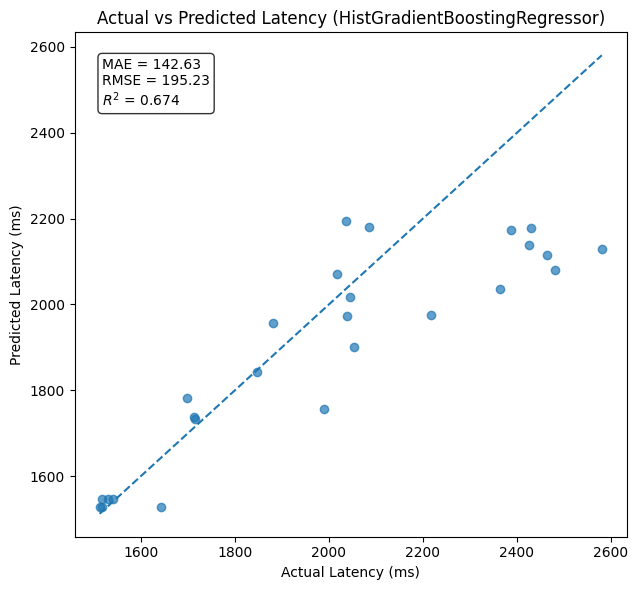

Saved figure to: /content/drive/MyDrive/Test_results/figures/fig_latency_scatter.png
Model used: HistGradientBoostingRegressor
Test MAE: 142.62904454153292
Test RMSE: 195.22640854932212
Test R2: 0.6740890008535616


In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_latency_model = best_surrogate_models["latency_ms"]["model"]
best_latency_model_name = best_surrogate_models["latency_ms"]["model_name"]

X_test_latency = make_surrogate_X(test_sur_df)
y_test_latency = pd.to_numeric(test_sur_df["latency_ms"], errors="coerce").astype(float).values
y_pred_latency = best_latency_model.predict(X_test_latency)

mae_latency = mean_absolute_error(y_test_latency, y_pred_latency)
rmse_latency = np.sqrt(mean_squared_error(y_test_latency, y_pred_latency))
r2_latency = r2_score(y_test_latency, y_pred_latency)

LATENCY_SCATTER_FIG_PATH = DIRS["figures"] / "fig_latency_scatter.png"

plt.figure(figsize=(6.5, 6.0))
plt.scatter(y_test_latency, y_pred_latency, alpha=0.7)

min_val = min(np.min(y_test_latency), np.min(y_pred_latency))
max_val = max(np.max(y_test_latency), np.max(y_pred_latency))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.5)

plt.xlabel("Actual Latency (ms)")
plt.ylabel("Predicted Latency (ms)")
plt.title(f"Actual vs Predicted Latency ({best_latency_model_name})")

metrics_text = f"MAE = {mae_latency:.2f}\nRMSE = {rmse_latency:.2f}\n$R^2$ = {r2_latency:.3f}"
plt.text(
    0.05, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(LATENCY_SCATTER_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", LATENCY_SCATTER_FIG_PATH)
print("Model used:", best_latency_model_name)
print("Test MAE:", mae_latency)
print("Test RMSE:", rmse_latency)
print("Test R2:", r2_latency)

In [50]:
for model_name, model in surrogate_model_candidates.items():
    model.fit(X_train_sur, targets_to_train["latency_ms"])
    row_val, _ = eval_regression(model_name, "latency_ms", model, val_sur_df)
    row_test, _ = eval_regression(model_name, "latency_ms", model, test_sur_df)
    print(model_name)
    print("VAL :", row_val)
    print("TEST:", row_test)
    print()

RandomForestRegressor
VAL : {'model_name': 'RandomForestRegressor', 'target_name': 'latency_ms', 'split': 'val', 'mae': 100.9070086398506, 'rmse': 144.23914966682625, 'r2': 0.702878909809978, 'n_rows': 26}
TEST: {'model_name': 'RandomForestRegressor', 'target_name': 'latency_ms', 'split': 'test', 'mae': 191.27065468636462, 'rmse': 263.6947790012494, 'r2': 0.4053999381446235, 'n_rows': 26}

HistGradientBoostingRegressor
VAL : {'model_name': 'HistGradientBoostingRegressor', 'target_name': 'latency_ms', 'split': 'val', 'mae': 72.5336459117433, 'rmse': 109.55646880396989, 'r2': 0.8285872096988921, 'n_rows': 26}
TEST: {'model_name': 'HistGradientBoostingRegressor', 'target_name': 'latency_ms', 'split': 'test', 'mae': 142.62904454153292, 'rmse': 195.22640854932212, 'r2': 0.6740890008535616, 'n_rows': 26}



In [48]:
print(best_surrogate_models["latency_ms"]["model_name"])

print(train_sur_df["latency_ms"].describe())
print(val_sur_df["latency_ms"].describe())
print(test_sur_df["latency_ms"].describe())

HistGradientBoostingRegressor
count     124.000000
mean     1730.948013
std       293.421851
min         0.000000
25%      1577.816316
50%      1706.740489
75%      1910.098029
max      2431.854159
Name: latency_ms, dtype: float64
count      26.000000
mean     1814.362952
std       269.856624
min      1496.001870
25%      1564.601977
50%      1815.898318
75%      1944.344928
max      2412.427919
Name: latency_ms, dtype: float64
count      26.000000
mean     1989.722804
std       348.743182
min      1512.622888
25%      1702.269294
50%      2026.374056
75%      2327.538000
max      2580.358389
Name: latency_ms, dtype: float64


In [49]:
pred = best_surrogate_models["latency_ms"]["model"].predict(make_surrogate_X(test_sur_df))
print("Pred min:", pred.min())
print("Pred max:", pred.max())
print("Pred mean:", pred.mean())

Pred min: 0.6619992061332927
Pred max: 0.7000734665322934
Pred mean: 0.6906184148932814


In [76]:
# =========================
# SECTION 8 / CELL 46
# Two-stage policy recommender
# Stage A: filter by predicted abort risk
# Stage B: choose best feasible pipeline by predicted utility
# Tune abort-risk threshold on validation
# =========================

RECOMMENDER_EVAL_CSV_PATH = DIRS["tables"] / "two_stage_recommender_evaluation_v10.csv"
RECOMMENDER_PROFILE_EVAL_CSV_PATH = DIRS["tables"] / "two_stage_recommender_profile_evaluation_v10.csv"
RECOMMENDER_DEMO_CSV_PATH = DIRS["tables"] / "two_stage_recommender_demo_v10.csv"
RECOMMENDER_THRESHOLD_SEARCH_CSV_PATH = DIRS["tables"] / "two_stage_recommender_threshold_search_v10.csv"
RECOMMENDER_ARTIFACT_JSON_PATH = TWO_STAGE_ARTIFACT_DIR / "two_stage_recommender_artifacts_v10.json"

recommendation_df = pd.read_csv(RECOMMENDATION_DATASET_CSV_PATH)

# -----------------------------------
# Shared prediction helpers
# -----------------------------------
def make_abort_X_for_candidate(df: pd.DataFrame):
    X_num = df[ABORT_FEATURE_COLUMNS_NUMERIC].copy().fillna(train_abort_medians)
    X_cat = pd.get_dummies(df["pipeline_id"].astype(str), prefix="pipeline")
    X_cat = X_cat.reindex(columns=ABORT_PIPELINE_DUMMY_COLUMNS, fill_value=0)
    return pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

def make_surrogate_X_for_candidate(df: pd.DataFrame):
    X_num = df[SURROGATE_FEATURE_COLUMNS_NUMERIC].copy().fillna(train_sur_medians)
    X_cat = pd.get_dummies(df["pipeline_id"].astype(str), prefix="pipeline")
    X_cat = X_cat.reindex(columns=SURROGATE_PIPELINE_DUMMY_COLUMNS, fill_value=0)
    return pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

def minmax_norm(series: pd.Series, invert=False):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    lo = s.min()
    hi = s.max()
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        out = pd.Series([1.0] * len(series), index=series.index)
    else:
        out = (s - lo) / (hi - lo)
    if invert:
        out = 1.0 - out
    return out.clip(0.0, 1.0)

def compute_true_utility(sub_df: pd.DataFrame):
    # normalize within candidate set for one condition_group x profile
    out = sub_df.copy()
    out["latency_score_true"] = minmax_norm(out["latency_ms"], invert=True)
    out["throughput_score_true"] = minmax_norm(out["throughput_bps"], invert=False)
    out["security_score_true"] = pd.to_numeric(out["security_score"], errors="coerce").clip(0.0, 1.0)
    out["success_score_true"] = pd.to_numeric(out["success_rate"], errors="coerce").clip(0.0, 1.0)

    utils = []
    for _, row in out.iterrows():
        cfg = PROFILE_CONFIG[str(row["decision_profile"])]
        w = cfg["weights"]
        util = (
            w["latency"] * row["latency_score_true"] +
            w["throughput"] * row["throughput_score_true"] +
            w["security"] * row["security_score_true"] +
            w["success"] * row["success_score_true"]
        )
        utils.append(util)
    out["true_utility"] = utils
    return out

def compute_predicted_utility(sub_df: pd.DataFrame):
    out = sub_df.copy()
    out["latency_score_pred"] = minmax_norm(out["pred_latency_ms"], invert=True)
    out["throughput_score_pred"] = minmax_norm(out["pred_throughput_bps"], invert=False)
    out["security_score_pred_norm"] = pd.to_numeric(out["pred_security_score"], errors="coerce").clip(0.0, 1.0)
    out["success_score_pred"] = pd.to_numeric(out["pred_success_prob"], errors="coerce").clip(0.0, 1.0)

    utils = []
    for _, row in out.iterrows():
        cfg = PROFILE_CONFIG[str(row["decision_profile"])]
        w = cfg["weights"]
        util = (
            w["latency"] * row["latency_score_pred"] +
            w["throughput"] * row["throughput_score_pred"] +
            w["security"] * row["security_score_pred_norm"] +
            w["success"] * row["success_score_pred"]
        )
        utils.append(util)
    out["pred_utility"] = utils
    return out

# -----------------------------------
# Predict stage outputs for all candidate rows
# -----------------------------------
abort_model = best_abort_model
latency_model = best_surrogate_models["latency_ms"]["model"]
security_model = best_surrogate_models["security_score"]["model"]

X_abort_all = make_abort_X_for_candidate(recommendation_df)
recommendation_df["pred_abort_prob"] = abort_model.predict_proba(X_abort_all)[:, 1]
recommendation_df["pred_success_prob"] = 1.0 - recommendation_df["pred_abort_prob"]

X_sur_all = make_surrogate_X_for_candidate(recommendation_df)
recommendation_df["pred_latency_ms"] = latency_model.predict(X_sur_all)
recommendation_df["pred_security_score"] = np.clip(security_model.predict(X_sur_all), 0.0, 1.0)
recommendation_df["pred_throughput_bps"] = (recommendation_df["msg_len_bytes"] * 8.0) / np.maximum(recommendation_df["pred_latency_ms"] / 1000.0, 1e-6)

# true utility
recommendation_df = (
    recommendation_df.groupby(["condition_group_id", "decision_profile"], dropna=False, group_keys=False)
    .apply(compute_true_utility)
    .reset_index(drop=True)
)

# -----------------------------------
# Tune abort threshold on validation
# -----------------------------------
candidate_thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

def run_policy_eval(df: pd.DataFrame, abort_threshold: float):
    result_rows = []

    for (condition_group_id, decision_profile), sub in df.groupby(["condition_group_id", "decision_profile"], dropna=False):
        sub = sub.copy()

        cfg = PROFILE_CONFIG[str(decision_profile)]
        min_success_rate = cfg["min_success_rate"]

        # predicted feasible set
        sub["pred_feasible"] = sub["pred_abort_prob"] <= abort_threshold

        pred_sub = compute_predicted_utility(sub.copy())

        if pred_sub["pred_feasible"].any():
            pred_choice_space = pred_sub[pred_sub["pred_feasible"]].copy()
            pred_choice_space = pred_choice_space.sort_values(
                ["pred_utility", "pred_success_prob", "pred_security_score", "pred_latency_ms"],
                ascending=[False, False, False, True]
            ).reset_index(drop=True)
        else:
            # fallback: choose lowest predicted abort risk
            pred_choice_space = pred_sub.sort_values(
                ["pred_abort_prob", "pred_latency_ms"],
                ascending=[True, True]
            ).reset_index(drop=True)

        pred_best = pred_choice_space.iloc[0]
        pred_top2 = pred_choice_space.head(2)["pipeline_id"].astype(str).tolist()

        # true oracle over measured values
        true_sub = sub.copy()
        true_sub["true_feasible"] = true_sub["success_rate"] >= min_success_rate

        if true_sub["true_feasible"].any():
            true_choice_space = true_sub[true_sub["true_feasible"]].copy().sort_values(
                ["true_utility", "success_rate", "security_score", "latency_ms"],
                ascending=[False, False, False, True]
            ).reset_index(drop=True)
        else:
            true_choice_space = true_sub.sort_values(
                ["success_rate", "true_utility"],
                ascending=[False, False]
            ).reset_index(drop=True)

        true_best = true_choice_space.iloc[0]
        selected_true_row = true_sub[true_sub["pipeline_id"] == pred_best["pipeline_id"]].iloc[0]

        result_rows.append({
            "split": str(sub["split"].iloc[0]),
            "condition_group_id": str(condition_group_id),
            "decision_profile": str(decision_profile),
            "abort_threshold": float(abort_threshold),
            "recommended_pipeline": str(pred_best["pipeline_id"]),
            "oracle_best_pipeline": str(true_best["pipeline_id"]),
            "top2_correct": str(true_best["pipeline_id"]) in pred_top2,
            "recommendation_correct": str(pred_best["pipeline_id"]) == str(true_best["pipeline_id"]),
            "selected_pred_abort_prob": float(pred_best["pred_abort_prob"]),
            "selected_pred_latency_ms": float(pred_best["pred_latency_ms"]),
            "selected_pred_security_score": float(pred_best["pred_security_score"]),
            "selected_true_latency_ms": float(selected_true_row["latency_ms"]),
            "selected_true_security_score": float(selected_true_row["security_score"]),
            "selected_true_success_rate": float(selected_true_row["success_rate"]),
            "oracle_true_latency_ms": float(true_best["latency_ms"]),
            "oracle_true_security_score": float(true_best["security_score"]),
            "oracle_true_success_rate": float(true_best["success_rate"]),
            "utility_regret": float(true_best["true_utility"] - selected_true_row["true_utility"]),
            "latency_regret_ms": float(selected_true_row["latency_ms"] - true_best["latency_ms"]),
            "security_regret": float(true_best["security_score"] - selected_true_row["security_score"]),
            "all_candidates_blocked": bool(not sub["pred_feasible"].any())
        })

    return pd.DataFrame(result_rows)

threshold_search_rows = []
for thr in candidate_thresholds:
    val_policy_df = run_policy_eval(recommendation_df[recommendation_df["split"] == "val"].copy(), abort_threshold=thr)
    threshold_search_rows.append({
        "abort_threshold": float(thr),
        "accuracy": float(val_policy_df["recommendation_correct"].mean()),
        "top2_accuracy": float(val_policy_df["top2_correct"].mean()),
        "mean_utility_regret": float(val_policy_df["utility_regret"].mean()),
        "mean_latency_regret_ms": float(val_policy_df["latency_regret_ms"].mean()),
        "mean_security_regret": float(val_policy_df["security_regret"].mean()),
        "selected_success_rate_mean": float(val_policy_df["selected_true_success_rate"].mean()),
        "all_blocked_rate": float(val_policy_df["all_candidates_blocked"].mean()),
        "n_rows": int(len(val_policy_df))
    })

threshold_search_df = pd.DataFrame(threshold_search_rows).sort_values(
    ["mean_utility_regret", "accuracy", "top2_accuracy"],
    ascending=[True, False, False]
).reset_index(drop=True)

BEST_ABORT_THRESHOLD = float(threshold_search_df.iloc[0]["abort_threshold"])

# final evaluation with best threshold
val_reco_df = run_policy_eval(recommendation_df[recommendation_df["split"] == "val"].copy(), abort_threshold=BEST_ABORT_THRESHOLD)
test_reco_df = run_policy_eval(recommendation_df[recommendation_df["split"] == "test"].copy(), abort_threshold=BEST_ABORT_THRESHOLD)

recommender_eval_rows = []
recommender_profile_rows = []

for split_name, df in [("val", val_reco_df), ("test", test_reco_df)]:
    recommender_eval_rows.append({
        "model_name": "TwoStageAbortRiskPlusSurrogate",
        "split": split_name,
        "abort_threshold": BEST_ABORT_THRESHOLD,
        "accuracy": float(df["recommendation_correct"].mean()),
        "top2_accuracy": float(df["top2_correct"].mean()),
        "mean_utility_regret": float(df["utility_regret"].mean()),
        "mean_latency_regret_ms": float(df["latency_regret_ms"].mean()),
        "mean_security_regret": float(df["security_regret"].mean()),
        "recommended_success_rate": float(df["selected_true_success_rate"].mean()),
        "all_blocked_rate": float(df["all_candidates_blocked"].mean()),
        "n_rows": int(len(df))
    })

    for profile_name, sub in df.groupby("decision_profile", dropna=False):
        recommender_profile_rows.append({
            "decision_profile": str(profile_name),
            "model_name": "TwoStageAbortRiskPlusSurrogate",
            "split": split_name,
            "abort_threshold": BEST_ABORT_THRESHOLD,
            "accuracy": float(sub["recommendation_correct"].mean()),
            "top2_accuracy": float(sub["top2_correct"].mean()),
            "mean_utility_regret": float(sub["utility_regret"].mean()),
            "mean_latency_regret_ms": float(sub["latency_regret_ms"].mean()),
            "mean_security_regret": float(sub["security_regret"].mean()),
            "recommended_success_rate": float(sub["selected_true_success_rate"].mean()),
            "all_blocked_rate": float(sub["all_candidates_blocked"].mean()),
            "n_rows": int(len(sub))
        })

recommender_eval_df = pd.DataFrame(recommender_eval_rows).sort_values("split").reset_index(drop=True)
recommender_profile_eval_df = pd.DataFrame(recommender_profile_rows).sort_values(
    ["decision_profile", "split"]
).reset_index(drop=True)

threshold_search_df.to_csv(RECOMMENDER_THRESHOLD_SEARCH_CSV_PATH, index=False)
recommender_eval_df.to_csv(RECOMMENDER_EVAL_CSV_PATH, index=False)
recommender_profile_eval_df.to_csv(RECOMMENDER_PROFILE_EVAL_CSV_PATH, index=False)
pd.concat([val_reco_df, test_reco_df], axis=0).to_csv(RECOMMENDER_DEMO_CSV_PATH, index=False)

recommender_artifact_payload = {
    "best_abort_threshold": BEST_ABORT_THRESHOLD,
    "threshold_search_csv": str(RECOMMENDER_THRESHOLD_SEARCH_CSV_PATH),
    "evaluation_csv": str(RECOMMENDER_EVAL_CSV_PATH),
    "profile_eval_csv": str(RECOMMENDER_PROFILE_EVAL_CSV_PATH),
    "demo_csv": str(RECOMMENDER_DEMO_CSV_PATH)
}

with open(RECOMMENDER_ARTIFACT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(recommender_artifact_payload, f, indent=2)

print_box("Recommender Threshold Search CSV", str(RECOMMENDER_THRESHOLD_SEARCH_CSV_PATH))
display(threshold_search_df)

print_box("Best Abort Threshold", BEST_ABORT_THRESHOLD)
print_box("Two-Stage Recommender Eval CSV", str(RECOMMENDER_EVAL_CSV_PATH))
display(recommender_eval_df)

print_box("Two-Stage Recommender Profile Eval CSV", str(RECOMMENDER_PROFILE_EVAL_CSV_PATH))
display(recommender_profile_eval_df)

Recommender Threshold Search CSV
/content/drive/MyDrive/Test_results/tables/two_stage_recommender_threshold_search_v10.csv


,abort_threshold,accuracy,top2_accuracy,mean_utility_regret,mean_latency_regret_ms,mean_security_regret,selected_success_rate_mean,all_blocked_rate,n_rows
0,0.3,0.125,0.500000,0.189363,32.164439,0.019226,0.958333,0.0,24
1,0.6,0.125,0.583333,0.225573,39.600996,0.023545,0.958333,0.0,24
2,0.7,0.125,0.583333,0.225573,39.600996,0.023545,0.958333,0.0,24
3,0.4,0.125,0.500000,0.225573,39.600996,0.023545,0.958333,0.0,24
4,0.5,0.125,0.500000,0.225573,39.600996,0.023545,0.958333,0.0,24


Best Abort Threshold
0.3
Two-Stage Recommender Eval CSV
/content/drive/MyDrive/Test_results/tables/two_stage_recommender_evaluation_v10.csv


,model_name,split,abort_threshold,accuracy,top2_accuracy,mean_utility_regret,mean_latency_regret_ms,mean_security_regret,recommended_success_rate,all_blocked_rate,n_rows
0,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.541667,0.193459,91.253728,0.021825,1.000000,0.0,24
1,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.500000,0.189363,32.164439,0.019226,0.958333,0.0,24


Two-Stage Recommender Profile Eval CSV
/content/drive/MyDrive/Test_results/tables/two_stage_recommender_profile_evaluation_v10.csv


,decision_profile,model_name,split,abort_threshold,accuracy,top2_accuracy,mean_utility_regret,mean_latency_regret_ms,mean_security_regret,recommended_success_rate,all_blocked_rate,n_rows
0,BALANCED,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.500,0.191019,94.318005,0.021872,1.000000,0.0,8
1,BALANCED,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.375,0.193360,42.686710,0.017694,0.958333,0.0,8
2,FAST,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.500,0.315189,94.318005,0.021872,1.000000,0.0,8
3,FAST,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.375,0.321149,42.686710,0.017694,0.958333,0.0,8
4,SECURE,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.625,0.074170,85.125174,0.021731,1.000000,0.0,8
5,SECURE,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.750,0.053579,11.119896,0.022290,0.958333,0.0,8


In [77]:
# =========================
# SECTION 8 / CELL 47
# Final two-stage AI reporting:
#   - abort model on synthetic stress
#   - combined recommender demo
#   - concise comparison-ready outputs
# =========================

TWO_STAGE_FINAL_SUMMARY_JSON_PATH = TWO_STAGE_ARTIFACT_DIR / "two_stage_final_summary_v10.json"

# reload key outputs for clean reporting
abort_eval_df = pd.read_csv(ABORT_MODEL_EVAL_CSV_PATH)
abort_stress_eval_df = pd.read_csv(ABORT_MODEL_STRESS_EVAL_CSV_PATH)
surrogate_eval_df = pd.read_csv(SURROGATE_MODEL_EVAL_CSV_PATH)
recommender_eval_df = pd.read_csv(RECOMMENDER_EVAL_CSV_PATH)
recommender_profile_eval_df = pd.read_csv(RECOMMENDER_PROFILE_EVAL_CSV_PATH)
recommender_demo_df = pd.read_csv(RECOMMENDER_DEMO_CSV_PATH)

best_abort_val_row = abort_eval_df[abort_eval_df["split"] == "val"].sort_values(
    ["pr_auc", "recall", "f1"], ascending=[False, False, False]
).iloc[0]

best_abort_stress_row = abort_stress_eval_df[abort_stress_eval_df["model_name"] == best_abort_model_name].iloc[0]

best_latency_val_row = surrogate_eval_df[
    (surrogate_eval_df["target_name"] == "latency_ms") &
    (surrogate_eval_df["split"] == "val")
].sort_values(["mae", "rmse"], ascending=[True, True]).iloc[0]

best_security_val_row = surrogate_eval_df[
    (surrogate_eval_df["target_name"] == "security_score") &
    (surrogate_eval_df["split"] == "val")
].sort_values(["mae", "rmse"], ascending=[True, True]).iloc[0]

test_reco_row = recommender_eval_df[recommender_eval_df["split"] == "test"].iloc[0]

final_summary = {
    "created_utc": utc_now_iso(),
    "abort_model": {
        "best_model_name": best_abort_model_name,
        "validation_pr_auc": float(best_abort_val_row["pr_auc"]) if not pd.isna(best_abort_val_row["pr_auc"]) else None,
        "validation_recall": float(best_abort_val_row["recall"]),
        "test_pr_auc": float(
            abort_eval_df[
                (abort_eval_df["model_name"] == best_abort_model_name) &
                (abort_eval_df["split"] == "test")
            ]["pr_auc"].iloc[0]
        ) if len(abort_eval_df[
                (abort_eval_df["model_name"] == best_abort_model_name) &
                (abort_eval_df["split"] == "test")
            ]) else None,
        "stress_test_recall": float(best_abort_stress_row["recall"]),
        "stress_test_pr_auc": float(best_abort_stress_row["pr_auc"]) if not pd.isna(best_abort_stress_row["pr_auc"]) else None
    },
    "surrogates": {
        "latency_best_model": best_surrogate_models["latency_ms"]["model_name"],
        "latency_val_mae": float(best_latency_val_row["mae"]),
        "latency_val_rmse": float(best_latency_val_row["rmse"]),
        "latency_val_r2": float(best_latency_val_row["r2"]),
        "security_best_model": best_surrogate_models["security_score"]["model_name"],
        "security_val_mae": float(best_security_val_row["mae"]),
        "security_val_rmse": float(best_security_val_row["rmse"]),
        "security_val_r2": float(best_security_val_row["r2"])
    },
    "two_stage_recommender": {
        "best_abort_threshold": float(BEST_ABORT_THRESHOLD),
        "test_accuracy": float(test_reco_row["accuracy"]),
        "test_top2_accuracy": float(test_reco_row["top2_accuracy"]),
        "test_mean_utility_regret": float(test_reco_row["mean_utility_regret"]),
        "test_recommended_success_rate": float(test_reco_row["recommended_success_rate"]),
        "test_all_blocked_rate": float(test_reco_row["all_blocked_rate"])
    }
}

with open(TWO_STAGE_FINAL_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

print_box("Abort Model Evaluation", str(ABORT_MODEL_EVAL_CSV_PATH))
display(abort_eval_df)

print_box("Abort Model Synthetic Stress Evaluation", str(ABORT_MODEL_STRESS_EVAL_CSV_PATH))
display(abort_stress_eval_df)

print_box("Surrogate Model Evaluation", str(SURROGATE_MODEL_EVAL_CSV_PATH))
display(surrogate_eval_df)

print_box("Two-Stage Recommender Evaluation", str(RECOMMENDER_EVAL_CSV_PATH))
display(recommender_eval_df)

print_box("Two-Stage Recommender Profile Evaluation", str(RECOMMENDER_PROFILE_EVAL_CSV_PATH))
display(recommender_profile_eval_df)

print_box("Two-Stage Recommender Demo Preview", str(RECOMMENDER_DEMO_CSV_PATH))
display(recommender_demo_df.head(20))

print_box("Two-Stage Final Summary JSON", str(TWO_STAGE_FINAL_SUMMARY_JSON_PATH))
print_box("Two-Stage Final Summary", final_summary)

Abort Model Evaluation
/content/drive/MyDrive/Test_results/tables/abort_model_evaluation_v10.csv


,model_name,split,label_source,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,positive_rate,n_rows
0,LogisticRegression,stress_test,simulated_abort_label,0.711538,1.000000,0.711538,0.831461,NaN,NaN,NaN,1.000000,156
1,RandomForestClassifier,stress_test,simulated_abort_label,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,1.000000,156
2,RandomForestClassifier,test,abort_label,0.974359,0.000000,0.000000,0.000000,0.717105,0.061111,0.036780,0.025641,78
3,LogisticRegression,test,abort_label,0.820513,0.000000,0.000000,0.000000,0.657895,0.051587,0.102532,0.025641,78
4,RandomForestClassifier,val,abort_label,0.935897,0.333333,0.250000,0.285714,0.804054,0.186111,0.055361,0.051282,78
5,LogisticRegression,val,abort_label,0.628205,0.037037,0.250000,0.064516,0.481419,0.059161,0.240981,0.051282,78


Abort Model Synthetic Stress Evaluation
/content/drive/MyDrive/Test_results/tables/abort_model_stress_evaluation_v10.csv


,model_name,split,label_source,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,positive_rate,n_rows
0,LogisticRegression,stress_test,simulated_abort_label,0.711538,1.0,0.711538,0.831461,NaN,NaN,NaN,1.0,156
1,RandomForestClassifier,stress_test,simulated_abort_label,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,1.0,156


Surrogate Model Evaluation
/content/drive/MyDrive/Test_results/tables/surrogate_model_evaluation_v10.csv


...

Two-Stage Recommender Profile Evaluation
/content/drive/MyDrive/Test_results/tables/two_stage_recommender_profile_evaluation_v10.csv


,decision_profile,model_name,split,abort_threshold,accuracy,top2_accuracy,mean_utility_regret,mean_latency_regret_ms,mean_security_regret,recommended_success_rate,all_blocked_rate,n_rows
0,BALANCED,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.500,0.191019,94.318005,0.021872,1.000000,0.0,8
1,BALANCED,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.375,0.193360,42.686710,0.017694,0.958333,0.0,8
2,FAST,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.500,0.315189,94.318005,0.021872,1.000000,0.0,8
3,FAST,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.375,0.321149,42.686710,0.017694,0.958333,0.0,8
4,SECURE,TwoStageAbortRiskPlusSurrogate,test,0.3,0.250,0.625,0.074170,85.125174,0.021731,1.000000,0.0,8
5,SECURE,TwoStageAbortRiskPlusSurrogate,val,0.3,0.125,0.750,0.053579,11.119896,0.022290,0.958333,0.0,8


Two-Stage Recommender Demo Preview
/content/drive/MyDrive/Test_results/tables/two_stage_recommender_demo_v10.csv


,split,condition_group_id,decision_profile,abort_threshold,recommended_pipeline,oracle_best_pipeline,top2_correct,recommendation_correct,selected_pred_abort_prob,selected_pred_latency_ms,...,selected_true_latency_ms,selected_true_security_score,selected_true_success_rate,oracle_true_latency_ms,oracle_true_security_score,oracle_true_success_rate,utility_regret,latency_regret_ms,security_regret,all_candidates_blocked
0,val,1f09dabebfd3832e,BALANCED,0.3,P2_PQC_MLDSA_LINDBLAD,P2_PQC_MLDSA_LINDBLAD,True,True,0.024257,0.662733,...,1890.107656,0.661120,0.666667,1890.107656,0.661120,0.666667,0.000000,0.000000,0.000000,False
1,val,1f09dabebfd3832e,FAST,0.3,P2_PQC_MLDSA_LINDBLAD,P2_PQC_MLDSA_LINDBLAD,True,True,0.024257,0.662733,...,1890.107656,0.661120,0.666667,1890.107656,0.661120,0.666667,0.000000,0.000000,0.000000,False
2,val,1f09dabebfd3832e,SECURE,0.3,P2_PQC_MLDSA_LINDBLAD,P1_PQC_MLDSA,True,False,0.024257,0.662733,...,1890.107656,0.661120,0.666667,1975.723856,0.699012,1.000000,-0.026959,-85.616200,0.037892,False
3,val,2432916861329049,BALANCED,0.3,P2_PQC_MLDSA_LINDBLAD,P4_HYBRID_QKD_LINDBLAD,True,False,0.000000,0.662707,...,1575.837814,0.661120,1.000000,1500.603247,0.694546,1.000000,0.461699,75.234567,0.033426,False
4,val,2432916861329049,FAST,0.3,P2_PQC_MLDSA_LINDBLAD,P4_HYBRID_QKD_LINDBLAD,True,False,0.000000,0.662707,...,1575.837814,0.661120,1.000000,1500.603247,0.694546,1.000000,0.753343,75.234567,0.033426,False
5,val,2432916861329049,SECURE,0.3,P2_PQC_MLDSA_LINDBLAD,P4_HYBRID_QKD_LINDBLAD,True,False,0.000000,0.662707,...,1575.837814,0.661120,1.000000,1500.603247,0.694546,1.000000,0.170056,75.234567,0.033426,False
6,val,4e30fff09dc57e1a,BALANCED,0.3,P4_HYBRID_QKD_LINDBLAD,P3_HYBRID_QKD,False,False,0.182917,0.694586,...,1677.748169,0.694546,1.000000,1510.829858,0.695674,0.666667,0.383728,166.918311,0.001128,False
7,val,4e30fff09dc57e1a,FAST,0.3,P4_HYBRID_QKD_LINDBLAD,P3_HYBRID_QKD,False,False,0.182917,0.694586,...,1677.748169,0.694546,1.000000,1510.829858,0.695674,0.666667,0.700113,166.918311,0.001128,False
8,val,4e30fff09dc57e1a,SECURE,0.3,P4_HYBRID_QKD_LINDBLAD,P4_HYBRID_QKD_LINDBLAD,True,True,0.182917,0.694586,...,1677.748169,0.694546,1.000000,1677.748169,0.694546,1.000000,0.000000,0.000000,0.000000,False
9,val,4fe994142f3a2656,BALANCED,0.3,P2_PQC_MLDSA_LINDBLAD,P1_PQC_MLDSA,False,False,0.008860,0.662194,...,1583.306335,0.661120,1.000000,1529.492983,0.699012,1.000000,0.172524,53.813352,0.037892,False


Two-Stage Final Summary JSON
/content/drive/MyDrive/Test_results/artifacts/two_stage_ai_v10/two_stage_final_summary_v10.json
Two-Stage Final Summary
{'abort_model': {'best_model_name': 'RandomForestClassifier',
                 'stress_test_pr_auc': None,
                 'stress_test_recall': 0.0,
                 'test_pr_auc': 0.0611111111111111,
                 'validation_pr_auc': 0.1861111111111111,
                 'validation_recall': 0.25},
 'created_utc': '2026-03-13T09:43:21.490436+00:00',
 'surrogates': {'latency_best_model': 'RandomForestRegressor',
                'latency_val_mae': 86.80895016003612,
                'latency_val_r2': 0.7455885539944667,
                'latency_val_rmse': 109.78370032162915,
                'security_best_model': 'HistGradientBoostingRegressor',
                'security_val_mae': 1.5444256984409318e-11,
                'security_val_r2': 1.0,
                'security_val_rmse': 1.8190913421041718e-11},
 'two_stage_recommender': {'best

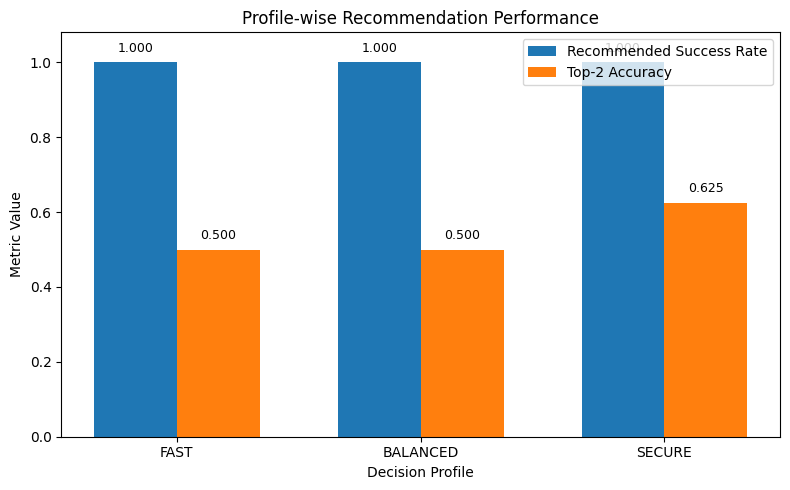

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("two_stage_recommender_profile_evaluation_v10.csv")
plot_df = df[df["split"] == "test"].copy()

profile_order = ["FAST", "BALANCED", "SECURE"]
plot_df["decision_profile"] = pd.Categorical(
    plot_df["decision_profile"],
    categories=profile_order,
    ordered=True
)
plot_df = plot_df.sort_values("decision_profile")

profiles = plot_df["decision_profile"].tolist()
top2 = plot_df["top2_accuracy"].tolist()
rsr = plot_df["recommended_success_rate"].tolist()

x = np.arange(len(profiles))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rsr, width, label="Recommended Success Rate")
bars2 = ax.bar(x + width/2, top2, width, label="Top-2 Accuracy")

ax.set_xticks(x)
ax.set_xticklabels(profiles)
ax.set_ylim(0, 1.08)
ax.set_xlabel("Decision Profile")
ax.set_ylabel("Metric Value")
ax.set_title("Profile-wise Recommendation Performance")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("fig_profile_recommender.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("two_stage_recommender_threshold_search_v10.csv")
print(df.columns.tolist())
print(df.head())

['abort_threshold', 'accuracy', 'top2_accuracy', 'mean_utility_regret', 'mean_latency_regret_ms', 'mean_security_regret', 'selected_success_rate_mean', 'all_blocked_rate', 'n_rows']
   abort_threshold  accuracy  top2_accuracy  mean_utility_regret  \
0              0.3     0.125       0.500000             0.189363   
1              0.6     0.125       0.583333             0.225573   
2              0.7     0.125       0.583333             0.225573   
3              0.4     0.125       0.500000             0.225573   
4              0.5     0.125       0.500000             0.225573   

   mean_latency_regret_ms  mean_security_regret  selected_success_rate_mean  \
0               32.164439              0.019226                    0.958333   
1               39.600996              0.023545                    0.958333   
2               39.600996              0.023545                    0.958333   
3               39.600996              0.023545                    0.958333   
4             